# Phase 3 - Data Contract and Initial EDA

This notebook is a Phase 3 report for the GCI World NFL Draft Prediction competition. It is intentionally notebook-first, audit-ready, and descriptive.

Phase 3 boundaries:

- Recompute and verify the data contract from official CSV files.
- Explore target distribution, missingness, train/test alignment, role-specific patterns, physical profiles, categorical risks, and overlooked patterns.
- Generate hypotheses for later phases only.
- Do not train models, generate submissions, perform final feature engineering, fit preprocessing, target encode, select final features, modify raw data, or use external data.

Strategic message: this EDA does not select a model or final features, but it shows where signal may exist and where validation/leakage risks must be controlled.


## 1. Title and Phase 3 Boundaries

**Objective.** Establish the scope and safety rules for the notebook.

**Why it matters.** EDA can easily drift into modeling decisions. This section keeps Phase 3 descriptive and audit-ready.

**Leakage/validation caution.** Any target-aware analysis is train-only. Test data is used only for structural and distribution diagnostics.


## 2. Setup, Imports, Constants, and Paths

The notebook uses repository-root paths, dependency-light Python tooling, and stable figure output locations.


### 2.1 Runtime setup

**Objective.** Import EDA libraries, define constants, and establish repository paths.

**Why it matters.** A reproducible notebook should run from a clean kernel and from the repository root.

**Expected output.** Tables, figures, and narrative interpretation directly below the code cell.

**Data used.** No competition data is loaded in this cell.

**Leakage/validation caution.** No modeling libraries are imported. Seaborn is used only if already installed.


In [1]:
from pathlib import Path
from datetime import date
from math import sqrt
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

HAS_SEABORN = importlib.util.find_spec("seaborn") is not None
if HAS_SEABORN:
    import seaborn as sns
else:
    sns = None

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 160)

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "input"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
DOCS_DIR = PROJECT_ROOT / "docs"
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
SAMPLE_SUBMISSION_PATH = DATA_DIR / "sample_submission.csv"
EXPERIMENT_NOTES_PATH = DOCS_DIR / "experiment_notes.md"

TARGET_COLUMN = "Drafted"
ID_COLUMN = "Id"
EXPECTED_SAMPLE_COLUMNS = [ID_COLUMN, TARGET_COLUMN]
CATEGORICAL_COLUMNS = ["School", "Player_Type", "Position_Type", "Position"]
MISSINGNESS_COLUMNS = [
    "Age",
    "Sprint_40yd",
    "Vertical_Jump",
    "Bench_Press_Reps",
    "Broad_Jump",
    "Agility_3cone",
    "Shuttle",
]
PHYSICAL_METRIC_COLUMNS = [
    "Height",
    "Weight",
    "Sprint_40yd",
    "Vertical_Jump",
    "Bench_Press_Reps",
    "Broad_Jump",
    "Agility_3cone",
    "Shuttle",
]

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR.mkdir(parents=True, exist_ok=True)
saved_figures = []
section_summaries = []


def title(text):
    display(Markdown(f"\n## {text}\n"))


**Interpretation.** The setup cell defines paths and constants only. It does not read data, train models, or generate submissions.


## 3. Helper Functions


### 3.1 Reusable EDA helpers

**Objective.** Define table display, figure saving, Wilson intervals, target-rate summaries, missingness summaries, drift diagnostics, and correlation helpers.

**Why it matters.** Reusable helpers reduce hidden state and keep repeated calculations consistent across sections.

**Expected output.** Tables, figures, and narrative interpretation directly below the code cell.

**Data used.** No train/test data is loaded or transformed in this cell.

**Leakage/validation caution.** Helpers are descriptive. They do not fit models, learn preprocessing, or create final features.


In [2]:
def save_fig(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    saved_figures.append(str(path.relative_to(PROJECT_ROOT)).replace("\\", "/"))
    return path


def display_table(name, df, max_rows=25):
    display(Markdown(f"**{name}**"))
    if df.empty:
        display(pd.DataFrame({"status": ["no rows"]}))
    elif len(df) > max_rows:
        display(df.head(max_rows))
        display(Markdown(f"Showing first {max_rows} of {len(df)} rows."))
    else:
        display(df)


def bullet(items):
    if isinstance(items, str):
        items = [items]
    return "\n".join(f"- {item}" for item in items)


def section_conclusion(title_text, key_takeaways, why_this_matters, leakage_caution, hypotheses, deferred_decisions):
    section_summaries.append({
        "section": title_text,
        "key_takeaways": " | ".join(key_takeaways if isinstance(key_takeaways, list) else [key_takeaways]),
        "why_this_matters": " | ".join(why_this_matters if isinstance(why_this_matters, list) else [why_this_matters]),
        "leakage_caution": " | ".join(leakage_caution if isinstance(leakage_caution, list) else [leakage_caution]),
        "hypotheses": " | ".join(hypotheses if isinstance(hypotheses, list) else [hypotheses]),
        "deferred_decisions": " | ".join(deferred_decisions if isinstance(deferred_decisions, list) else [deferred_decisions]),
    })
    display(Markdown(f"""
### Section conclusion - {title_text}

**Key takeaways**
{bullet(key_takeaways)}

**Why this matters**
{bullet(why_this_matters)}

**Leakage/validation caution**
{bullet(leakage_caution)}

**Hypotheses for future phases**
{bullet(hypotheses)}

**Deferred decisions**
{bullet(deferred_decisions)}
"""))


def wilson_interval(successes, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = successes / n
    denom = 1 + (z**2 / n)
    center = (p + z**2 / (2 * n)) / denom
    margin = (z * sqrt((p * (1 - p) / n) + (z**2 / (4 * n**2)))) / denom
    return max(0.0, center - margin), min(1.0, center + margin)


def target_rate_table(df, group_col, min_n_warning=20):
    grouped = df.groupby(group_col, dropna=False)[TARGET_COLUMN].agg(["count", "sum", "mean"]).reset_index()
    grouped = grouped.rename(columns={"count": "n", "sum": "positive_count", "mean": "target_rate"})
    intervals = grouped.apply(lambda row: wilson_interval(row["positive_count"], row["n"]), axis=1)
    grouped["wilson_low"] = [x[0] for x in intervals]
    grouped["wilson_high"] = [x[1] for x in intervals]
    grouped["uncertainty_width"] = grouped["wilson_high"] - grouped["wilson_low"]
    grouped["low_n_warning"] = grouped["n"] < min_n_warning
    grouped["interpretation"] = np.where(
        grouped["low_n_warning"],
        "unstable_low_n",
        np.where(grouped["uncertainty_width"] > 0.30, "wide_uncertainty", "more_stable"),
    )
    return grouped.sort_values(["target_rate", "n"], ascending=[False, False])


def missingness_summary(df, split_name):
    out = df.isna().sum().rename("missing_count").to_frame()
    out["missing_pct"] = out["missing_count"] / len(df)
    out["split"] = split_name
    out["column"] = out.index
    return out.reset_index(drop=True)[["split", "column", "missing_count", "missing_pct"]]


def normalized_frequency_delta(train_df, test_df, column):
    train_freq = train_df[column].astype(str).value_counts(normalize=True).rename("train_freq")
    test_freq = test_df[column].astype(str).value_counts(normalize=True).rename("test_freq")
    out = pd.concat([train_freq, test_freq], axis=1).fillna(0.0)
    out["delta_test_minus_train"] = out["test_freq"] - out["train_freq"]
    out["abs_delta"] = out["delta_test_minus_train"].abs()
    out.index.name = column
    return out.reset_index().sort_values("abs_delta", ascending=False)


def numeric_summary(df, columns):
    rows = []
    for col in columns:
        s = df[col]
        q = s.quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
        rows.append({
            "column": col,
            "count": s.count(),
            "missing": s.isna().sum(),
            "mean": s.mean(),
            "std": s.std(),
            "min": s.min(),
            "q01": q.loc[0.01],
            "q05": q.loc[0.05],
            "q25": q.loc[0.25],
            "median": q.loc[0.50],
            "q75": q.loc[0.75],
            "q95": q.loc[0.95],
            "q99": q.loc[0.99],
            "max": s.max(),
            "iqr": q.loc[0.75] - q.loc[0.25],
        })
    return pd.DataFrame(rows)


def duplicated_columns(df):
    return df.columns[df.columns.duplicated()].tolist()


def constant_columns(df):
    return [col for col in df.columns if df[col].nunique(dropna=False) <= 1]


def near_constant_columns(df, threshold=0.98):
    rows = []
    for col in df.columns:
        top_freq = df[col].value_counts(dropna=False, normalize=True).iloc[0]
        if top_freq >= threshold:
            rows.append({"column": col, "top_frequency": top_freq})
    return pd.DataFrame(rows)


def heatmap_plot(data, title_text, cmap="viridis", center=None, annotate=False, figsize=(10, 6)):
    fig, ax = plt.subplots(figsize=figsize)
    if HAS_SEABORN:
        sns.heatmap(data, ax=ax, cmap=cmap, center=center, annot=annotate, fmt=".2f", cbar=True)
    else:
        values = data.to_numpy(dtype=float)
        im = ax.imshow(values, aspect="auto", cmap=cmap)
        ax.set_xticks(range(data.shape[1]))
        ax.set_xticklabels(data.columns, rotation=45, ha="right")
        ax.set_yticks(range(data.shape[0]))
        ax.set_yticklabels(data.index)
        if annotate and data.shape[0] * data.shape[1] <= 120:
            for i in range(data.shape[0]):
                for j in range(data.shape[1]):
                    ax.text(j, i, f"{values[i, j]:.2f}", ha="center", va="center", fontsize=7)
        fig.colorbar(im, ax=ax)
    ax.set_title(title_text)
    fig.tight_layout()
    return fig, ax


def plot_target_rate_bars(table, label_col, title_text, max_categories=20, filename=None):
    plot_df = table.sort_values("n", ascending=False).head(max_categories).sort_values("target_rate")
    fig, ax = plt.subplots(figsize=(11, max(5, 0.35 * len(plot_df))))
    y = np.arange(len(plot_df))
    ax.barh(y, plot_df["target_rate"], color="#4c78a8", alpha=0.85)
    lower_err = np.maximum((plot_df["target_rate"] - plot_df["wilson_low"]).to_numpy(dtype=float), 0)
    upper_err = np.maximum((plot_df["wilson_high"] - plot_df["target_rate"]).to_numpy(dtype=float), 0)
    ax.errorbar(
        plot_df["target_rate"].to_numpy(dtype=float),
        y,
        xerr=[lower_err, upper_err],
        fmt="none",
        ecolor="#333333",
        capsize=3,
        linewidth=1,
    )
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df[label_col].astype(str))
    ax.set_xlim(0, 1)
    ax.set_xlabel("Drafted rate with Wilson interval")
    ax.set_title(title_text)
    for yi, (_, row) in zip(y, plot_df.iterrows()):
        marker = " unstable" if row["low_n_warning"] else ""
        ax.text(min(0.98, row["target_rate"] + 0.02), yi, f"n={int(row['n'])}{marker}", va="center", fontsize=8)
    fig.tight_layout()
    if filename:
        save_fig(fig, filename)
    return fig, ax


def empirical_cdf_distance(a, b):
    a = np.sort(pd.Series(a).dropna().to_numpy())
    b = np.sort(pd.Series(b).dropna().to_numpy())
    if len(a) == 0 or len(b) == 0:
        return np.nan
    grid = np.unique(np.concatenate([a, b]))
    cdf_a = np.searchsorted(a, grid, side="right") / len(a)
    cdf_b = np.searchsorted(b, grid, side="right") / len(b)
    return float(np.max(np.abs(cdf_a - cdf_b)))


def high_correlation_pairs(corr, threshold=0.60):
    rows = []
    cols = list(corr.columns)
    for i, left in enumerate(cols):
        for right in cols[i+1:]:
            value = corr.loc[left, right]
            if pd.notna(value) and abs(value) >= threshold:
                rows.append({
                    "feature_a": left,
                    "feature_b": right,
                    "correlation": value,
                    "abs_correlation": abs(value),
                    "interpretation": "possible redundancy or shared physical profile; not a Phase 3 feature-selection decision",
                })
    if not rows:
        return pd.DataFrame(columns=["feature_a", "feature_b", "correlation", "abs_correlation", "interpretation"])
    return pd.DataFrame(rows).sort_values("abs_correlation", ascending=False)


def md_table(df, max_rows=30):
    if df.empty:
        return "No rows."
    view = df.head(max_rows).copy()
    for col in view.columns:
        view[col] = view[col].map(lambda x: f"{x:.4f}" if isinstance(x, float) else str(x))
    header = "| " + " | ".join(view.columns) + " |"
    sep = "| " + " | ".join(["---"] * len(view.columns)) + " |"
    rows = ["| " + " | ".join(str(v).replace("|", "/") for v in row) + " |" for row in view.to_numpy()]
    suffix = f"\n\nShowing first {max_rows} of {len(df)} rows." if len(df) > max_rows else ""
    return "\n".join([header, sep] + rows) + suffix

# Alias used by the narrative experiment-notes update.
markdown_table = md_table


# Alias used by the refactored interpretation cells.
render_interpretation = section_conclusion


**Interpretation.** The helper functions standardize EDA outputs and Wilson uncertainty intervals without adding dependencies.


## 4. Data Loading


### 4.1 Load official CSV files

**Objective.** Load `train.csv`, `test.csv`, and `sample_submission.csv` from `data/input/`.

**Why it matters.** Every later analysis should be traceable to official competition files.

**Expected output.** Tables, figures, and narrative interpretation directly below the code cell.

**Data used.** Train, test, and sample submission.

**Leakage/validation caution.** Files are read only. No raw data is modified.


In [3]:
required_paths = [TRAIN_PATH, TEST_PATH, SAMPLE_SUBMISSION_PATH]
missing_paths = [str(path) for path in required_paths if not path.exists()]
assert not missing_paths, f"Missing official input files: {missing_paths}"
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)


**Interpretation.** The official CSV files are loaded from local repository paths. This cell does not infer labels or create derived datasets.


## 5. Data Contract Checks


### 5.1 Contract assertions and structural quality checks

**Objective.** Verify target placement, ID presence, sample submission format, column alignment, ID uniqueness, duplicated rows, constant columns, and near-constant columns.

**Why it matters.** A trusted data contract prevents silent downstream failures such as wrong ID order or wrong submission schema.

**Expected output.** Tables, figures, and narrative interpretation directly below the code cell.

**Data used.** Train/test/sample structural information.

**Leakage/validation caution.** Test is used only for structure and ID alignment. No target-aware test analysis is performed.


In [4]:
expected_test_columns = [col for col in train.columns if col != TARGET_COLUMN]
contract_df = pd.DataFrame([
    {"check": "train file exists", "status": TRAIN_PATH.exists(), "detail": str(TRAIN_PATH.relative_to(PROJECT_ROOT))},
    {"check": "test file exists", "status": TEST_PATH.exists(), "detail": str(TEST_PATH.relative_to(PROJECT_ROOT))},
    {"check": "sample submission file exists", "status": SAMPLE_SUBMISSION_PATH.exists(), "detail": str(SAMPLE_SUBMISSION_PATH.relative_to(PROJECT_ROOT))},
    {"check": "Drafted exists in train", "status": TARGET_COLUMN in train.columns, "detail": "target column"},
    {"check": "Drafted absent from test", "status": TARGET_COLUMN not in test.columns, "detail": "test has no target"},
    {"check": "Id exists in train/test/sample", "status": ID_COLUMN in train.columns and ID_COLUMN in test.columns and ID_COLUMN in sample_submission.columns, "detail": "ID column"},
    {"check": "sample submission columns", "status": list(sample_submission.columns) == EXPECTED_SAMPLE_COLUMNS, "detail": str(list(sample_submission.columns))},
    {"check": "test columns match train minus target", "status": list(test.columns) == expected_test_columns, "detail": "column order included"},
    {"check": "sample row count equals test", "status": len(sample_submission) == len(test), "detail": f"sample={len(sample_submission)}, test={len(test)}"},
    {"check": "unique IDs", "status": train[ID_COLUMN].is_unique and test[ID_COLUMN].is_unique and sample_submission[ID_COLUMN].is_unique, "detail": "train/test/sample"},
    {"check": "sample Id order matches test", "status": sample_submission[ID_COLUMN].equals(test[ID_COLUMN]), "detail": "strict order check"},
    {"check": "target binary and non-missing", "status": train[TARGET_COLUMN].notna().all() and set(train[TARGET_COLUMN].dropna().astype(int).unique()).issubset({0, 1}), "detail": str(sorted(train[TARGET_COLUMN].dropna().unique()))},
])
display_table("Data contract checks", contract_df, max_rows=50)
assert contract_df["status"].all(), contract_df.loc[~contract_df["status"]]
shape_df = pd.DataFrame([
    {"dataset": "train", "rows": train.shape[0], "columns": train.shape[1]},
    {"dataset": "test", "rows": test.shape[0], "columns": test.shape[1]},
    {"dataset": "sample_submission", "rows": sample_submission.shape[0], "columns": sample_submission.shape[1]},
])
display_table("Shape summary", shape_df)
quality_df = pd.DataFrame([
    {"dataset": "train", "duplicated_rows": int(train.duplicated().sum()), "duplicated_columns": duplicated_columns(train), "constant_columns": constant_columns(train)},
    {"dataset": "test", "duplicated_rows": int(test.duplicated().sum()), "duplicated_columns": duplicated_columns(test), "constant_columns": constant_columns(test)},
])
display_table("Duplicate and constant-column summary", quality_df)
display_table("Near-constant columns - train", near_constant_columns(train))
display_table("Near-constant columns - test", near_constant_columns(test))


**Data contract checks**

,check,status,detail
0,train file exists,True,data\input\train.csv
1,test file exists,True,data\input\test.csv
2,sample submission file exists,True,data\input\sample_submission.csv
3,Drafted exists in train,True,target column
4,Drafted absent from test,True,test has no target
5,Id exists in train/test/sample,True,ID column
6,sample submission columns,True,"['Id', 'Drafted']"
7,test columns match train minus target,True,column order included
8,sample row count equals test,True,"sample=696, test=696"
9,unique IDs,True,train/test/sample


**Shape summary**

,dataset,rows,columns
0,train,2781,16
1,test,696,15
2,sample_submission,696,2


**Duplicate and constant-column summary**

,dataset,duplicated_rows,duplicated_columns,constant_columns
0,train,0,[],[]
1,test,0,[],[]


**Near-constant columns - train**

,status
0,no rows


**Near-constant columns - test**

,status
0,no rows


**Interpretation.** The contract is technically healthy and allows Phase 3 to proceed. Train has 2,781 rows and 16 columns, test has 696 rows and 15 columns, and the sample submission has 696 rows and 2 columns. The target is `Drafted`, the ID is `Id`, and there are no duplicated rows in train/test. However, unique IDs do not prove statistical independence: rows may still be partially grouped by `School`, `Year`, `Position`, or `Position_Type`. This does not block Phase 3, but Phase 5/6 validation should report robustness by slices such as Year, Position_Type, Player_Type, School frequency, and measurement completeness.


## 6. Schema and Variable Taxonomy


### 6.1 Column roles, dtypes, missingness, and uniqueness

**Objective.** Classify identifier, target, numeric candidate columns, and categorical candidate columns.

**Why it matters.** Clear roles prevent accidental leakage and make later feature hypotheses easier to audit.

**Expected output.** Tables, figures, and narrative interpretation directly below the code cell.

**Data used.** Train schema with test dtype alignment where available.

**Leakage/validation caution.** Column roles are descriptive labels, not final modeling decisions.


In [5]:
numeric_columns = [col for col in train.select_dtypes(include=[np.number]).columns if col not in [ID_COLUMN, TARGET_COLUMN]]
observed_categorical_columns = [col for col in CATEGORICAL_COLUMNS if col in train.columns]
analysis_physical_columns = [col for col in PHYSICAL_METRIC_COLUMNS if col in train.columns]
analysis_missingness_columns = [col for col in MISSINGNESS_COLUMNS if col in train.columns]
schema_df = pd.DataFrame([{
    "column": col,
    "role": "identifier" if col == ID_COLUMN else "target" if col == TARGET_COLUMN else "categorical predictor candidate" if col in observed_categorical_columns else "numeric predictor candidate" if col in numeric_columns else "other",
    "train_dtype": str(train[col].dtype),
    "test_dtype": str(test[col].dtype) if col in test.columns else "not_in_test",
    "train_missing": int(train[col].isna().sum()),
    "train_unique": int(train[col].nunique(dropna=False)),
    "test_missing": int(test[col].isna().sum()) if col in test.columns else np.nan,
    "test_unique": int(test[col].nunique(dropna=False)) if col in test.columns else np.nan,
} for col in train.columns])
display_table("Variable taxonomy", schema_df, max_rows=80)
section_conclusion(
    "Data contract and schema",
    ["The official CSV files load from data/input and pass executable structural checks.", "The notebook recomputes shapes, columns, IDs, and dtypes from source CSVs.", f"Duplicated rows: train={int(train.duplicated().sum())}, test={int(test.duplicated().sum())}."],
    ["These checks are the foundation for all later notebooks and submissions.", "Column roles prevent accidental use of identifiers or test labels."],
    ["Test data is used only for structure and distribution diagnostics.", "Future preprocessing must be fitted inside training folds."],
    ["Reuse these checks as fail-fast guards in future modeling notebooks."],
    ["Unit of observation remains Not confirmed yet.", "No feature, encoding, or validation decision is made here."],
)


**Variable taxonomy**

,column,role,train_dtype,test_dtype,train_missing,train_unique,test_missing,test_unique
0,Id,identifier,int64,int64,0,2781,0.0,696.0
1,Year,numeric predictor candidate,int64,int64,0,11,0.0,11.0
2,Age,numeric predictor candidate,float64,float64,435,10,115.0,10.0
3,School,categorical predictor candidate,str,str,0,236,0.0,147.0
4,Height,numeric predictor candidate,float64,float64,0,18,0.0,15.0
5,Weight,numeric predictor candidate,float64,float64,0,188,0.0,159.0
6,Sprint_40yd,numeric predictor candidate,float64,float64,145,144,29.0,124.0
7,Vertical_Jump,numeric predictor candidate,float64,float64,554,55,143.0,48.0
8,Bench_Press_Reps,numeric predictor candidate,float64,float64,721,43,184.0,36.0
9,Broad_Jump,numeric predictor candidate,float64,float64,581,59,147.0,53.0



### Section conclusion - Data contract and schema

**Key takeaways**
- The official CSV files load from data/input and pass executable structural checks.
- The notebook recomputes shapes, columns, IDs, and dtypes from source CSVs.
- Duplicated rows: train=0, test=0.

**Why this matters**
- These checks are the foundation for all later notebooks and submissions.
- Column roles prevent accidental use of identifiers or test labels.

**Leakage/validation caution**
- Test data is used only for structure and distribution diagnostics.
- Future preprocessing must be fitted inside training folds.

**Hypotheses for future phases**
- Reuse these checks as fail-fast guards in future modeling notebooks.

**Deferred decisions**
- Unit of observation remains Not confirmed yet.
- No feature, encoding, or validation decision is made here.


**Interpretation.** The schema identifies role context, measurement availability, physical profile, and institutional/categorical context as candidate signal families. No columns are selected, dropped, encoded, or transformed.


## 7. Target Distribution


### 7.1 Train-only target distribution

**Objective.** Summarize and visualize `Drafted` in train.

**Why it matters.** The target balance shapes interpretation of local validation and target-rate plots.

**Expected output.** Tables, figures, and narrative interpretation directly below the code cell.

**Data used.** Train only.

**Leakage/validation caution.** No test labels exist or are inferred. ROC-AUC is a ranking metric, not a threshold-accuracy target.


**Target distribution**

,Drafted,count,proportion
0,0,978,0.351672
1,1,1803,0.648328


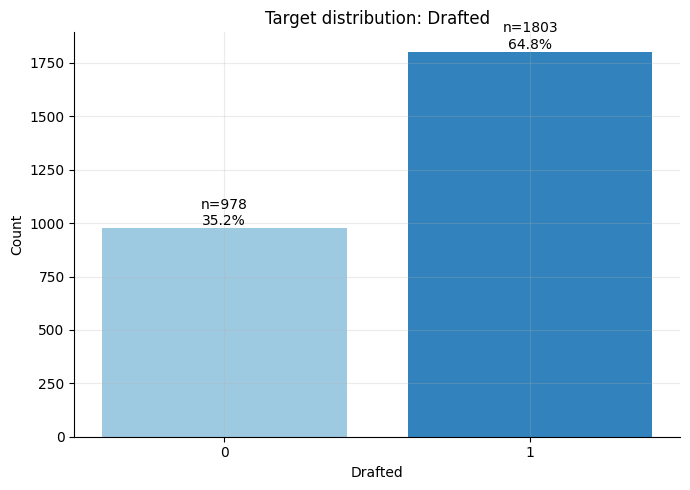


### Section conclusion - Target distribution

**Key takeaways**
- The positive-class rate in train is 64.8%.
- The target is binary and only available in train.

**Why this matters**
- Class balance informs stratified validation and target-rate interpretation.
- ROC-AUC remains the official metric, so ranking quality matters.

**Leakage/validation caution**
- No target-aware plot or table should ever use test data.

**Hypotheses for future phases**
- Use stratified validation later unless a documented alternative is justified.

**Deferred decisions**
- No thresholding, resampling, or objective choice is made in Phase 3.


In [6]:
target_counts = train[TARGET_COLUMN].astype(int).value_counts().sort_index()
target_summary = pd.DataFrame({"Drafted": target_counts.index, "count": target_counts.values, "proportion": target_counts.values / target_counts.sum()})
display_table("Target distribution", target_summary)
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(target_summary["Drafted"].astype(str), target_summary["count"], color=["#9ecae1", "#3182bd"])
for idx, row in target_summary.iterrows():
    ax.text(idx, row["count"], f"n={int(row['count'])}\n{row['proportion']:.1%}", ha="center", va="bottom")
ax.set_title("Target distribution: Drafted")
ax.set_xlabel("Drafted")
ax.set_ylabel("Count")
fig.tight_layout()
save_fig(fig, "phase03_target_distribution.png")
plt.show()
positive_rate = float(train[TARGET_COLUMN].mean())
section_conclusion(
    "Target distribution",
    [f"The positive-class rate in train is {positive_rate:.1%}.", "The target is binary and only available in train."],
    ["Class balance informs stratified validation and target-rate interpretation.", "ROC-AUC remains the official metric, so ranking quality matters."],
    ["No target-aware plot or table should ever use test data."],
    ["Use stratified validation later unless a documented alternative is justified."],
    ["No thresholding, resampling, or objective choice is made in Phase 3."],
)


**Interpretation.** The target is not extremely imbalanced and `Drafted = 1` is the majority class. Because the official metric is ROC-AUC, future features should be evaluated by whether they improve probability ordering, not whether they create a clean 0/1 threshold separation. A feature can be useful even if it only improves ranking within ambiguous cases.


## 8. Missingness Analysis


### 8.1 Missingness by split

**Objective.** Compare missing-value percentages between train and test for columns with missing values.

**Why it matters.** Similar missingness patterns suggest structural consistency, while large deltas may indicate train/test shift.

**Expected output.** Tables, figures, and narrative interpretation directly below the code cell.

**Data used.** Train/test descriptive only.

**Leakage/validation caution.** No imputation strategy is selected here.


**Missingness by split**

,split,column,missing_count,missing_pct
18,test,Age,115,0.165230
2,train,Age,435,0.156419
26,test,Agility_3cone,247,0.354885
10,train,Agility_3cone,970,0.348795
24,test,Bench_Press_Reps,184,0.264368
8,train,Bench_Press_Reps,721,0.259259
25,test,Broad_Jump,147,0.211207
9,train,Broad_Jump,581,0.208918
27,test,Shuttle,228,0.327586
11,train,Shuttle,912,0.327940


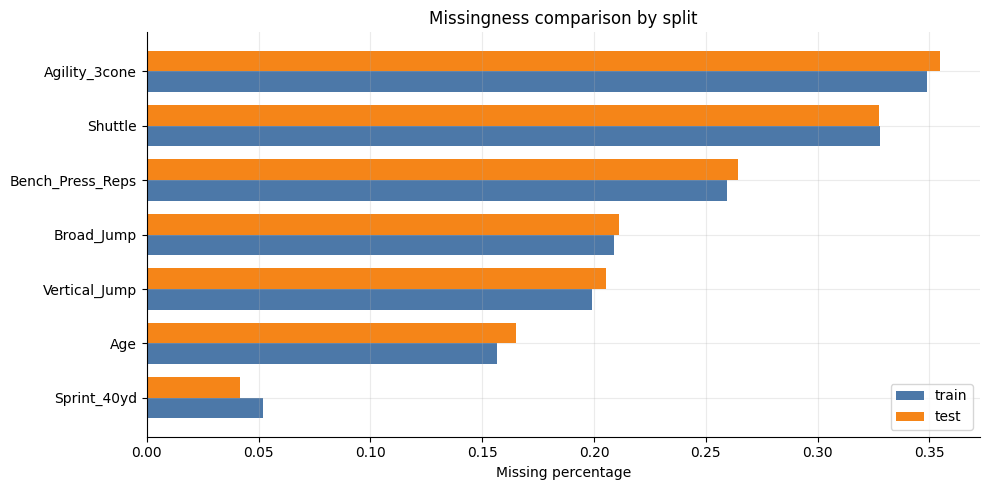

In [7]:
train_missing = missingness_summary(train, "train")
test_missing = missingness_summary(test, "test")
missing_compare = pd.concat([train_missing, test_missing], ignore_index=True)
missing_compare = missing_compare[missing_compare["missing_count"] > 0].sort_values(["column", "split"])
display_table("Missingness by split", missing_compare, max_rows=80)
missing_pivot = missing_compare.pivot(index="column", columns="split", values="missing_pct").fillna(0.0)
missing_pivot = missing_pivot.reindex(missing_pivot.max(axis=1).sort_values(ascending=True).index)
fig, ax = plt.subplots(figsize=(10, max(5, 0.35 * len(missing_pivot))))
y = np.arange(len(missing_pivot))
ax.barh(y - 0.19, missing_pivot.get("train", pd.Series(0, index=missing_pivot.index)), height=0.38, label="train", color="#4c78a8")
ax.barh(y + 0.19, missing_pivot.get("test", pd.Series(0, index=missing_pivot.index)), height=0.38, label="test", color="#f58518")
ax.set_yticks(y)
ax.set_yticklabels(missing_pivot.index)
ax.set_xlabel("Missing percentage")
ax.set_title("Missingness comparison by split")
ax.legend()
fig.tight_layout()
save_fig(fig, "phase03_missingness_train_test_comparison.png")
plt.show()


**Interpretation.** Missingness separates into three analytical subfamilies. First, demographic/record missingness, especially `Age`, appears unusually strong in train-only target-rate diagnostics and may reflect a different data mechanism, profile quality, eligibility/exposure context, or capture process. Second, physical-test missingness in `Sprint_40yd`, `Vertical_Jump`, `Bench_Press_Reps`, `Broad_Jump`, `Agility_3cone`, and `Shuttle` likely describes measurement availability, position norms, or testing context. Third, aggregated completeness and co-missingness describe complete versus incomplete player profiles. Missingness should not be treated only as a cleaning problem, but no missingness indicator is selected in Phase 3.


## 9. Available Measurement Count Analysis


### 9.1 Measurement completeness and target-aware missingness

**Objective.** Analyze available physical measurement count, co-missingness, role/year missingness, and train-only target rates by missingness indicators.

**Why it matters.** Measurement completeness may capture player evaluation context and testing availability.

**Expected output.** Tables, figures, and narrative interpretation directly below the code cell.

**Data used.** Train/test descriptive for missingness structure; train-only for target-rate analyses.

**Leakage/validation caution.** Missingness indicators and available-measurement-count features are hypotheses only and must be tested later using fold-safe validation.


**Available measurement count distribution**

,available_measurement_count,train_count,test_count,train_pct,test_pct
0,0,11,8,0.003955,0.011494
1,1,103,13,0.037037,0.018678
2,2,214,62,0.076951,0.089080
3,3,233,55,0.083783,0.079023
4,4,158,37,0.056814,0.053161
5,5,295,84,0.106077,0.120690
6,6,557,150,0.200288,0.215517
7,7,1210,287,0.435095,0.412356


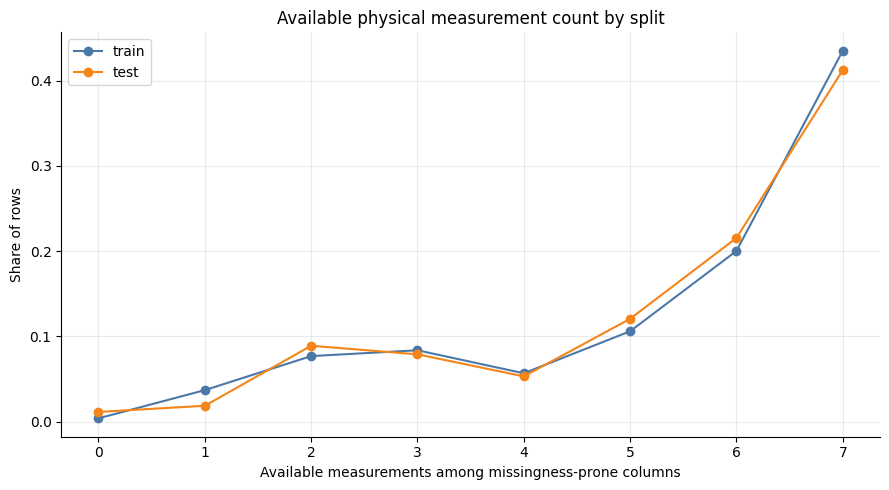

**Train-only Drafted rate by available measurement count**

,available_measurement_count,n,positive_count,target_rate,wilson_low,wilson_high,uncertainty_width,low_n_warning,interpretation
0,0,11,0.0,0.000000,2.775558e-17,0.258840,0.258840,True,unstable_low_n
1,1,103,40.0,0.388350,2.998605e-01,0.484868,0.185007,False,more_stable
2,2,214,126.0,0.588785,5.218577e-01,0.652581,0.130723,False,more_stable
3,3,233,149.0,0.639485,5.760296e-01,0.698415,0.122386,False,more_stable
4,4,158,80.0,0.506329,4.291512e-01,0.583207,0.154055,False,more_stable
5,5,295,167.0,0.566102,5.090532e-01,0.621451,0.112397,False,more_stable
6,6,557,291.0,0.522442,4.809479e-01,0.563628,0.082680,False,more_stable
7,7,1210,950.0,0.785124,7.610973e-01,0.807346,0.046249,False,more_stable


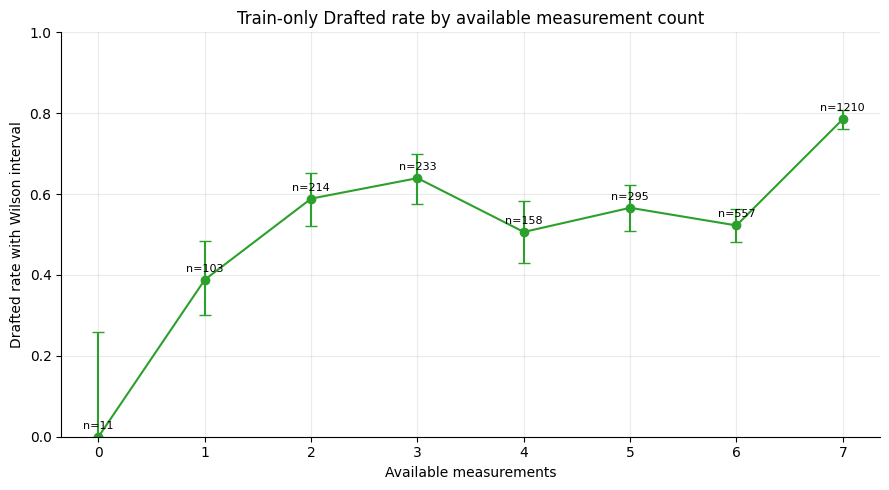

**Train-only Drafted rate by missingness indicator**

,column,status,n,target_rate,wilson_low,wilson_high,low_n_warning
1,Age,missing,435,0.018391,0.009348,0.035866,False
0,Age,observed,2346,0.765132,0.747553,0.781844,False
11,Agility_3cone,missing,970,0.605155,0.574036,0.635444,False
10,Agility_3cone,observed,1811,0.671452,0.649477,0.692702,False
7,Bench_Press_Reps,missing,721,0.601942,0.565762,0.637041,False
6,Bench_Press_Reps,observed,2060,0.664563,0.643884,0.684629,False
9,Broad_Jump,missing,581,0.593804,0.553379,0.632996,False
8,Broad_Jump,observed,2200,0.662727,0.642703,0.682185,False
13,Shuttle,missing,912,0.600877,0.568734,0.632174,False
12,Shuttle,observed,1869,0.671482,0.649856,0.692405,False


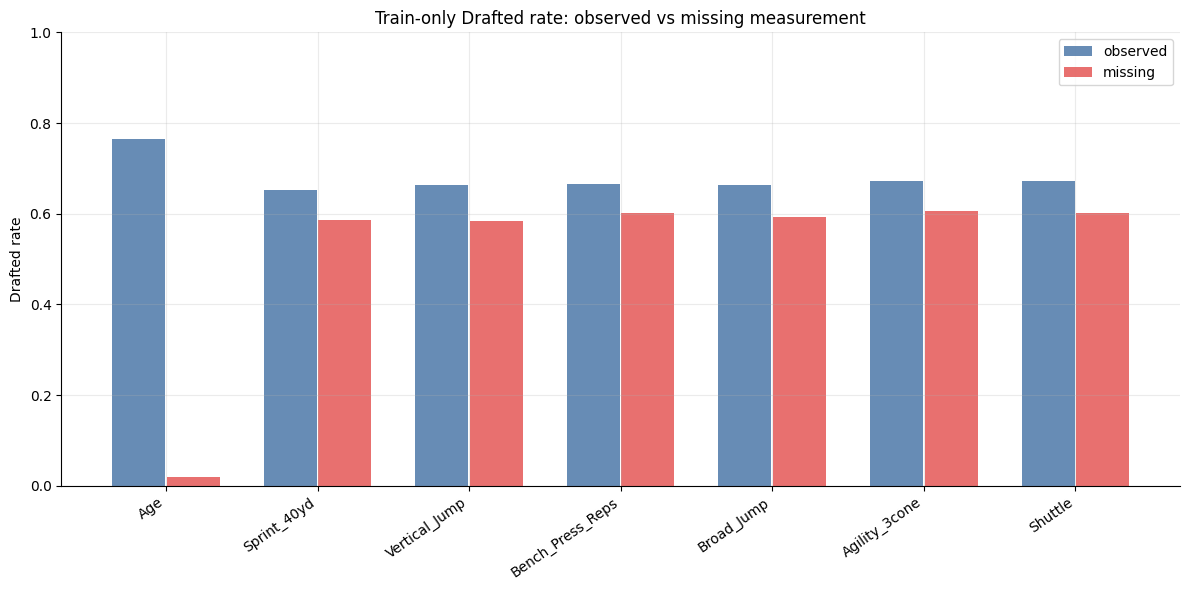

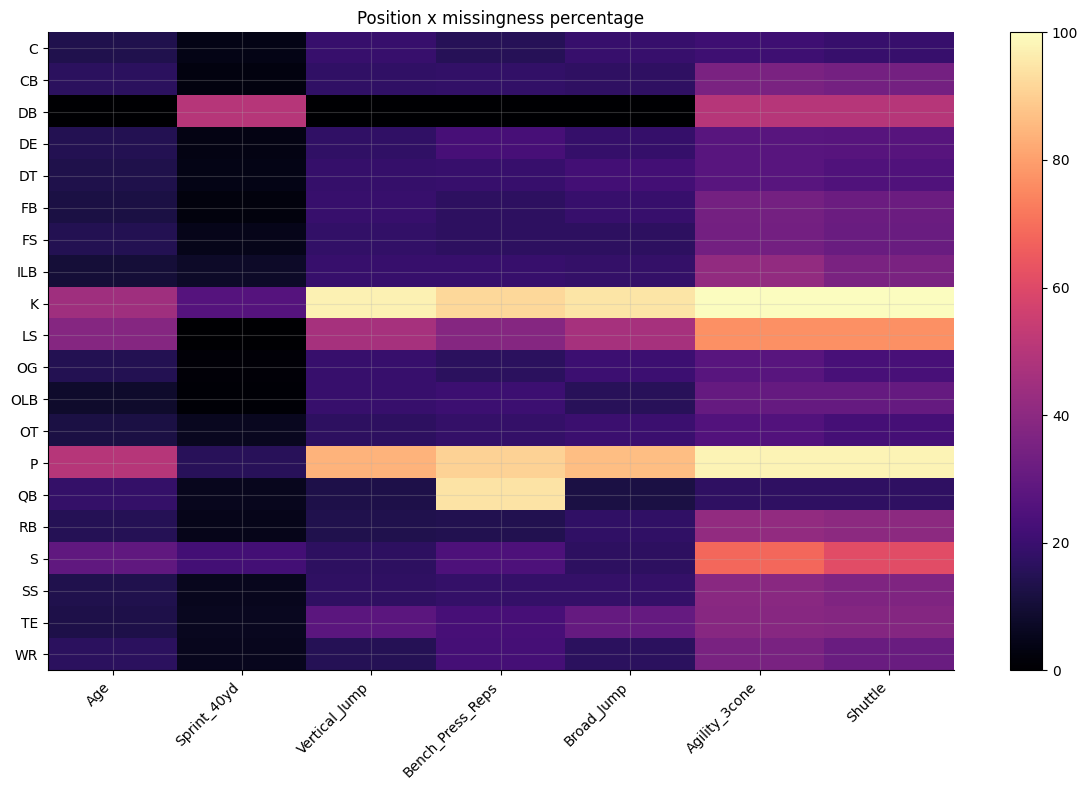

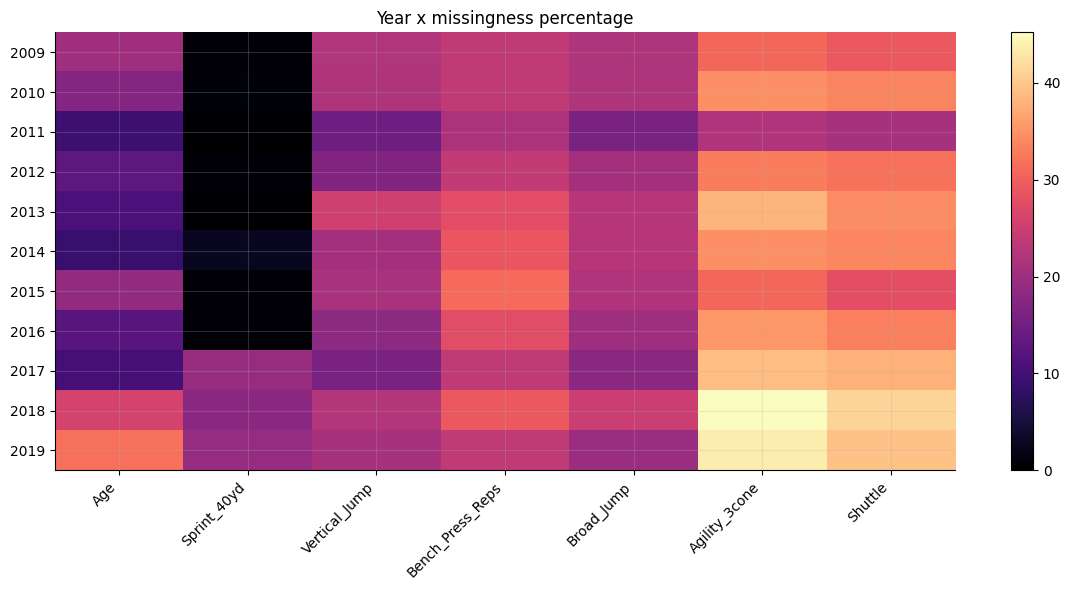

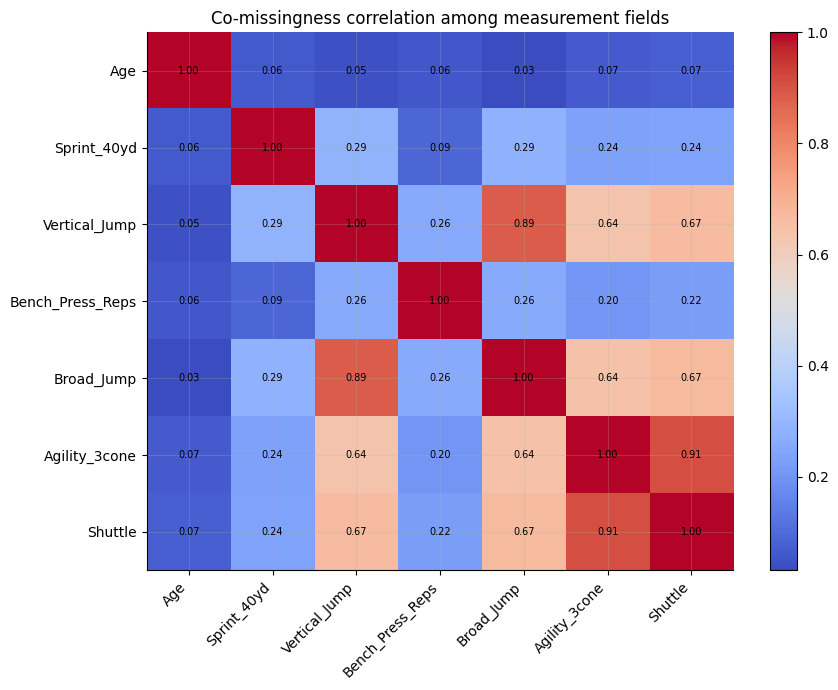

**Available measurement count by Player_Type**

,Player_Type,count,mean,median,min,max
0,defense,1241,5.593876,6.0,0,7
1,offense,1445,5.553633,6.0,0,7
2,special_teams,95,1.915789,2.0,0,7


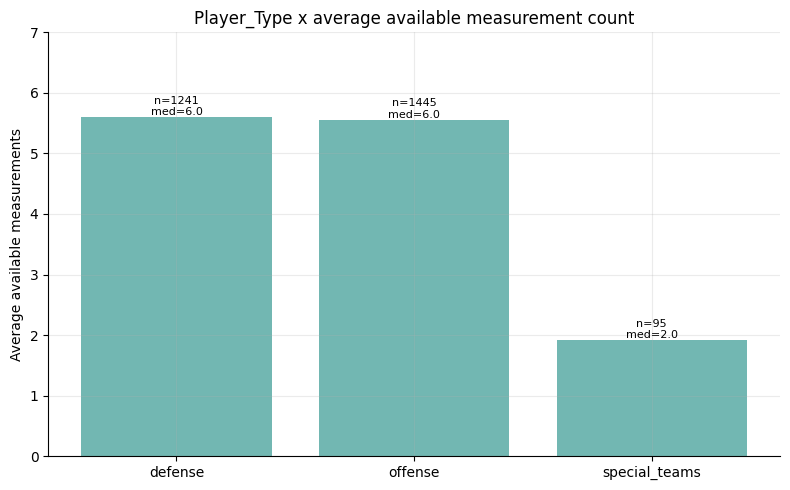


### Section conclusion - Missingness

**Key takeaways**
- Missingness is concentrated in testing/physical fields.
- The train-only Drafted-rate spread across available measurement counts is 0.785.
- Role, year, and co-missingness plots show structured measurement availability.

**Why this matters**
- Missingness may represent evaluation context, position norms, or cohort effects.
- It should be studied as a candidate signal family later.

**Leakage/validation caution**
- Missingness indicators are analysis-only here.
- Target-rate comparisons are train-only and descriptive.

**Hypotheses for future phases**
- Evaluate missingness indicators and available-test-count features later using fold-aware pipelines.
- Check whether missingness effects remain within role groups.

**Deferred decisions**
- No imputation strategy, missing-indicator feature, or row filtering rule is chosen in Phase 3.


In [8]:
train_analysis = train.copy()
test_analysis = test.copy()
train_analysis["available_measurement_count"] = train_analysis[analysis_missingness_columns].notna().sum(axis=1)
test_analysis["available_measurement_count"] = test_analysis[analysis_missingness_columns].notna().sum(axis=1)
available_count_table = pd.concat([
    train_analysis["available_measurement_count"].value_counts().sort_index().rename("train_count"),
    test_analysis["available_measurement_count"].value_counts().sort_index().rename("test_count"),
], axis=1).fillna(0).astype(int)
available_count_table["train_pct"] = available_count_table["train_count"] / len(train_analysis)
available_count_table["test_pct"] = available_count_table["test_count"] / len(test_analysis)
display_table("Available measurement count distribution", available_count_table.reset_index().rename(columns={"index": "available_measurement_count"}), max_rows=30)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(available_count_table.index, available_count_table["train_pct"], marker="o", label="train", color="#4c78a8")
ax.plot(available_count_table.index, available_count_table["test_pct"], marker="o", label="test", color="#f58518")
ax.set_title("Available physical measurement count by split")
ax.set_xlabel("Available measurements among missingness-prone columns")
ax.set_ylabel("Share of rows")
ax.legend()
fig.tight_layout()
save_fig(fig, "phase03_available_measurement_count_distribution.png")
plt.show()
available_rate = target_rate_table(train_analysis, "available_measurement_count", min_n_warning=30).sort_values("available_measurement_count")
display_table("Train-only Drafted rate by available measurement count", available_rate, max_rows=30)
fig, ax = plt.subplots(figsize=(9, 5))
available_lower_err = np.maximum((available_rate["target_rate"] - available_rate["wilson_low"]).to_numpy(dtype=float), 0)
available_upper_err = np.maximum((available_rate["wilson_high"] - available_rate["target_rate"]).to_numpy(dtype=float), 0)
ax.errorbar(
    available_rate["available_measurement_count"].to_numpy(dtype=float),
    available_rate["target_rate"].to_numpy(dtype=float),
    yerr=[available_lower_err, available_upper_err],
    marker="o",
    capsize=4,
    color="#2ca02c",
)
for _, row in available_rate.iterrows():
    ax.text(row["available_measurement_count"], row["target_rate"] + 0.02, f"n={int(row['n'])}", ha="center", fontsize=8)
ax.set_ylim(0, 1)
ax.set_title("Train-only Drafted rate by available measurement count")
ax.set_xlabel("Available measurements")
ax.set_ylabel("Drafted rate with Wilson interval")
fig.tight_layout()
save_fig(fig, "phase03_available_measurement_count_vs_target_rate.png")
plt.show()
indicator_rows = []
for col in analysis_missingness_columns:
    temp = train[[TARGET_COLUMN]].copy()
    temp["indicator"] = np.where(train[col].isna(), "missing", "observed")
    rates = target_rate_table(temp, "indicator", min_n_warning=30)
    for _, row in rates.iterrows():
        indicator_rows.append({"column": col, "status": row["indicator"], "n": int(row["n"]), "target_rate": row["target_rate"], "wilson_low": row["wilson_low"], "wilson_high": row["wilson_high"], "low_n_warning": row["low_n_warning"]})
missing_indicator_target = pd.DataFrame(indicator_rows)
display_table("Train-only Drafted rate by missingness indicator", missing_indicator_target.sort_values(["column", "status"]), max_rows=80)
fig, ax = plt.subplots(figsize=(12, 6))
x_labels = analysis_missingness_columns
x = np.arange(len(x_labels))
for offset, status, color in [(-0.18, "observed", "#4c78a8"), (0.18, "missing", "#e45756")]:
    status_df = missing_indicator_target[missing_indicator_target["status"] == status].set_index("column").reindex(x_labels)
    ax.bar(x + offset, status_df["target_rate"], width=0.35, label=status, color=color, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=35, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("Drafted rate")
ax.set_title("Train-only Drafted rate: observed vs missing measurement")
ax.legend()
fig.tight_layout()
save_fig(fig, "phase03_missingness_indicator_vs_target_rate.png")
plt.show()
position_missingness = train.groupby("Position")[analysis_missingness_columns].apply(lambda df: df.isna().mean()).sort_index()
fig, ax = heatmap_plot(position_missingness * 100, "Position x missingness percentage", cmap="magma", figsize=(12, 8))
save_fig(fig, "phase03_position_missingness_heatmap.png")
plt.show()
year_missingness = train.groupby("Year")[analysis_missingness_columns].apply(lambda df: df.isna().mean()).sort_index()
fig, ax = heatmap_plot(year_missingness * 100, "Year x missingness percentage", cmap="magma", figsize=(12, 6))
save_fig(fig, "phase03_year_missingness_heatmap.png")
plt.show()
missing_corr = train[analysis_missingness_columns].isna().astype(int).corr()
fig, ax = heatmap_plot(missing_corr, "Co-missingness correlation among measurement fields", cmap="coolwarm", center=0, annotate=True, figsize=(9, 7))
save_fig(fig, "phase03_missingness_comissingness_heatmap.png")
plt.show()
player_available = train_analysis.groupby("Player_Type")["available_measurement_count"].agg(["count", "mean", "median", "min", "max"]).reset_index()
display_table("Available measurement count by Player_Type", player_available)
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(player_available["Player_Type"].astype(str), player_available["mean"], color="#72b7b2")
for idx, row in player_available.iterrows():
    ax.text(idx, row["mean"], f"n={int(row['count'])}\nmed={row['median']:.1f}", ha="center", va="bottom", fontsize=8)
ax.set_ylim(0, len(analysis_missingness_columns))
ax.set_title("Player_Type x average available measurement count")
ax.set_ylabel("Average available measurements")
fig.tight_layout()
save_fig(fig, "phase03_player_type_available_measurement_count.png")
plt.show()
measurement_spread = float(available_rate["target_rate"].max() - available_rate["target_rate"].min())
section_conclusion(
    "Missingness",
    ["Missingness is concentrated in testing/physical fields.", f"The train-only Drafted-rate spread across available measurement counts is {measurement_spread:.3f}.", "Role, year, and co-missingness plots show structured measurement availability."],
    ["Missingness may represent evaluation context, position norms, or cohort effects.", "It should be studied as a candidate signal family later."],
    ["Missingness indicators are analysis-only here.", "Target-rate comparisons are train-only and descriptive."],
    ["Evaluate missingness indicators and available-test-count features later using fold-aware pipelines.", "Check whether missingness effects remain within role groups."],
    ["No imputation strategy, missing-indicator feature, or row filtering rule is chosen in Phase 3."],
)


**Interpretation.** `available_measurement_count` may capture player evaluation context, but the useful pattern may not be a perfectly linear count effect. Future candidates could include the raw count, `is_complete_measurement_profile`, `has_low_measurement_profile`, and interactions with `Player_Type` or `Position_Type`. Before trusting measurement completeness as an independent signal, later phases should test whether it remains informative within Player_Type and Position_Type slices. These are future hypotheses only.


## 10. Numeric and Physical Metric Analysis


### 10.1 Numeric summaries, train/test overlays, role profiles, and outliers

**Objective.** Summarize numeric variables, compare train/test distributions, inspect physical profiles by `Position_Type`, and diagnose outliers by position.

**Why it matters.** Physical measurements are central candidate signals but are role-dependent and can be misleading globally.

**Expected output.** Tables, figures, and narrative interpretation directly below the code cell.

**Data used.** Train/test descriptive overlays; train-only role/outlier summaries.

**Leakage/validation caution.** No scaling, clipping, winsorization, transformation, or row removal is selected.


**Numeric summary - train**

,column,count,missing,mean,std,min,q01,q05,q25,median,q75,q95,q99,max,iqr
0,Year,2781,0,2013.838907,3.083247,2009.000000,2009.000000,2009.000000,2011.000000,2014.000000,2017.000000,2019.000000,2019.000000,2019.000000,6.000000
1,Age,2346,435,21.997016,0.964836,18.000000,20.000000,21.000000,21.000000,22.000000,23.000000,23.000000,24.000000,28.000000,2.000000
2,Height,2781,0,1.873590,0.067178,1.651000,1.727200,1.752600,1.828800,1.879600,1.930400,1.981200,2.006600,2.082800,0.101600
3,Weight,2781,0,109.502026,20.307239,67.585263,79.832257,84.368181,92.986436,104.779837,124.284309,144.695966,151.499852,162.386068,31.297874
4,Sprint_40yd,2636,145,4.764818,0.299343,4.220000,4.330000,4.400000,4.530000,4.680000,4.950000,5.340000,5.540000,6.000000,0.420000
5,Vertical_Jump,2227,554,83.506349,10.710691,44.450000,57.480200,64.770000,76.200000,83.820000,91.440000,100.330000,105.410000,114.300000,15.240000
6,Bench_Press_Reps,2060,721,20.236408,6.410662,2.000000,7.000000,11.000000,16.000000,20.000000,24.000000,31.000000,36.000000,45.000000,8.000000
7,Broad_Jump,2200,581,291.985700,23.924666,198.120000,231.140000,246.380000,276.860000,294.640000,307.340000,327.660000,340.360000,373.380000,30.480000
8,Agility_3cone,1811,970,7.230447,0.410686,6.280000,6.560000,6.700000,6.930000,7.130000,7.490000,8.025000,8.279000,9.040000,0.560000
9,Shuttle,1869,912,4.399422,0.263851,3.820000,3.950000,4.060000,4.200000,4.350000,4.560000,4.900000,5.070000,5.560000,0.360000


**Numeric summary - test**

,column,count,missing,mean,std,min,q01,q05,q25,median,q75,q95,q99,max,iqr
0,Year,696,0,2013.762931,3.046376,2009.000000,2009.000000,2009.000000,2011.000000,2014.000000,2016.00000,2019.000000,2019.000000,2019.000000,5.000000
1,Age,581,115,21.927711,0.986953,19.000000,20.000000,20.000000,21.000000,22.000000,23.00000,23.000000,24.000000,27.000000,2.000000
2,Height,696,0,1.875476,0.068770,1.676400,1.727200,1.752600,1.828800,1.879600,1.93040,1.981200,2.006600,2.032000,0.101600
3,Weight,696,0,110.722810,21.161295,76.657111,80.739442,84.821773,92.986436,104.779837,131.99538,146.510335,153.858532,167.375585,39.008944
4,Sprint_40yd,667,29,4.785922,0.309420,4.280000,4.336600,4.420000,4.540000,4.700000,5.00500,5.370000,5.500000,5.760000,0.465000
5,Vertical_Jump,553,143,82.933526,10.544504,52.070000,57.810400,64.770000,74.930000,83.820000,90.17000,99.060000,106.019600,111.760000,15.240000
6,Bench_Press_Reps,512,184,20.259766,6.842719,6.000000,7.000000,9.000000,15.000000,20.000000,25.00000,32.000000,36.000000,49.000000,10.000000
7,Broad_Jump,549,147,290.203097,24.074513,210.820000,226.060000,246.380000,276.860000,294.640000,307.34000,325.120000,337.820000,345.440000,30.480000
8,Agility_3cone,449,247,7.265523,0.407634,6.500000,6.560000,6.714000,6.980000,7.180000,7.50000,8.048000,8.315200,8.720000,0.520000
9,Shuttle,468,228,4.421496,0.270203,3.810000,3.953400,4.030000,4.220000,4.380000,4.59250,4.900000,5.090000,5.380000,0.372500


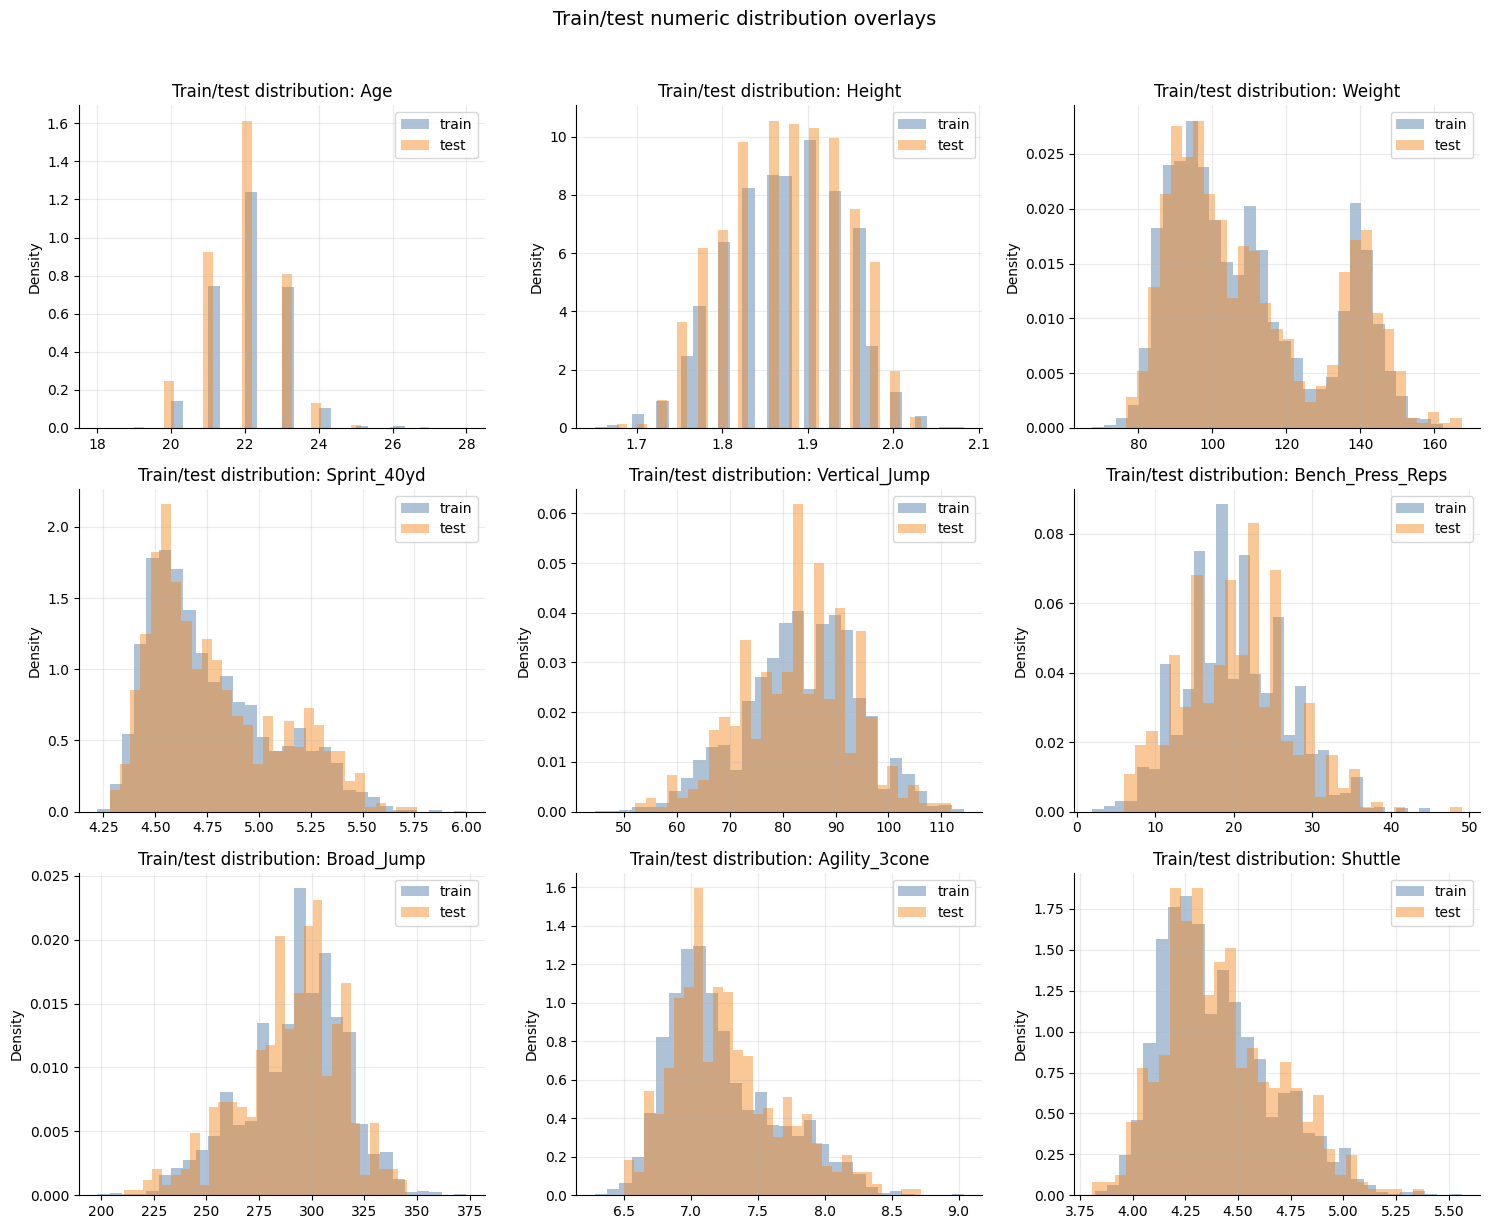

**Position_Type physical metric medians**

,Position_Type,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle
0,backs_receivers,1.8542,97.975952,4.580,86.36,17.0,299.72,7.030,4.28
1,defensive_back,1.8288,89.811289,4.510,90.17,15.0,307.34,6.930,4.18
2,defensive_lineman,1.9050,131.541787,4.935,78.74,26.0,279.40,7.460,4.55
3,kicking_specialist,1.8542,94.347213,4.930,80.01,19.0,292.10,7.280,4.41
4,line_backer,1.8796,109.769353,4.710,85.09,22.0,297.18,7.095,4.31
5,offensive_lineman,1.9558,141.067227,5.240,69.85,25.0,259.08,7.830,4.75
6,other_special,1.9050,110.222946,5.000,73.66,15.5,281.94,7.260,4.38


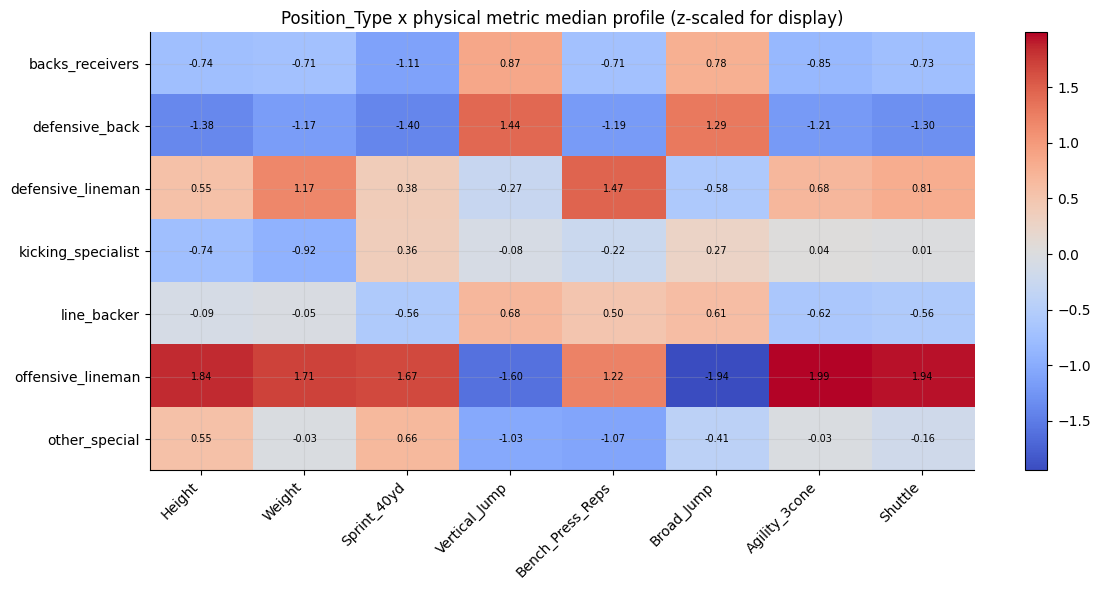

**Outlier diagnostics by metric and position**

,scope,group,column,n,lower_fence,upper_fence,outlier_count,outlier_rate
132,within_position,FB,Shuttle,28,4.125000,4.645000,3,0.107143
1,within_position,C,Height,72,1.866900,1.968500,7,0.097222
12,within_position,OT,Height,212,1.917700,2.019300,19,0.089623
124,within_position,SS,Agility_3cone,53,6.505000,7.345000,4,0.075472
115,within_position,FB,Agility_3cone,27,6.772500,7.672500,2,0.074074
48,within_position,K,Sprint_40yd,28,4.591250,5.181250,2,0.071429
140,within_position,S,Shuttle,16,3.865000,4.545000,1,0.062500
24,within_position,DT,Weight,200,124.284309,153.314221,11,0.055000
105,within_position,RB,Broad_Jump,206,269.240000,330.200000,11,0.053398
128,within_position,C,Shuttle,58,4.360000,5.000000,3,0.051724


Showing first 50 of 144 rows.

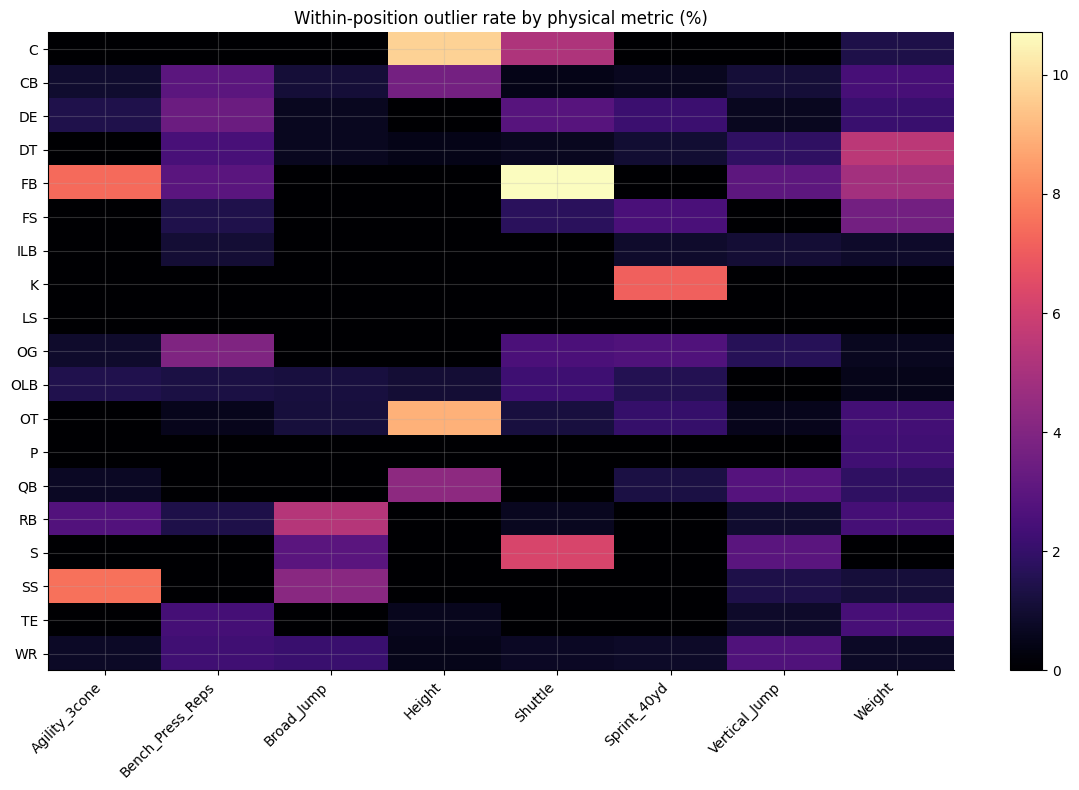


### Section conclusion - Numeric and physical profiles

**Key takeaways**
- Numeric summaries and overlays reveal different ranges, missingness, and train/test shapes.
- Position_Type median profiles show physical metrics should not be interpreted only globally.
- Outliers differ by position.

**Why this matters**
- Physical measurements have role-dependent meanings.
- Outliers require context before later clipping or transformations are considered.

**Leakage/validation caution**
- No scaling, clipping, transformation, or outlier removal is performed here.
- Train/test overlays are descriptive only.

**Hypotheses for future phases**
- Test role-specific profiles and possible interactions later under fold-safe validation.

**Deferred decisions**
- No numeric transformation, imputation strategy, or outlier policy is selected.


In [9]:
num_summary_train = numeric_summary(train, numeric_columns)
num_summary_test = numeric_summary(test, [col for col in numeric_columns if col in test.columns])
display_table("Numeric summary - train", num_summary_train, max_rows=80)
display_table("Numeric summary - test", num_summary_test, max_rows=80)
plot_cols = [col for col in ["Age"] + analysis_physical_columns if col in test.columns]
ncols = 3
nrows = int(np.ceil(len(plot_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, plot_cols):
    ax.hist(train[col].dropna(), bins=30, density=True, alpha=0.45, label="train", color="#4c78a8")
    ax.hist(test[col].dropna(), bins=30, density=True, alpha=0.45, label="test", color="#f58518")
    ax.set_title(f"Train/test distribution: {col}")
    ax.set_ylabel("Density")
    ax.legend()
for ax in axes[len(plot_cols):]:
    ax.axis("off")
fig.suptitle("Train/test numeric distribution overlays", y=1.02, fontsize=14)
fig.tight_layout()
save_fig(fig, "phase03_train_test_numeric_distribution_overlays.png")
plt.show()
physical_medians = train.groupby("Position_Type")[analysis_physical_columns].median(numeric_only=True)
physical_medians_scaled = (physical_medians - physical_medians.mean()) / physical_medians.std(ddof=0)
display_table("Position_Type physical metric medians", physical_medians.reset_index(), max_rows=40)
fig, ax = heatmap_plot(physical_medians_scaled, "Position_Type x physical metric median profile (z-scaled for display)", cmap="coolwarm", center=0, annotate=True, figsize=(12, 6))
save_fig(fig, "phase03_position_type_physical_metric_median_heatmap.png")
plt.show()
outlier_rows = []
for col in analysis_physical_columns:
    q1 = train[col].quantile(0.25)
    q3 = train[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    outlier_rows.append({"scope": "global", "group": "all", "column": col, "n": int(train[col].notna().sum()), "lower_fence": low, "upper_fence": high, "outlier_count": int(((train[col] < low) | (train[col] > high)).sum())})
    for group, group_df in train.groupby("Position"):
        s = group_df[col].dropna()
        if len(s) < 10:
            continue
        gq1 = s.quantile(0.25)
        gq3 = s.quantile(0.75)
        giqr = gq3 - gq1
        glow = gq1 - 1.5 * giqr
        ghigh = gq3 + 1.5 * giqr
        outlier_rows.append({"scope": "within_position", "group": group, "column": col, "n": int(len(s)), "lower_fence": glow, "upper_fence": ghigh, "outlier_count": int(((s < glow) | (s > ghigh)).sum())})
outlier_df = pd.DataFrame(outlier_rows)
outlier_df["outlier_rate"] = outlier_df["outlier_count"] / outlier_df["n"]
display_table("Outlier diagnostics by metric and position", outlier_df.sort_values("outlier_rate", ascending=False), max_rows=50)
position_outlier_rate = outlier_df[outlier_df["scope"] == "within_position"].pivot(index="group", columns="column", values="outlier_rate").fillna(0)
fig, ax = heatmap_plot(position_outlier_rate * 100, "Within-position outlier rate by physical metric (%)", cmap="magma", figsize=(12, 8))
save_fig(fig, "phase03_outlier_diagnostics_by_position.png")
plt.show()
section_conclusion(
    "Numeric and physical profiles",
    ["Numeric summaries and overlays reveal different ranges, missingness, and train/test shapes.", "Position_Type median profiles show physical metrics should not be interpreted only globally.", "Outliers differ by position."],
    ["Physical measurements have role-dependent meanings.", "Outliers require context before later clipping or transformations are considered."],
    ["No scaling, clipping, transformation, or outlier removal is performed here.", "Train/test overlays are descriptive only."],
    ["Test role-specific profiles and possible interactions later under fold-safe validation."],
    ["No numeric transformation, imputation strategy, or outlier policy is selected."],
)


**Interpretation.** Physical metrics cannot be interpreted globally only. The same `Sprint_40yd`, `Weight`, `Height`, jump, agility, or shuttle value can mean different things by `Position_Type`. Lower is usually better for `Sprint_40yd`, `Agility_3cone`, and `Shuttle`; higher is usually better for `Vertical_Jump`, `Broad_Jump`, and `Bench_Press_Reps`; `Height` and `Weight` are role-dependent, not universally better when higher. Physical outliers are not automatically bad data: exceptional athletes may look like outliers, and global outlier removal can be harmful.


## 11. Categorical Analysis and Target-Rate Uncertainty


### 11.1 Cardinality, category overlap, Wilson intervals, and school instability

**Objective.** Analyze categorical cardinality, train/test overlap, target rates with sample size, Wilson uncertainty intervals, school cumulative coverage, and school target-rate instability.

**Why it matters.** Categorical fields may contain signal but also high-cardinality overfitting risk.

**Expected output.** Tables, figures, and narrative interpretation directly below the code cell.

**Data used.** Train/test descriptive for overlap and cardinality; train-only for target rates.

**Leakage/validation caution.** No target encoding, category grouping, or final categorical encoding is performed.


**Categorical cardinality and overlap**

,column,train_unique,test_unique,train_cardinality_ratio,test_cardinality_ratio,train_only_categories,test_only_categories,rare_train_categories_n_lt_10
0,School,236,147,0.084862,0.211207,106,17,151
1,Player_Type,3,3,0.001079,0.004310,0,0,0
2,Position_Type,7,6,0.002517,0.008621,1,0,0
3,Position,20,18,0.007192,0.025862,2,0,1


**Target rates by Position_Type with Wilson intervals**

,Position_Type,n,positive_count,target_rate,wilson_low,wilson_high,uncertainty_width,low_n_warning,interpretation
4,line_backer,309,225.0,0.728155,0.675972,0.774735,0.098763,False,more_stable
2,defensive_lineman,391,277.0,0.708440,0.661537,0.751287,0.089750,False,more_stable
1,defensive_back,541,365.0,0.674677,0.634086,0.712803,0.078717,False,more_stable
5,offensive_lineman,435,289.0,0.664368,0.618724,0.707134,0.088409,False,more_stable
0,backs_receivers,1010,622.0,0.615842,0.585459,0.645346,0.059888,False,more_stable
6,other_special,13,4.0,0.307692,0.126805,0.576311,0.449506,True,unstable_low_n
3,kicking_specialist,82,21.0,0.256098,0.174034,0.359991,0.185956,False,more_stable


**Target rates by Position with Wilson intervals**

...

**Target rates by Player_Type with Wilson intervals**

,Player_Type,n,positive_count,target_rate,wilson_low,wilson_high,uncertainty_width,low_n_warning,interpretation
0,defense,1241,867.0,0.698630,0.672520,0.723515,0.050995,False,more_stable
1,offense,1445,911.0,0.630450,0.605247,0.654961,0.049714,False,more_stable
2,special_teams,95,25.0,0.263158,0.185064,0.359662,0.174598,False,more_stable


**School target-rate table sorted by rate; low-n categories are unstable**

,School,n,positive_count,target_rate,wilson_low,wilson_high,uncertainty_width,low_n_warning,interpretation
147,Ohio,4,4.0,1.0,0.510100,1.0,0.489900,True,unstable_low_n
0,Abilene Christian,3,3.0,1.0,0.438494,1.0,0.561506,True,unstable_low_n
61,Florida International,3,3.0,1.0,0.438494,1.0,0.561506,True,unstable_low_n
69,Georgia Southern,3,3.0,1.0,0.438494,1.0,0.561506,True,unstable_low_n
106,Maine,3,3.0,1.0,0.438494,1.0,0.561506,True,unstable_low_n
142,Northern Illinois,3,3.0,1.0,0.438494,1.0,0.561506,True,unstable_low_n
168,Samford,3,3.0,1.0,0.438494,1.0,0.561506,True,unstable_low_n
3,Ala-Birmingham,2,2.0,1.0,0.342372,1.0,0.657628,True,unstable_low_n
28,Cal Poly,2,2.0,1.0,0.342372,1.0,0.657628,True,unstable_low_n
38,Citadel,2,2.0,1.0,0.342372,1.0,0.657628,True,unstable_low_n


Showing first 30 of 236 rows.

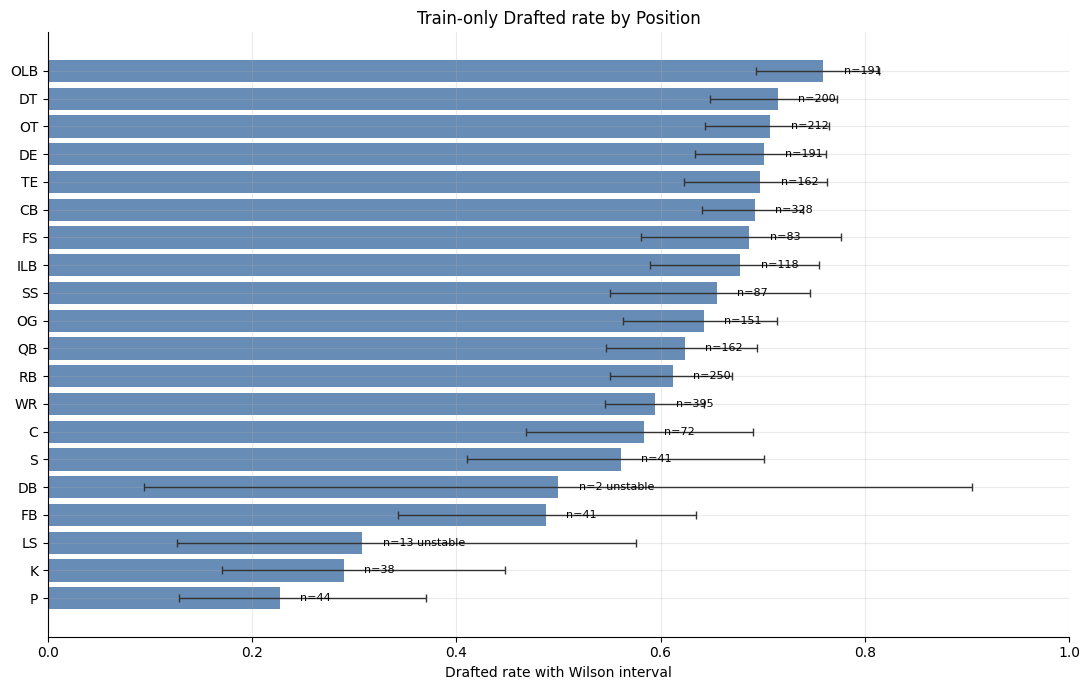

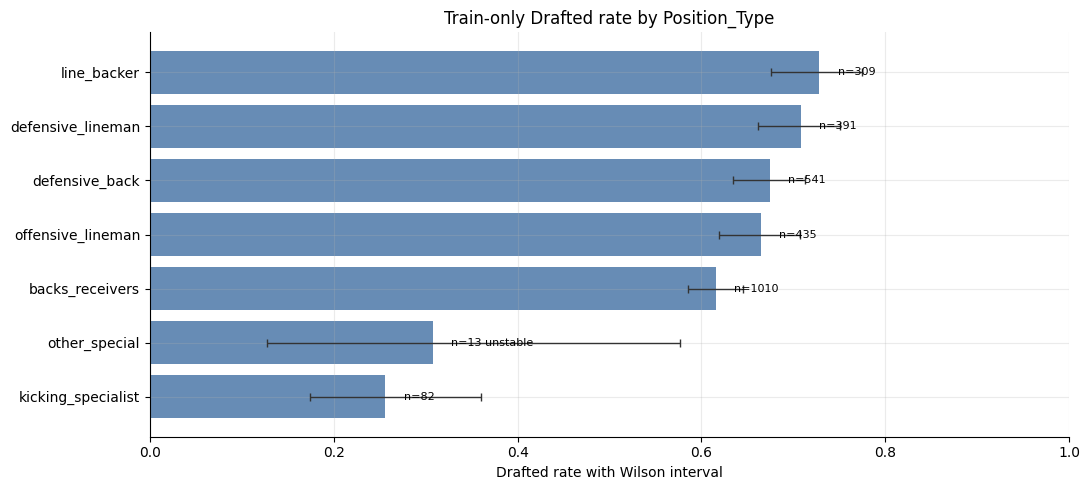

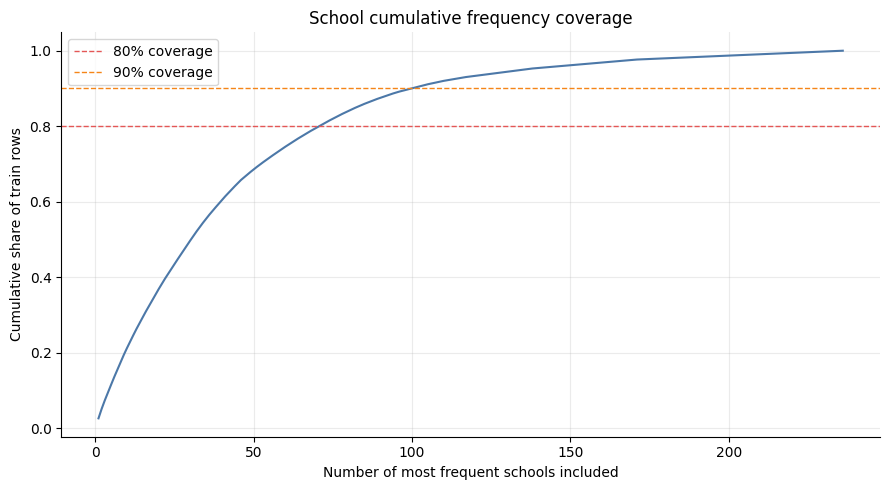

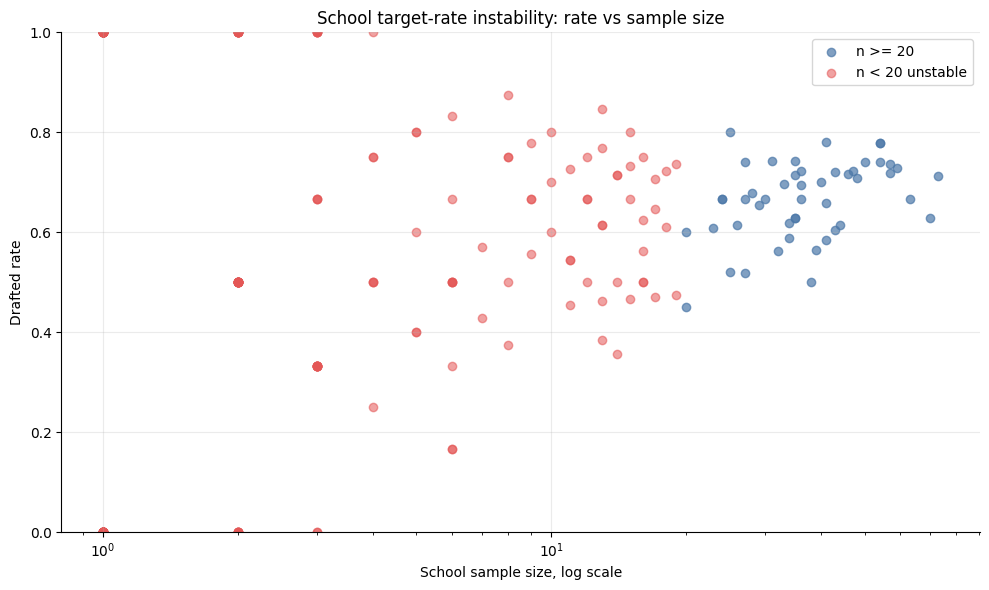


### Section conclusion - Categorical analysis

**Key takeaways**
- Categorical variables include both low-cardinality role fields and high-cardinality School.
- 83 above-baseline school rates are low-n unstable.
- Schools with Wilson lower bound above global train rate and sufficient n: 2.

**Why this matters**
- Target-rate plots without sample size can be misleading.
- Category overlap and long-tail behavior shape later encoding risk.

**Leakage/validation caution**
- Target rates are train-only and descriptive, not target encoding.
- High-cardinality variables can overfit without fold-aware validation.

**Hypotheses for future phases**
- Study safe categorical encodings later, especially for School.
- Consider rare-category handling only after validation strategy is locked.

**Deferred decisions**
- No category is grouped, encoded, dropped, or selected in Phase 3.


In [10]:
cardinality_rows = []
for col in observed_categorical_columns:
    train_values = set(train[col].dropna().astype(str))
    test_values = set(test[col].dropna().astype(str))
    cardinality_rows.append({
        "column": col,
        "train_unique": train[col].nunique(dropna=False),
        "test_unique": test[col].nunique(dropna=False),
        "train_cardinality_ratio": train[col].nunique(dropna=False) / len(train),
        "test_cardinality_ratio": test[col].nunique(dropna=False) / len(test),
        "train_only_categories": len(train_values - test_values),
        "test_only_categories": len(test_values - train_values),
        "rare_train_categories_n_lt_10": int((train[col].value_counts(dropna=False) < 10).sum()),
    })
cardinality_df = pd.DataFrame(cardinality_rows)
display_table("Categorical cardinality and overlap", cardinality_df)
position_type_rates = target_rate_table(train, "Position_Type", min_n_warning=20)
position_rates = target_rate_table(train, "Position", min_n_warning=20)
player_type_rates = target_rate_table(train, "Player_Type", min_n_warning=20)
school_rates = target_rate_table(train, "School", min_n_warning=20)
display_table("Target rates by Position_Type with Wilson intervals", position_type_rates, max_rows=30)
display_table("Target rates by Position with Wilson intervals", position_rates, max_rows=40)
display_table("Target rates by Player_Type with Wilson intervals", player_type_rates, max_rows=20)
display_table("School target-rate table sorted by rate; low-n categories are unstable", school_rates, max_rows=30)
plot_target_rate_bars(position_rates, "Position", "Train-only Drafted rate by Position", max_categories=20, filename="phase03_position_target_rate_with_uncertainty.png")
plt.show()
plot_target_rate_bars(position_type_rates, "Position_Type", "Train-only Drafted rate by Position_Type", max_categories=20, filename="phase03_position_type_target_rate_with_uncertainty.png")
plt.show()
school_freq = train["School"].astype(str).value_counts().reset_index()
school_freq.columns = ["School", "count"]
school_freq["coverage"] = school_freq["count"].cumsum() / len(train)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(np.arange(1, len(school_freq) + 1), school_freq["coverage"], color="#4c78a8")
ax.set_title("School cumulative frequency coverage")
ax.set_xlabel("Number of most frequent schools included")
ax.set_ylabel("Cumulative share of train rows")
ax.axhline(0.80, color="#e45756", linestyle="--", linewidth=1, label="80% coverage")
ax.axhline(0.90, color="#f58518", linestyle="--", linewidth=1, label="90% coverage")
ax.legend()
fig.tight_layout()
save_fig(fig, "phase03_school_frequency_cumulative_coverage.png")
plt.show()
fig, ax = plt.subplots(figsize=(10, 6))
stable = school_rates[~school_rates["low_n_warning"]]
unstable = school_rates[school_rates["low_n_warning"]]
ax.scatter(stable["n"], stable["target_rate"], alpha=0.7, label="n >= 20", color="#4c78a8")
ax.scatter(unstable["n"], unstable["target_rate"], alpha=0.55, label="n < 20 unstable", color="#e45756")
ax.set_xscale("log")
ax.set_ylim(0, 1)
ax.set_title("School target-rate instability: rate vs sample size")
ax.set_xlabel("School sample size, log scale")
ax.set_ylabel("Drafted rate")
ax.legend()
fig.tight_layout()
save_fig(fig, "phase03_school_target_rate_instability.png")
plt.show()
reliable_high_school = school_rates[(~school_rates["low_n_warning"]) & (school_rates["wilson_low"] > positive_rate)]
high_but_unstable_school = school_rates[(school_rates["target_rate"] > positive_rate) & (school_rates["low_n_warning"])]
section_conclusion(
    "Categorical analysis",
    ["Categorical variables include both low-cardinality role fields and high-cardinality School.", f"{len(high_but_unstable_school)} above-baseline school rates are low-n unstable.", f"Schools with Wilson lower bound above global train rate and sufficient n: {len(reliable_high_school)}."],
    ["Target-rate plots without sample size can be misleading.", "Category overlap and long-tail behavior shape later encoding risk."],
    ["Target rates are train-only and descriptive, not target encoding.", "High-cardinality variables can overfit without fold-aware validation."],
    ["Study safe categorical encodings later, especially for School.", "Consider rare-category handling only after validation strategy is locked."],
    ["No category is grouped, encoded, dropped, or selected in Phase 3."],
)


**Interpretation.** `School` is not a normal low-cardinality categorical feature. It may contain useful institutional signal, but it is one of the highest-risk variables for overfitting: many schools are rare, low-n target rates can be extreme but unreliable, and test-only schools make naive encodings fragile. Future use should be staged and ablated: no School, safe frequency/count encoding, rare-category handling inside folds, and only if justified, strictly out-of-fold target encoding with smoothing or CatBoost-style handling under careful validation. No target encoding is performed in Phase 3.


## 12. Train/Test Shift Diagnostics


### 12.1 Descriptive drift diagnostics

**Objective.** Compare categorical normalized frequency deltas, numeric descriptive CDF distances, year distribution, and Year x Position_Type composition.

**Why it matters.** Train/test shift can weaken validation reliability even when the data contract passes.

**Expected output.** Tables, figures, and narrative interpretation directly below the code cell.

**Data used.** Train/test descriptive only.

**Leakage/validation caution.** Drift should guide future slice diagnostics, not test-tuned preprocessing.


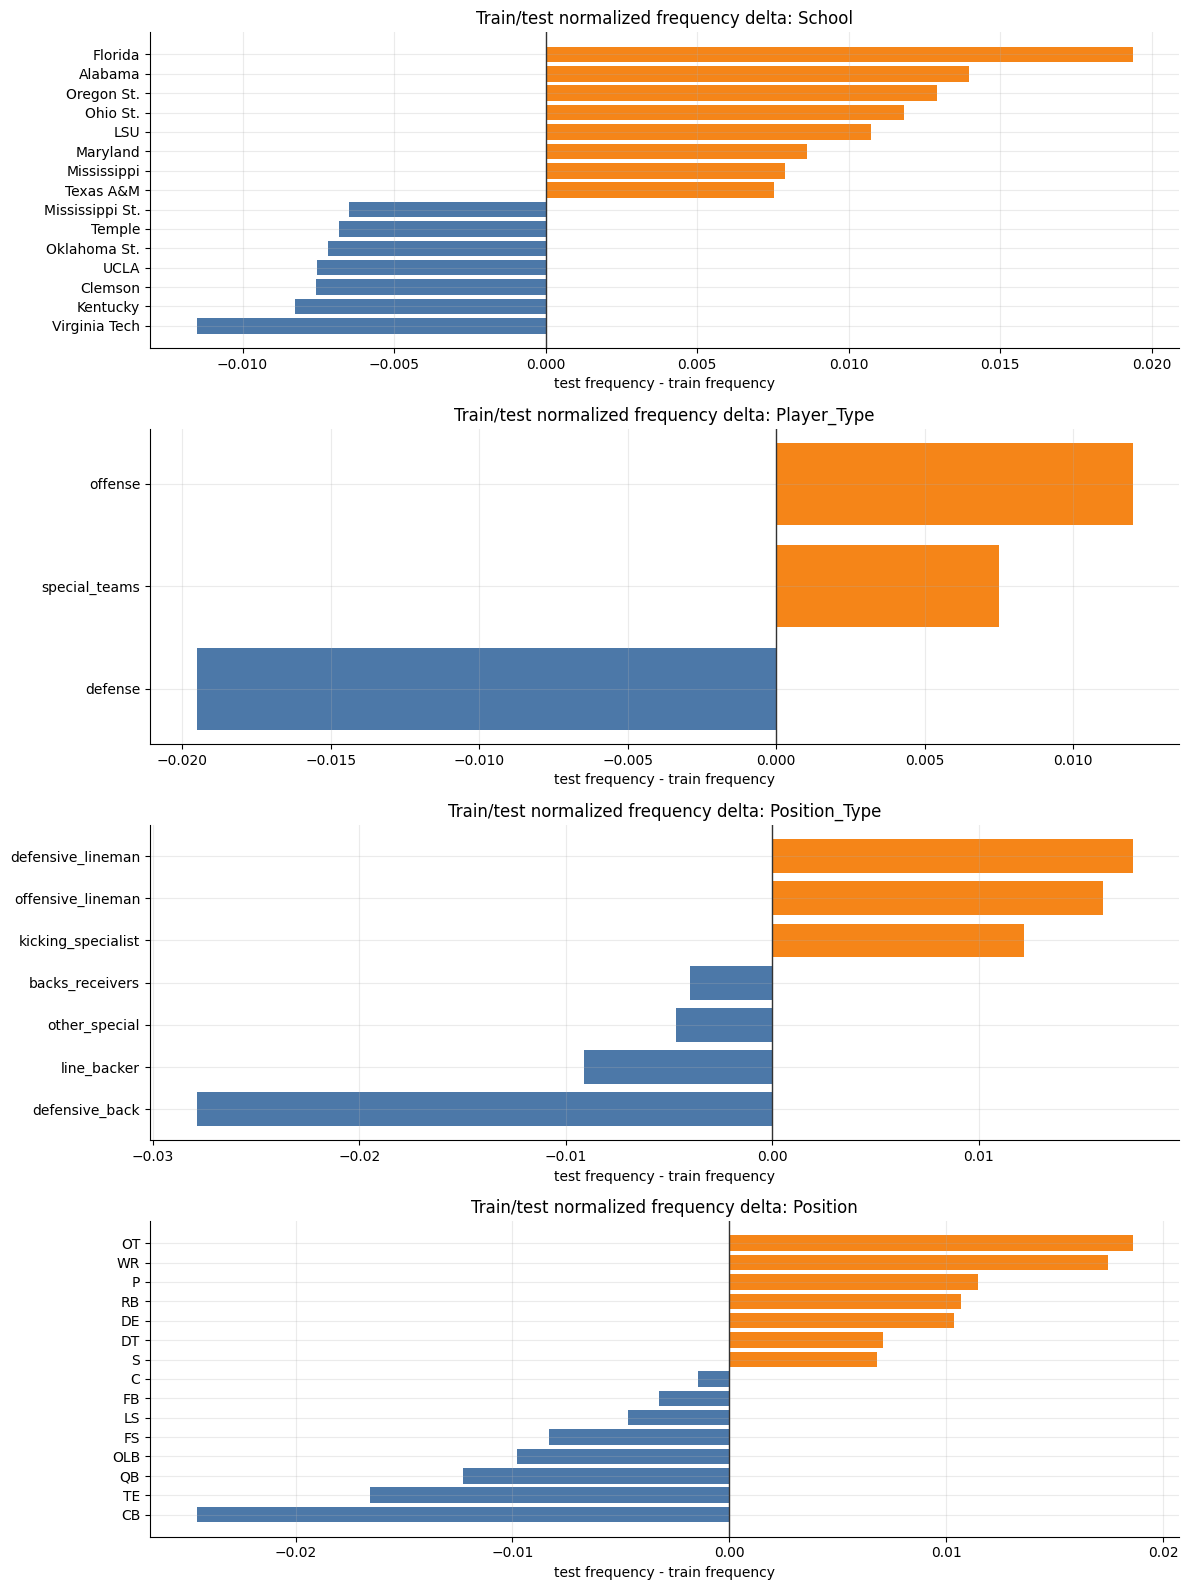

**Categorical train/test shift summary**

,column,max_abs_delta,total_variation_distance,test_only_categories
0,School,0.019377,0.243813,17
1,Player_Type,0.019518,0.019518,0
2,Position_Type,0.027868,0.045625,0
3,Position,0.024552,0.083834,0


**Numeric train/test shift diagnostics**

,column,train_missing_pct,test_missing_pct,missing_delta_test_minus_train,train_median,test_median,median_delta_test_minus_train,descriptive_max_cdf_distance
8,Agility_3cone,0.348795,0.354885,0.006090,7.130000,7.180000,0.05,0.071775
7,Broad_Jump,0.208918,0.211207,0.002289,294.640000,294.640000,0.00,0.055403
9,Shuttle,0.327940,0.327586,-0.000353,4.350000,4.380000,0.03,0.054125
4,Sprint_40yd,0.052140,0.041667,-0.010473,4.680000,4.700000,0.02,0.039613
5,Vertical_Jump,0.199209,0.205460,0.006251,83.820000,83.820000,0.00,0.034302
3,Weight,0.000000,0.000000,0.000000,104.779837,104.779837,0.00,0.034235
1,Age,0.156419,0.165230,0.008811,22.000000,22.000000,0.00,0.033401
6,Bench_Press_Reps,0.259259,0.264368,0.005109,20.000000,20.000000,0.00,0.031011
0,Year,0.000000,0.000000,0.000000,2014.000000,2014.000000,0.00,0.030803
2,Height,0.000000,0.000000,0.000000,1.879600,1.879600,0.00,0.030462


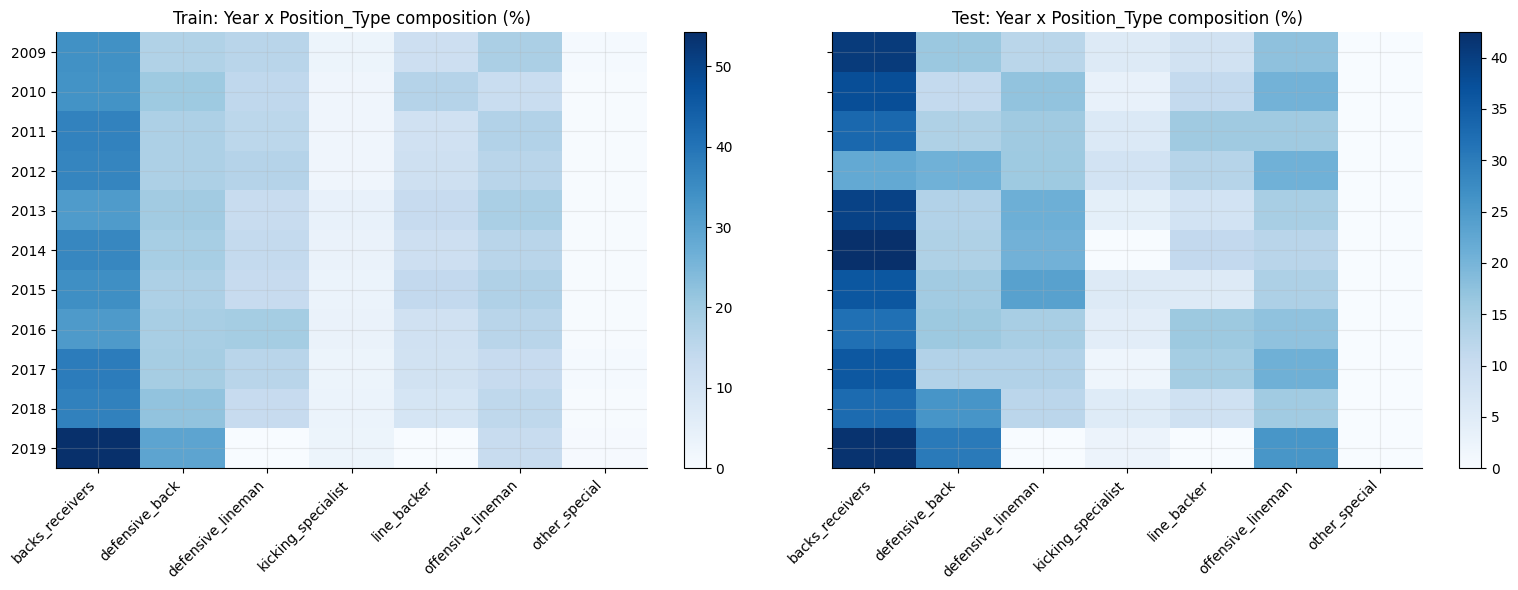

**Year distribution train/test delta**

,Year,train_freq,test_freq,delta_test_minus_train,abs_delta
0,2011,0.099964,0.073276,-0.026688,0.026688
1,2017,0.098526,0.076149,-0.022376,0.022376
6,2013,0.092053,0.109195,0.017142,0.017142
7,2009,0.090974,0.106322,0.015347,0.015347
9,2015,0.089896,0.103448,0.013553,0.013553
5,2014,0.093492,0.104885,0.011394,0.011394
8,2018,0.089896,0.083333,-0.006562,0.006562
4,2016,0.093492,0.099138,0.005646,0.005646
3,2012,0.093851,0.090517,-0.003334,0.003334
2,2010,0.094211,0.091954,-0.002257,0.002257


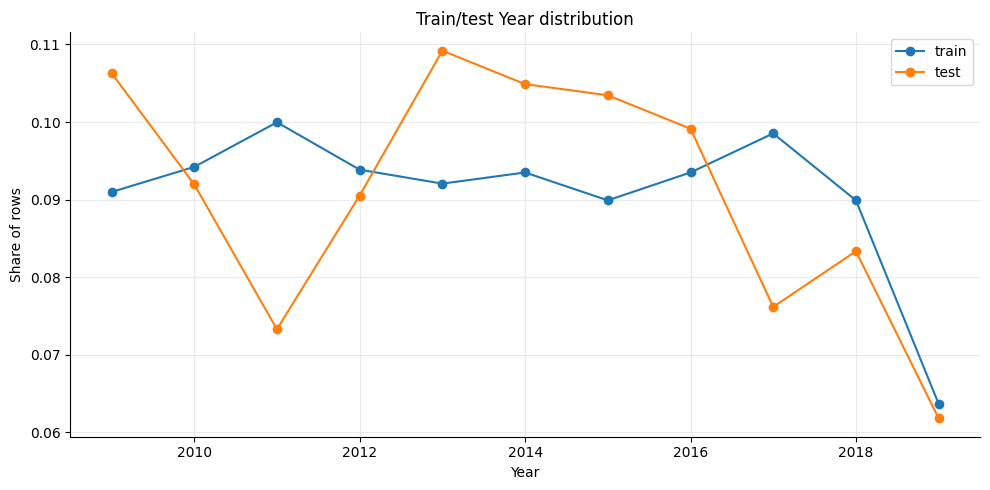


### Section conclusion - Train/test alignment and drift

**Key takeaways**
- Train/test columns and sample IDs align structurally.
- Categorical deltas and numeric diagnostics identify possible representativeness issues.
- Year and Position_Type composition can reveal drift hidden by aggregates.

**Why this matters**
- Later validation may need slice checks, not only a single mean CV score.
- Drift diagnostics support robustness planning, not test tuning.

**Leakage/validation caution**
- No transformation, feature selection, or hyperparameter choice should be made to match test distributions.
- Test data remains unlabeled.

**Hypotheses for future phases**
- Report future model performance by Year, Position_Type, and missingness profile slices.

**Deferred decisions**
- No validation split policy is finalized here.


In [11]:
fig, axes = plt.subplots(len(observed_categorical_columns), 1, figsize=(12, 4 * len(observed_categorical_columns)))
if len(observed_categorical_columns) == 1:
    axes = [axes]
category_delta_summaries = []
for ax, col in zip(axes, observed_categorical_columns):
    delta = normalized_frequency_delta(train, test, col)
    category_delta_summaries.append({"column": col, "max_abs_delta": float(delta["abs_delta"].max()), "total_variation_distance": float(0.5 * delta["abs_delta"].sum()), "test_only_categories": int((delta["train_freq"] == 0).sum())})
    top_delta = delta.head(15).sort_values("delta_test_minus_train")
    colors = np.where(top_delta["delta_test_minus_train"] >= 0, "#f58518", "#4c78a8")
    ax.barh(top_delta[col].astype(str), top_delta["delta_test_minus_train"], color=colors)
    ax.axvline(0, color="#333333", linewidth=1)
    ax.set_title(f"Train/test normalized frequency delta: {col}")
    ax.set_xlabel("test frequency - train frequency")
fig.tight_layout()
save_fig(fig, "phase03_train_test_categorical_frequency_deltas.png")
plt.show()
category_delta_df = pd.DataFrame(category_delta_summaries)
display_table("Categorical train/test shift summary", category_delta_df)
numeric_shift_rows = []
for col in [c for c in numeric_columns if c in test.columns]:
    numeric_shift_rows.append({
        "column": col,
        "train_missing_pct": train[col].isna().mean(),
        "test_missing_pct": test[col].isna().mean(),
        "missing_delta_test_minus_train": test[col].isna().mean() - train[col].isna().mean(),
        "train_median": train[col].median(),
        "test_median": test[col].median(),
        "median_delta_test_minus_train": test[col].median() - train[col].median(),
        "descriptive_max_cdf_distance": empirical_cdf_distance(train[col], test[col]),
    })
numeric_shift_df = pd.DataFrame(numeric_shift_rows).sort_values("descriptive_max_cdf_distance", ascending=False)
display_table("Numeric train/test shift diagnostics", numeric_shift_df, max_rows=80)
def year_position_composition(df):
    return pd.crosstab(df["Year"], df["Position_Type"], normalize="index").sort_index()
train_year_pos = year_position_composition(train)
test_year_pos = year_position_composition(test)
all_pos_cols = sorted(set(train_year_pos.columns) | set(test_year_pos.columns))
train_year_pos = train_year_pos.reindex(columns=all_pos_cols, fill_value=0)
test_year_pos = test_year_pos.reindex(columns=all_pos_cols, fill_value=0)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, data, label in [(axes[0], train_year_pos, "Train"), (axes[1], test_year_pos, "Test")]:
    if HAS_SEABORN:
        sns.heatmap(data * 100, ax=ax, cmap="Blues", cbar=True)
    else:
        im = ax.imshow((data * 100).to_numpy(), aspect="auto", cmap="Blues")
        ax.set_xticks(range(data.shape[1]))
        ax.set_xticklabels(data.columns, rotation=45, ha="right")
        ax.set_yticks(range(data.shape[0]))
        ax.set_yticklabels(data.index)
        fig.colorbar(im, ax=ax)
    ax.set_title(f"{label}: Year x Position_Type composition (%)")
fig.tight_layout()
save_fig(fig, "phase03_year_position_type_composition.png")
plt.show()
year_delta = normalized_frequency_delta(train, test, "Year")
display_table("Year distribution train/test delta", year_delta, max_rows=50)
fig, ax = plt.subplots(figsize=(10, 5))
year_plot = year_delta.sort_values("Year")
ax.plot(year_plot["Year"].astype(int), year_plot["train_freq"], marker="o", label="train")
ax.plot(year_plot["Year"].astype(int), year_plot["test_freq"], marker="o", label="test")
ax.set_title("Train/test Year distribution")
ax.set_xlabel("Year")
ax.set_ylabel("Share of rows")
ax.legend()
fig.tight_layout()
save_fig(fig, "phase03_train_test_year_distribution.png")
plt.show()
section_conclusion(
    "Train/test alignment and drift",
    ["Train/test columns and sample IDs align structurally.", "Categorical deltas and numeric diagnostics identify possible representativeness issues.", "Year and Position_Type composition can reveal drift hidden by aggregates."],
    ["Later validation may need slice checks, not only a single mean CV score.", "Drift diagnostics support robustness planning, not test tuning."],
    ["No transformation, feature selection, or hyperparameter choice should be made to match test distributions.", "Test data remains unlabeled."],
    ["Report future model performance by Year, Position_Type, and missingness profile slices."],
    ["No validation split policy is finalized here."],
)


**Interpretation.** Train/test numeric shift appears moderate rather than catastrophic. The larger generalization concern is structural/categorical: `School` is the main high-cardinality shift concern, and role composition can hide differences that are small globally. Drift diagnostics should guide future slice diagnostics, not test-tuned preprocessing. Later phases should check whether numeric shift remains after conditioning on `Position_Type`, `Player_Type`, and measurement completeness. Year may reflect cohort effects; future validation can combine standard StratifiedKFold with Year-slice reporting, but a temporal split is not automatically selected here.


## 13. Role-Based Deep Dive: `Position`, `Position_Type`, `Player_Type`


### 13.1 Role target rates and measurement completeness

**Objective.** Analyze role-level target rates, Wilson intervals, and measurement completeness by `Position`, `Position_Type`, and `Player_Type`.

**Why it matters.** Global performance can hide poor subgroup behavior.

**Expected output.** Tables, figures, and narrative interpretation directly below the code cell.

**Data used.** Train-only target rates; train-only descriptive role profiles.

**Leakage/validation caution.** No role interaction or role-normalized feature is created.


**Train-only target rate by Position**

,Position,n,positive_count,target_rate,wilson_low,wilson_high,uncertainty_width,low_n_warning,interpretation
11,OLB,191,145.0,0.759162,0.693795,0.814310,0.120515,False,more_stable
4,DT,200,143.0,0.715000,0.648845,0.773051,0.124206,False,more_stable
12,OT,212,150.0,0.707547,0.643054,0.764652,0.121598,False,more_stable
3,DE,191,134.0,0.701571,0.633224,0.761969,0.128745,False,more_stable
18,TE,162,113.0,0.697531,0.622897,0.763014,0.140117,False,more_stable
1,CB,328,227.0,0.692073,0.640130,0.739569,0.099439,False,more_stable
6,FS,83,57.0,0.686747,0.580584,0.776388,0.195803,False,more_stable
7,ILB,118,80.0,0.677966,0.589197,0.755513,0.166316,False,more_stable
17,SS,87,57.0,0.655172,0.550646,0.746575,0.195929,False,more_stable
10,OG,151,97.0,0.642384,0.563274,0.714429,0.151155,False,more_stable


**Train-only target rate by Position_Type**

,Position_Type,n,positive_count,target_rate,wilson_low,wilson_high,uncertainty_width,low_n_warning,interpretation
4,line_backer,309,225.0,0.728155,0.675972,0.774735,0.098763,False,more_stable
2,defensive_lineman,391,277.0,0.708440,0.661537,0.751287,0.089750,False,more_stable
1,defensive_back,541,365.0,0.674677,0.634086,0.712803,0.078717,False,more_stable
5,offensive_lineman,435,289.0,0.664368,0.618724,0.707134,0.088409,False,more_stable
0,backs_receivers,1010,622.0,0.615842,0.585459,0.645346,0.059888,False,more_stable
6,other_special,13,4.0,0.307692,0.126805,0.576311,0.449506,True,unstable_low_n
3,kicking_specialist,82,21.0,0.256098,0.174034,0.359991,0.185956,False,more_stable


**Train-only target rate by Player_Type**

,Player_Type,n,positive_count,target_rate,wilson_low,wilson_high,uncertainty_width,low_n_warning,interpretation
0,defense,1241,867.0,0.698630,0.672520,0.723515,0.050995,False,more_stable
1,offense,1445,911.0,0.630450,0.605247,0.654961,0.049714,False,more_stable
2,special_teams,95,25.0,0.263158,0.185064,0.359662,0.174598,False,more_stable


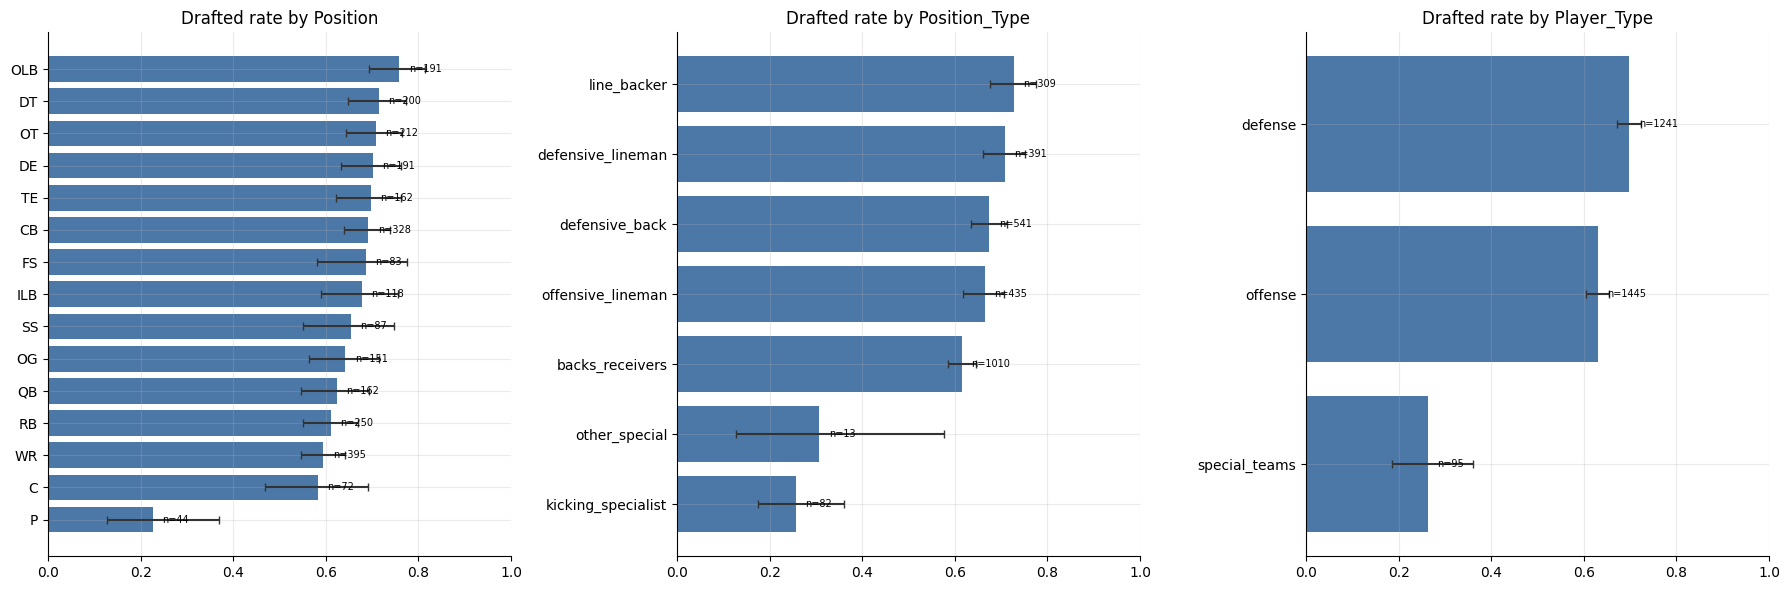

**Available measurement count by Position_Type and Player_Type**

,Position_Type,Player_Type,count,mean,median
0,backs_receivers,offense,1010,5.450495,6.0
1,defensive_back,defense,541,5.497227,6.0
2,defensive_lineman,defense,391,5.690537,7.0
3,kicking_specialist,special_teams,82,1.621951,1.0
4,line_backer,defense,309,5.640777,6.0
5,offensive_lineman,offense,435,5.793103,7.0
6,other_special,special_teams,13,3.769231,3.0


C:\Users\joui8\AppData\Local\Temp\ipykernel_39888\3702127422.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)
C:\Users\joui8\AppData\Local\Temp\ipykernel_39888\3702127422.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)
C:\Users\joui8\AppData\Local\Temp\ipykernel_39888\3702127422.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)
C:\Users\joui8\AppData\Local\Temp\ipykernel_39888\3702127422.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of box

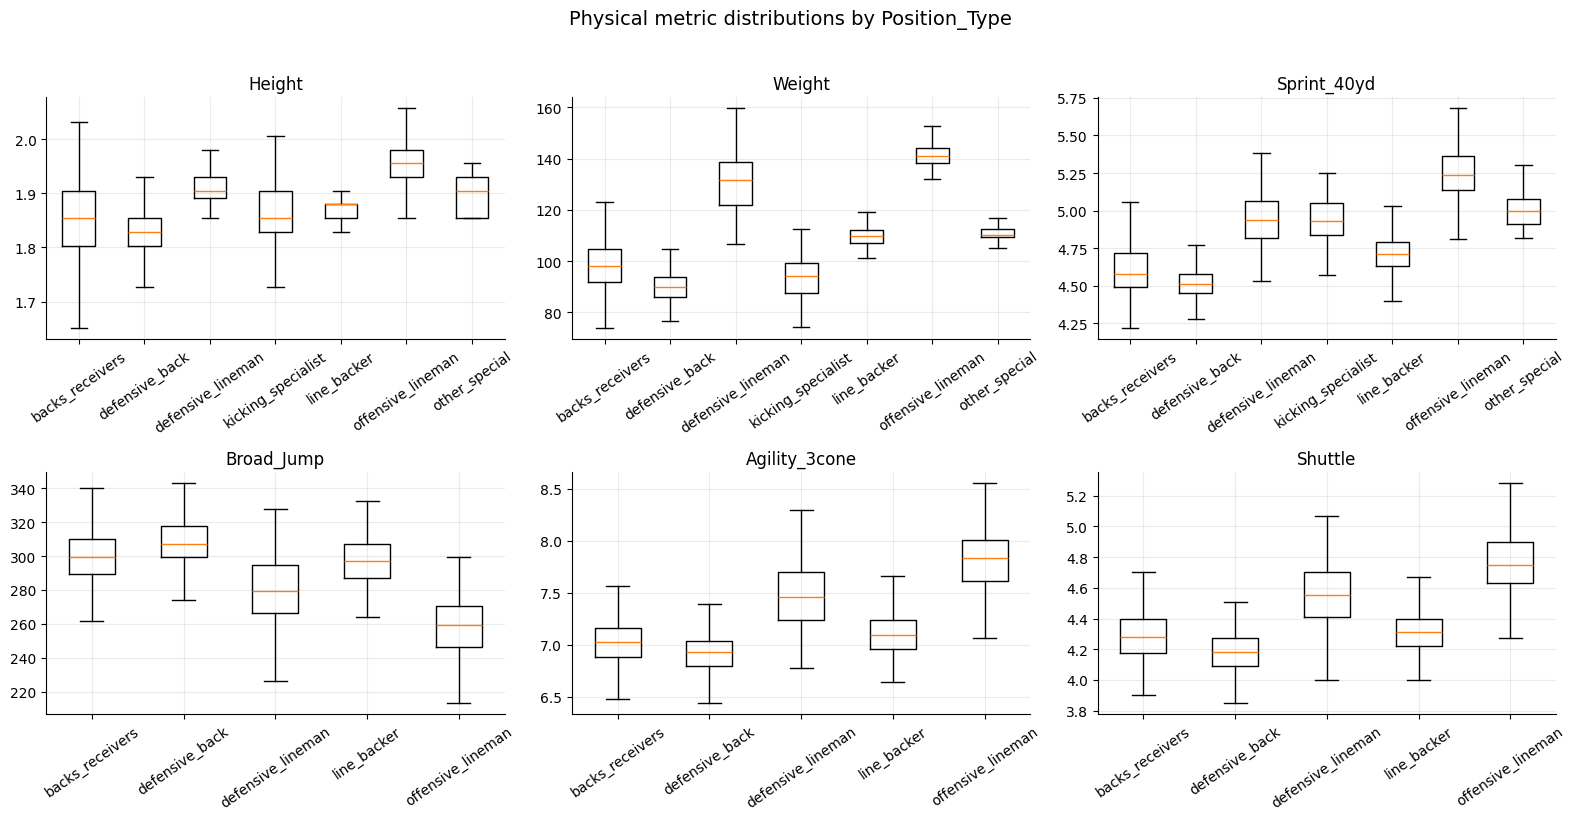


### Section conclusion - Role deep dive

**Key takeaways**
- Role fields structure counts, target rates, physical profiles, and measurement completeness.
- Wilson intervals and n labels separate high observed rates from more reliable group-level signals.

**Why this matters**
- Physical metrics likely mean different things by role.
- Later feature ideas should be validated by role slices.

**Leakage/validation caution**
- No group-based feature, interaction, or encoding is created here.
- Rare roles with extreme rates are unstable until validated.

**Hypotheses for future phases**
- Test role-specific interactions and missingness profiles in later phases.

**Deferred decisions**
- No role group is dropped, merged, or given special treatment in Phase 3.


In [12]:
role_tables = {}
for col in ["Position", "Position_Type", "Player_Type"]:
    role_tables[col] = target_rate_table(train, col, min_n_warning=20)
    display_table(f"Train-only target rate by {col}", role_tables[col], max_rows=50)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, col in zip(axes, ["Position", "Position_Type", "Player_Type"]):
    table = role_tables[col].sort_values("n", ascending=False).head(15).sort_values("target_rate")
    y = np.arange(len(table))
    ax.barh(y, table["target_rate"], color="#4c78a8")
    lower_err = np.maximum((table["target_rate"] - table["wilson_low"]).to_numpy(dtype=float), 0)
    upper_err = np.maximum((table["wilson_high"] - table["target_rate"]).to_numpy(dtype=float), 0)
    ax.errorbar(table["target_rate"].to_numpy(dtype=float), y, xerr=[lower_err, upper_err], fmt="none", ecolor="#333333", capsize=3)
    ax.set_yticks(y)
    ax.set_yticklabels(table[col].astype(str))
    ax.set_xlim(0, 1)
    ax.set_title(f"Drafted rate by {col}")
    for yi, (_, row) in zip(y, table.iterrows()):
        ax.text(min(0.98, row["target_rate"] + 0.02), yi, f"n={int(row['n'])}", va="center", fontsize=7)
fig.tight_layout()
save_fig(fig, "phase03_role_target_rates_with_uncertainty.png")
plt.show()
role_missing_summary = train_analysis.groupby(["Position_Type", "Player_Type"])["available_measurement_count"].agg(["count", "mean", "median"]).reset_index()
display_table("Available measurement count by Position_Type and Player_Type", role_missing_summary, max_rows=50)
selected_role_metrics = [c for c in ["Height", "Weight", "Sprint_40yd", "Broad_Jump", "Agility_3cone", "Shuttle"] if c in train.columns]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, selected_role_metrics):
    groups = []
    labels = []
    for group, group_df in train.groupby("Position_Type"):
        values = group_df[col].dropna()
        if len(values) >= 10:
            groups.append(values)
            labels.append(str(group))
    ax.boxplot(groups, labels=labels, showfliers=False)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=35)
for ax in axes[len(selected_role_metrics):]:
    ax.axis("off")
fig.suptitle("Physical metric distributions by Position_Type", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()
section_conclusion(
    "Role deep dive",
    ["Role fields structure counts, target rates, physical profiles, and measurement completeness.", "Wilson intervals and n labels separate high observed rates from more reliable group-level signals."],
    ["Physical metrics likely mean different things by role.", "Later feature ideas should be validated by role slices."],
    ["No group-based feature, interaction, or encoding is created here.", "Rare roles with extreme rates are unstable until validated."],
    ["Test role-specific interactions and missingness profiles in later phases."],
    ["No role group is dropped, merged, or given special treatment in Phase 3."],
)


**Interpretation.** The descriptive chain `Player_Type -> measurement completeness -> Drafted` should be treated as a possible confounding pattern, not causality. `special_teams` appears structurally different from offense and defense, with lower measurement completeness and lower target rate. This may partly explain missingness effects. Future validation should report model performance by `Player_Type`; global AUC may hide weak subgroup behavior. Later ablations should test whether missingness and available-measurement-count signals remain useful inside offense, defense, and special_teams separately.


## 14. Physical-Performance Relationships


### 14.1 Faceted physical relationship plots by Position_Type

**Objective.** Inspect selected physical relationships such as height vs weight, weight vs sprint, sprint vs jump metrics, and agility vs shuttle.

**Why it matters.** A relationship can look weak or misleading globally but matter within role groups.

**Expected output.** Tables, figures, and narrative interpretation directly below the code cell.

**Data used.** Train only, with target coloring for descriptive interpretation.

**Leakage/validation caution.** No interaction, ratio, or nonlinear transform is created.


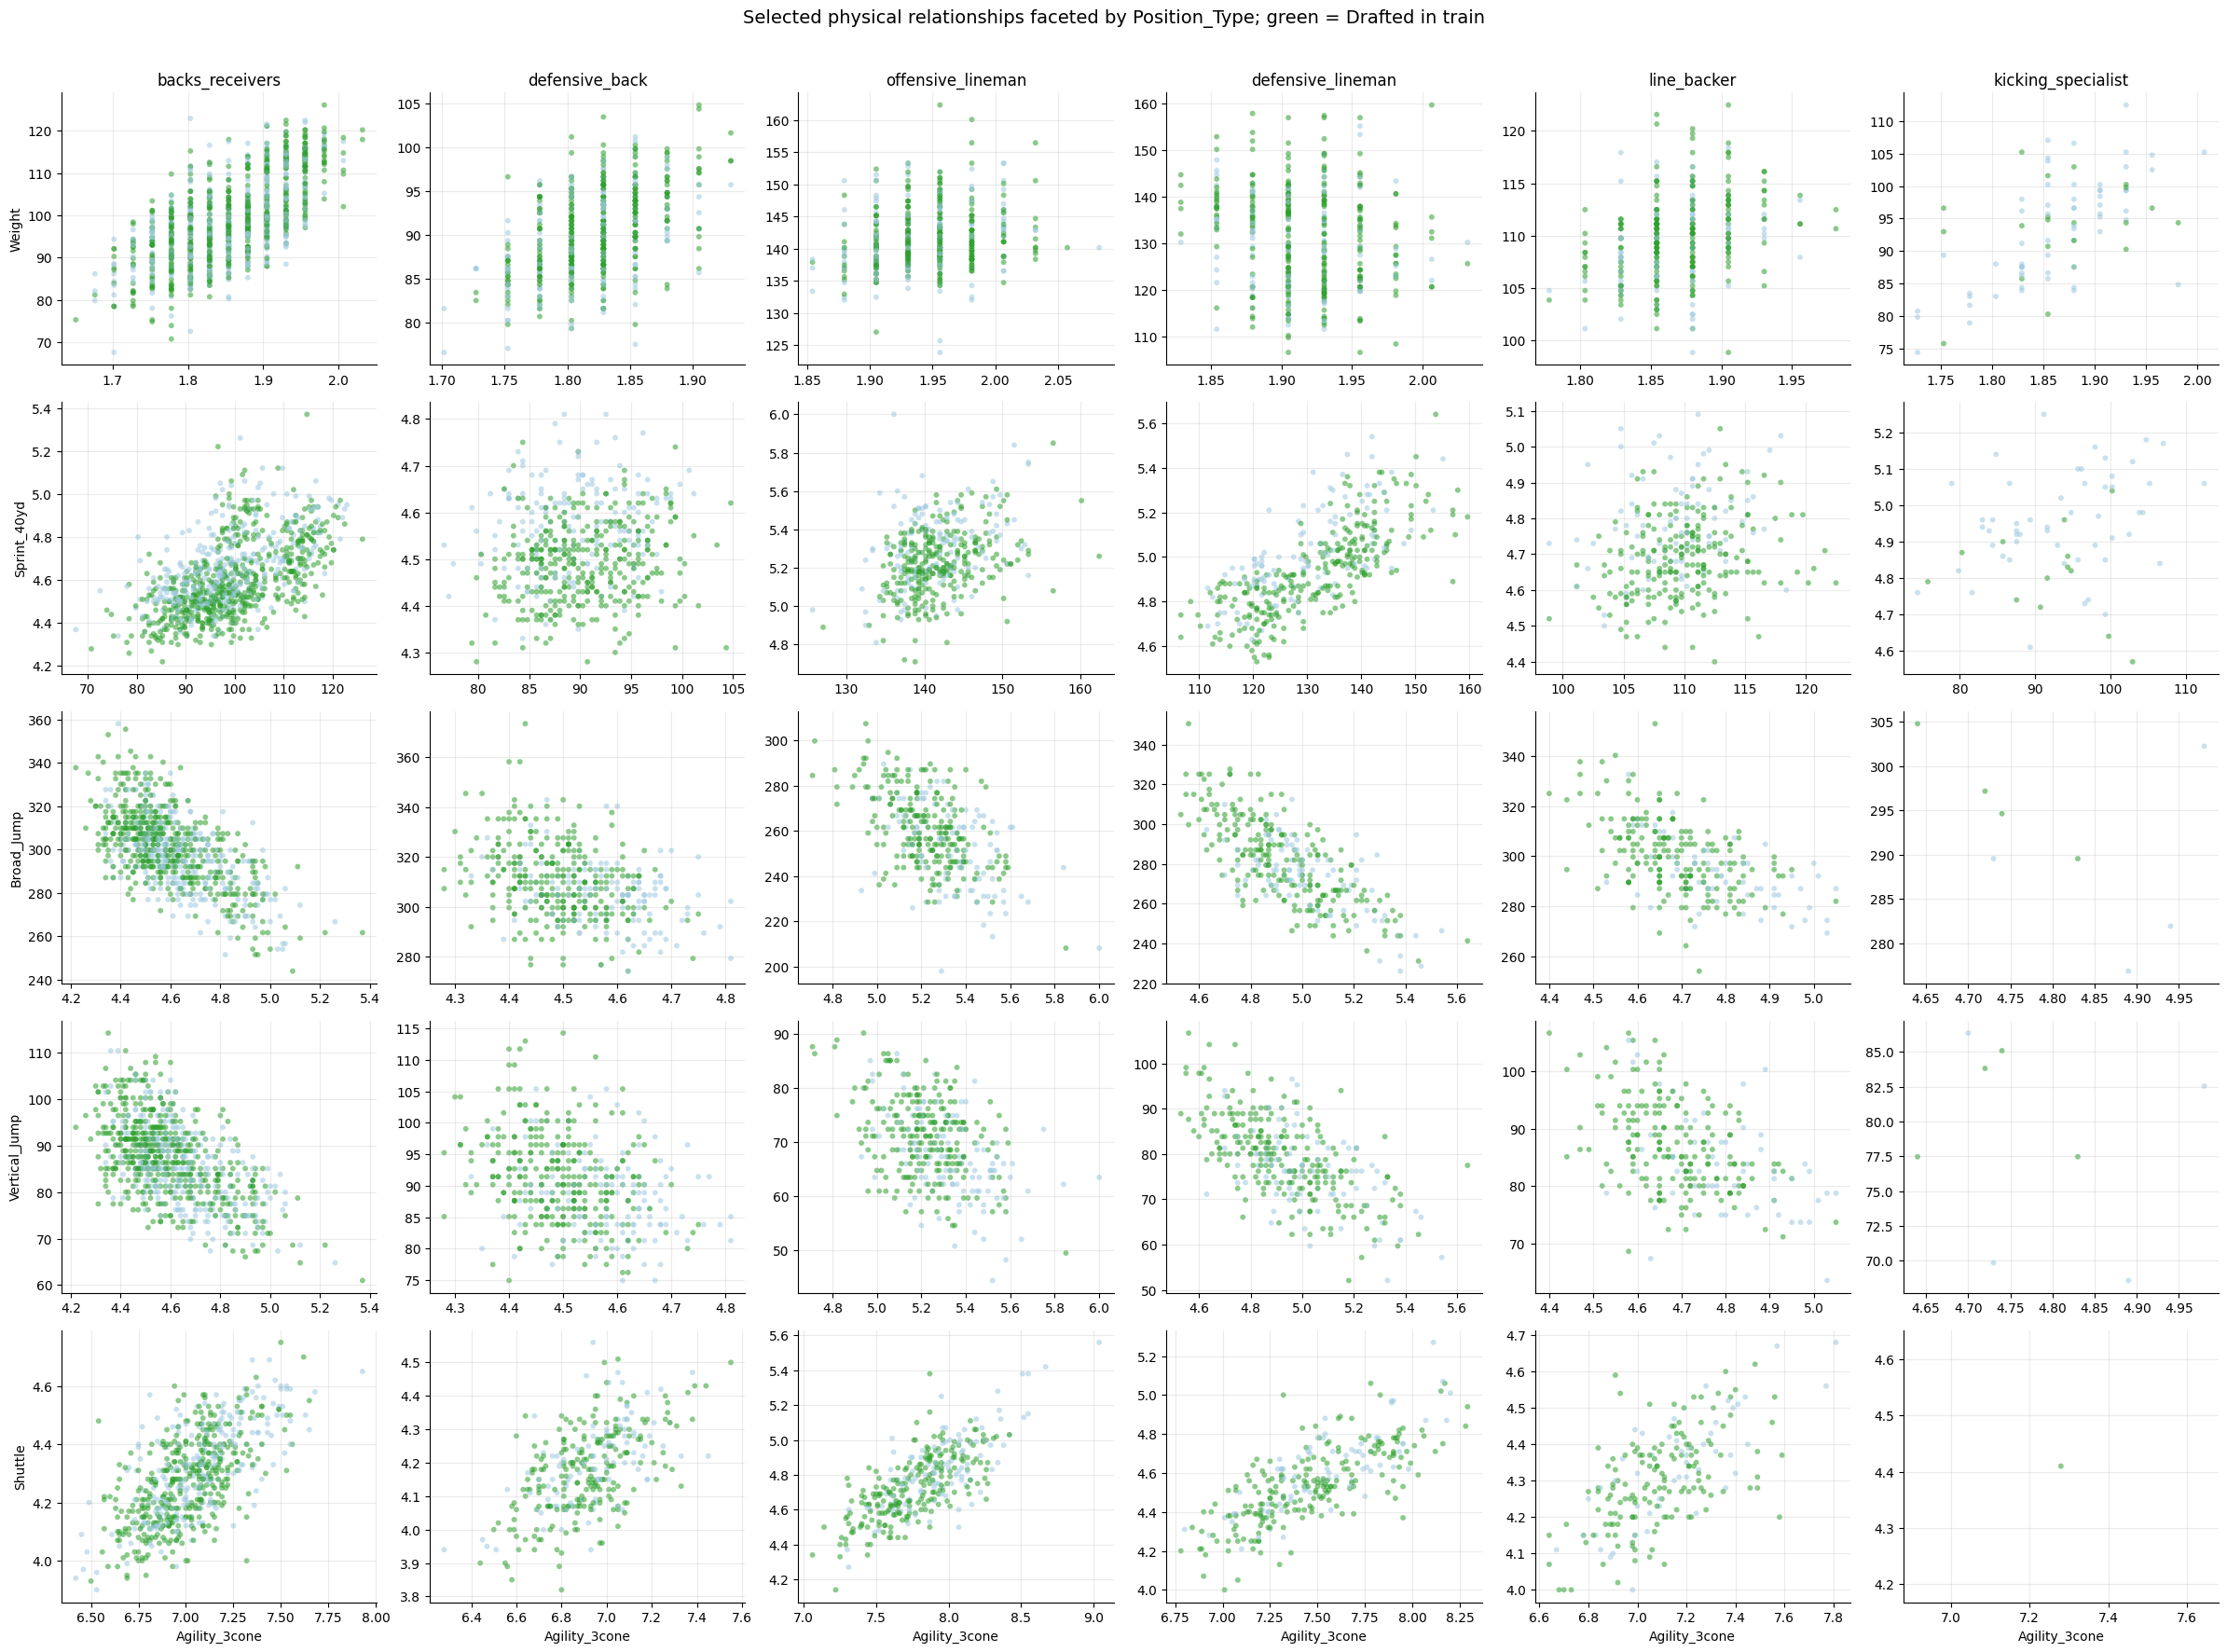

**Global vs within-Position_Type physical relationship correlations**

,x,y,Position_Type,global_spearman,within_position_type_spearman,direction_changed,n
2,Height,Weight,defensive_lineman,0.746451,-0.156318,True,391
0,Height,Weight,backs_receivers,0.746451,0.645745,False,1010
14,Sprint_40yd,Broad_Jump,defensive_lineman,-0.780769,-0.721306,False,309
25,Agility_3cone,Shuttle,line_backer,0.847270,0.605689,False,196
24,Agility_3cone,Shuttle,defensive_lineman,0.847270,0.755719,False,283
23,Agility_3cone,Shuttle,defensive_back,0.847270,0.550750,False,325
22,Agility_3cone,Shuttle,backs_receivers,0.847270,0.639680,False,649
21,Sprint_40yd,Vertical_Jump,offensive_lineman,-0.731244,-0.411585,False,348
20,Sprint_40yd,Vertical_Jump,line_backer,-0.731244,-0.455331,False,244
19,Sprint_40yd,Vertical_Jump,defensive_lineman,-0.731244,-0.611908,False,317



### Section conclusion - Physical-performance relationships

**Key takeaways**
- Selected body-size and performance relationships vary across Position_Type groups.
- Faceted plots reveal role-specific patterns hidden by global scatter plots.

**Why this matters**
- Later interactions should be motivated by role-specific evidence, not only global correlations.

**Leakage/validation caution**
- Scatter plots are descriptive and train-target coloring is train-only.
- No relationship is selected as a final feature here.

**Hypotheses for future phases**
- Test whether role-specific interactions improve fold-level AUC later.
- Check for Simpson-style aggregate traps.

**Deferred decisions**
- No interaction, ratio, or nonlinear transform is created in Phase 3.


In [13]:
relationship_pairs = [(x, y) for x, y in [("Height", "Weight"), ("Weight", "Sprint_40yd"), ("Sprint_40yd", "Broad_Jump"), ("Sprint_40yd", "Vertical_Jump"), ("Agility_3cone", "Shuttle")] if x in train.columns and y in train.columns]
position_types = train["Position_Type"].value_counts().head(6).index.tolist()
fig, axes = plt.subplots(len(relationship_pairs), len(position_types), figsize=(4 * len(position_types), 3.5 * len(relationship_pairs)))
if len(relationship_pairs) == 1:
    axes = np.array([axes])
if len(position_types) == 1:
    axes = axes.reshape(len(relationship_pairs), 1)
for row_idx, (x_col, y_col) in enumerate(relationship_pairs):
    for col_idx, pos_type in enumerate(position_types):
        ax = axes[row_idx, col_idx]
        subset = train[train["Position_Type"] == pos_type]
        colors = np.where(subset[TARGET_COLUMN] == 1, "#2ca02c", "#9ecae1")
        ax.scatter(subset[x_col], subset[y_col], c=colors, alpha=0.55, s=18, edgecolors="none")
        if row_idx == 0:
            ax.set_title(str(pos_type))
        if col_idx == 0:
            ax.set_ylabel(y_col)
        if row_idx == len(relationship_pairs) - 1:
            ax.set_xlabel(x_col)
fig.suptitle("Selected physical relationships faceted by Position_Type; green = Drafted in train", y=1.01, fontsize=14)
fig.tight_layout()
save_fig(fig, "phase03_physical_relationships_by_position_type.png")
plt.show()
relationship_rows = []
for x_col, y_col in relationship_pairs:
    global_corr = train[[x_col, y_col]].corr(method="spearman").iloc[0, 1]
    for pos_type, group_df in train.groupby("Position_Type"):
        if group_df[[x_col, y_col]].dropna().shape[0] < 20:
            continue
        within_corr = group_df[[x_col, y_col]].corr(method="spearman").iloc[0, 1]
        relationship_rows.append({"x": x_col, "y": y_col, "Position_Type": pos_type, "global_spearman": global_corr, "within_position_type_spearman": within_corr, "direction_changed": np.sign(global_corr) != np.sign(within_corr) if pd.notna(global_corr) and pd.notna(within_corr) else False, "n": int(group_df[[x_col, y_col]].dropna().shape[0])})
relationship_corr_df = pd.DataFrame(relationship_rows).sort_values("direction_changed", ascending=False)
display_table("Global vs within-Position_Type physical relationship correlations", relationship_corr_df, max_rows=80)
section_conclusion(
    "Physical-performance relationships",
    ["Selected body-size and performance relationships vary across Position_Type groups.", "Faceted plots reveal role-specific patterns hidden by global scatter plots."],
    ["Later interactions should be motivated by role-specific evidence, not only global correlations."],
    ["Scatter plots are descriptive and train-target coloring is train-only.", "No relationship is selected as a final feature here."],
    ["Test whether role-specific interactions improve fold-level AUC later.", "Check for Simpson-style aggregate traps."],
    ["No interaction, ratio, or nonlinear transform is created in Phase 3."],
)


**Interpretation.** Physical relationships should be inspected within `Position_Type`, not only globally. `Position_Type` should be a central axis for later tests of raw metrics, role interactions, role-normalized metrics, and within-role percentiles or ranks. Role-normalized features require fold-safe computation if their statistics are learned from training data. They are hypotheses for later phases, not selected transformations in Phase 3.


## 15. Correlation and Redundancy Analysis


### 15.1 Pearson and Spearman correlation heatmaps

**Objective.** Compute Pearson and Spearman heatmaps and a high-correlation pair table.

**Why it matters.** Correlations can reveal latent physical dimensions and redundancy.

**Expected output.** Tables, figures, and narrative interpretation directly below the code cell.

**Data used.** Train numeric columns only.

**Leakage/validation caution.** High correlation is not a reason to drop features in Phase 3.


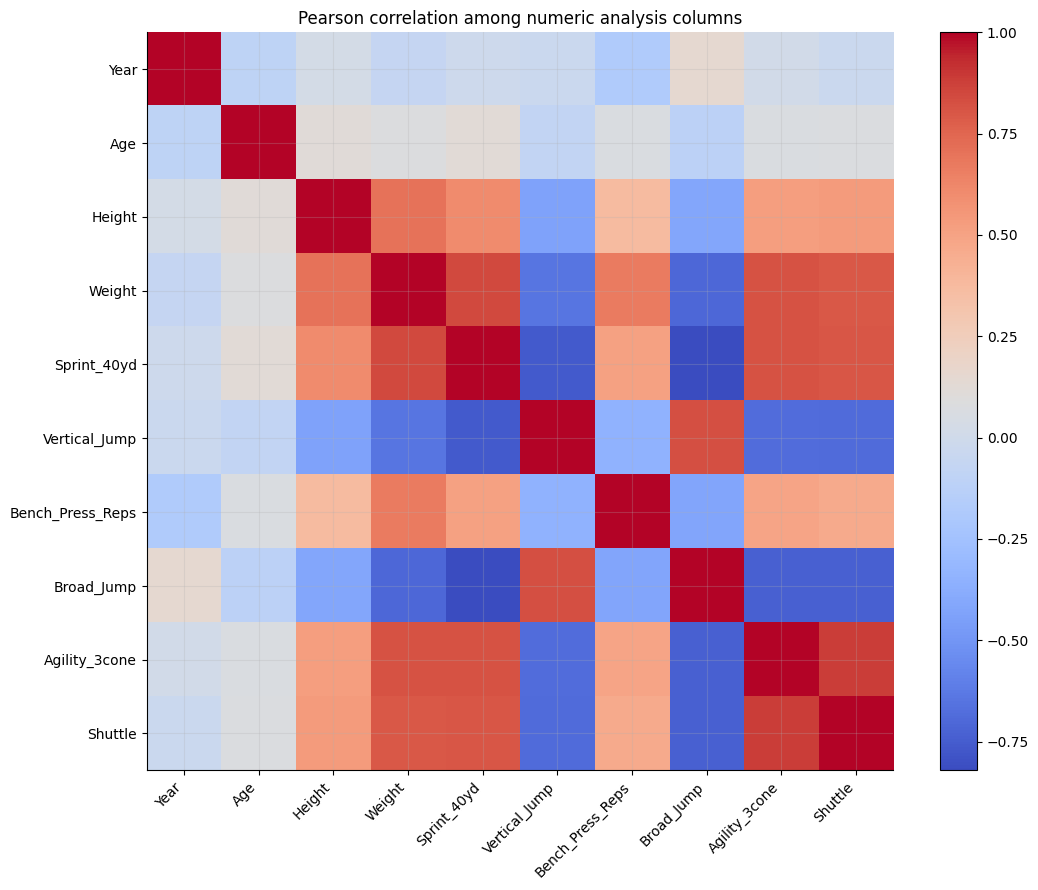

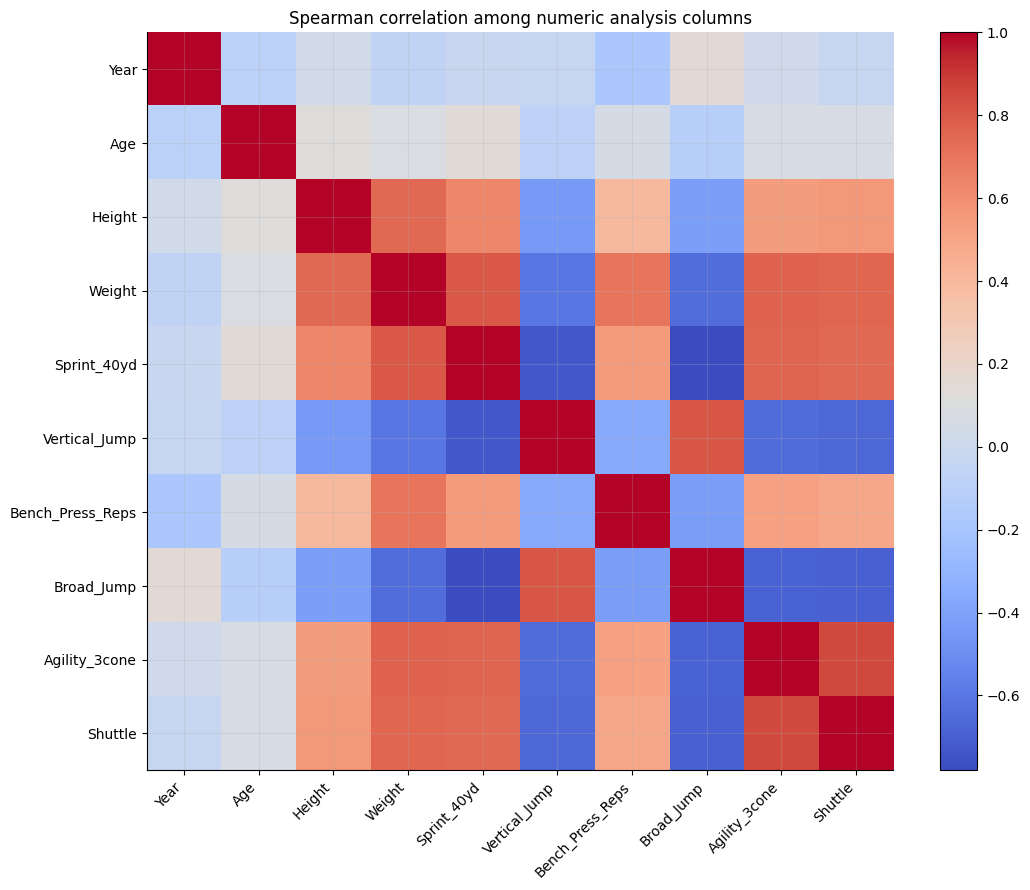

**High-correlation pair table with interpretation**

,feature_a,feature_b,correlation,abs_correlation,interpretation,method
0,Agility_3cone,Shuttle,0.879571,0.879571,possible redundancy or shared physical profile...,pearson
1,Weight,Sprint_40yd,0.844383,0.844383,possible redundancy or shared physical profile...,pearson
2,Vertical_Jump,Broad_Jump,0.828637,0.828637,possible redundancy or shared physical profile...,pearson
3,Sprint_40yd,Broad_Jump,-0.820895,0.820895,possible redundancy or shared physical profile...,pearson
4,Weight,Agility_3cone,0.817706,0.817706,possible redundancy or shared physical profile...,pearson
5,Sprint_40yd,Agility_3cone,0.816042,0.816042,possible redundancy or shared physical profile...,pearson
6,Sprint_40yd,Shuttle,0.801723,0.801723,possible redundancy or shared physical profile...,pearson
7,Weight,Shuttle,0.796042,0.796042,possible redundancy or shared physical profile...,pearson
8,Sprint_40yd,Vertical_Jump,-0.757027,0.757027,possible redundancy or shared physical profile...,pearson
9,Broad_Jump,Shuttle,-0.729444,0.729444,possible redundancy or shared physical profile...,pearson



### Section conclusion - Correlation and redundancy

**Key takeaways**
- Pearson and Spearman heatmaps show linear and monotonic relationships.
- High-correlation method-specific rows at abs(corr) >= 0.60: 36.

**Why this matters**
- Redundant physical tests may affect stability, but correlation is not feature selection.

**Leakage/validation caution**
- No correlated variable is dropped in Phase 3.
- Feature selection must happen inside validation if introduced later.

**Hypotheses for future phases**
- Test whether correlated metrics are complementary for tree models but redundant for linear models.

**Deferred decisions**
- No redundancy-based pruning is selected here.


In [14]:
corr_cols = [col for col in numeric_columns if col in train.columns]
pearson_corr = train[corr_cols].corr(method="pearson")
spearman_corr = train[corr_cols].corr(method="spearman")
fig, ax = heatmap_plot(pearson_corr, "Pearson correlation among numeric analysis columns", cmap="coolwarm", center=0, figsize=(11, 9))
save_fig(fig, "phase03_numeric_correlations_pearson.png")
plt.show()
fig, ax = heatmap_plot(spearman_corr, "Spearman correlation among numeric analysis columns", cmap="coolwarm", center=0, figsize=(11, 9))
save_fig(fig, "phase03_numeric_correlations_spearman.png")
plt.show()
pearson_pairs = high_correlation_pairs(pearson_corr, threshold=0.60)
spearman_pairs = high_correlation_pairs(spearman_corr, threshold=0.60)
pearson_pairs["method"] = "pearson"
spearman_pairs["method"] = "spearman"
high_corr_table = pd.concat([pearson_pairs, spearman_pairs], ignore_index=True)
display_table("High-correlation pair table with interpretation", high_corr_table.sort_values(["method", "abs_correlation"], ascending=[True, False]), max_rows=80)
section_conclusion(
    "Correlation and redundancy",
    ["Pearson and Spearman heatmaps show linear and monotonic relationships.", f"High-correlation method-specific rows at abs(corr) >= 0.60: {len(high_corr_table)}."],
    ["Redundant physical tests may affect stability, but correlation is not feature selection."],
    ["No correlated variable is dropped in Phase 3.", "Feature selection must happen inside validation if introduced later."],
    ["Test whether correlated metrics are complementary for tree models but redundant for linear models."],
    ["No redundancy-based pruning is selected here."],
)


**Interpretation.** Several physical tests are correlated, suggesting latent dimensions such as size, speed, explosiveness, agility, and strength. Examples to inspect later include agility/shuttle, vertical/broad jump, and weight/sprint relationships. High correlation is not a reason to drop features in Phase 3: linear models may need regularization or careful preprocessing, while tree models may use correlated variables as alternative split candidates. Any pruning or dimensionality reduction must be tested inside validation.


## 16. Contrarian and Overlooked Pattern Mining


### 16.1 Search for patterns hidden by global summaries

**Objective.** Search for Simpson-style reversals, variables weak globally but informative within roles, missingness-vs-value signal, cohort availability shifts, hidden composition shift, and role-contextual outliers.

**Why it matters.** Competitors often miss patterns that only appear after grouping by role, year, or measurement profile.

**Expected output.** Tables, figures, and narrative interpretation directly below the code cell.

**Data used.** Train-only for target-aware scans; train/test descriptive for cohort availability.

**Leakage/validation caution.** All findings are hypotheses only.


**Contrarian and overlooked pattern scan**

,pattern_type,variable,global_delta_drafted_minus_not_median,max_abs_within_position_type_delta,opposite_direction_groups,hypothesis
0,global_vs_within_role_direction,Height,0.000000,0.025400,"line_backer (-0.025, n=309); offensive_lineman...",Metric direction may depend on role; global as...
1,global_vs_within_role_direction,Weight,4.989516,3.628739,none_detected,Metric direction may depend on role; global as...
2,global_vs_within_role_direction,Sprint_40yd,-0.080000,0.125000,none_detected,Metric direction may depend on role; global as...
3,global_vs_within_role_direction,Vertical_Jump,2.540000,4.445000,none_detected,Metric direction may depend on role; global as...
4,global_vs_within_role_direction,Bench_Press_Reps,1.000000,2.000000,none_detected,Metric direction may depend on role; global as...
5,global_vs_within_role_direction,Broad_Jump,5.080000,7.620000,none_detected,Metric direction may depend on role; global as...
6,global_vs_within_role_direction,Agility_3cone,-0.050000,0.190000,none_detected,Metric direction may depend on role; global as...
7,global_vs_within_role_direction,Shuttle,-0.040000,0.115000,none_detected,Metric direction may depend on role; global as...
8,missingness_vs_measured_value,Age,NaN,NaN,not_applicable,Missingness target-rate spread=0.747; median-s...
9,missingness_vs_measured_value,Sprint_40yd,NaN,NaN,not_applicable,Missingness target-rate spread=0.066; median-s...


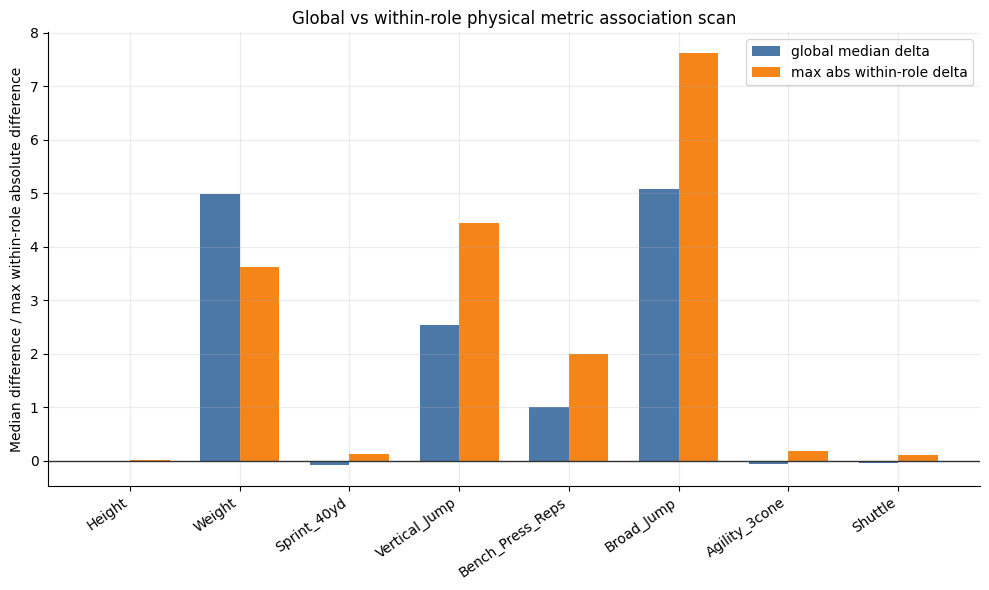

**Cohort/year changes in measurement availability**

,Year,train_mean_available,train_n,test_mean_available,test_n,test_minus_train_mean_available
0,2009,5.517787,253,5.472973,74,-0.044814
1,2010,5.465649,262,5.265625,64,-0.200024
2,2011,5.953237,278,5.509804,51,-0.443433
3,2012,5.601533,261,5.476190,63,-0.125342
4,2013,5.406250,256,5.407895,76,0.001645
5,2014,5.476923,260,5.835616,73,0.358693
6,2015,5.476000,250,5.305556,72,-0.170444
7,2016,5.530769,260,5.405797,69,-0.124972
8,2017,5.357664,274,5.754717,53,0.397053
9,2018,4.932000,250,4.758621,58,-0.173379


**Role-contextual suspicious physical values summary**

,scope,group,column,n,lower_fence,upper_fence,outlier_count,outlier_rate
132,within_position,FB,Shuttle,28,4.125000,4.645000,3,0.107143
1,within_position,C,Height,72,1.866900,1.968500,7,0.097222
12,within_position,OT,Height,212,1.917700,2.019300,19,0.089623
124,within_position,SS,Agility_3cone,53,6.505000,7.345000,4,0.075472
115,within_position,FB,Agility_3cone,27,6.772500,7.672500,2,0.074074
48,within_position,K,Sprint_40yd,28,4.591250,5.181250,2,0.071429
140,within_position,S,Shuttle,16,3.865000,4.545000,1,0.062500
24,within_position,DT,Weight,200,124.284309,153.314221,11,0.055000
105,within_position,RB,Broad_Jump,206,269.240000,330.200000,11,0.053398
128,within_position,C,Shuttle,58,4.360000,5.000000,3,0.051724



### Section conclusion - Contrarian and overlooked pattern mining

**Key takeaways**
- The scan checks global-vs-role reversals, missingness-vs-value signal, cohort availability shifts, hidden composition shift, and role-contextual outliers.
- Several patterns only appear after grouping by role or year.

**Why this matters**
- These checks prevent later phases from over-trusting global relationships, raw target rates, or aggregate drift plots.

**Leakage/validation caution**
- All target-aware scans are train-only and descriptive.
- No pattern is promoted to a modeling rule.

**Hypotheses for future phases**
- Prioritize fold-safe tests for role-specific interactions, missingness signals, and measurement-completeness features.

**Deferred decisions**
- No contrarian pattern becomes a final feature in Phase 3.


In [15]:
contrarian_rows = []
for metric in analysis_physical_columns:
    non_missing = train[[metric, TARGET_COLUMN, "Position_Type"]].dropna()
    if non_missing[TARGET_COLUMN].nunique() < 2:
        continue
    global_delta = non_missing.loc[non_missing[TARGET_COLUMN] == 1, metric].median() - non_missing.loc[non_missing[TARGET_COLUMN] == 0, metric].median()
    group_deltas = []
    for group, group_df in non_missing.groupby("Position_Type"):
        if group_df[TARGET_COLUMN].nunique() < 2 or len(group_df) < 30:
            continue
        delta = group_df.loc[group_df[TARGET_COLUMN] == 1, metric].median() - group_df.loc[group_df[TARGET_COLUMN] == 0, metric].median()
        group_deltas.append((group, delta, len(group_df)))
    opposite = [(g, d, n) for g, d, n in group_deltas if np.sign(d) != np.sign(global_delta) and abs(d) > 0]
    contrarian_rows.append({"pattern_type": "global_vs_within_role_direction", "variable": metric, "global_delta_drafted_minus_not_median": global_delta, "max_abs_within_position_type_delta": max([abs(d) for _, d, _ in group_deltas], default=np.nan), "opposite_direction_groups": "; ".join([f"{g} ({d:.3f}, n={n})" for g, d, n in opposite]) if opposite else "none_detected", "hypothesis": "Metric direction may depend on role; global association can be misleading."})
for metric in analysis_missingness_columns:
    temp = train[[metric, TARGET_COLUMN]].copy()
    missing_rate = temp.groupby(temp[metric].isna())[TARGET_COLUMN].mean()
    missing_spread = missing_rate.max() - missing_rate.min() if len(missing_rate) == 2 else np.nan
    observed = temp[temp[metric].notna()].copy()
    if len(observed) >= 30 and observed[metric].nunique() > 1:
        median_value = observed[metric].median()
        observed["median_side"] = np.where(observed[metric] >= median_value, "high", "low")
        value_rate = observed.groupby("median_side")[TARGET_COLUMN].mean()
        value_spread = value_rate.max() - value_rate.min() if len(value_rate) == 2 else np.nan
    else:
        value_spread = np.nan
    contrarian_rows.append({"pattern_type": "missingness_vs_measured_value", "variable": metric, "global_delta_drafted_minus_not_median": np.nan, "max_abs_within_position_type_delta": np.nan, "opposite_direction_groups": "not_applicable", "hypothesis": f"Missingness target-rate spread={missing_spread:.3f}; median-split value spread={value_spread:.3f}. Missingness may matter as much as value." if pd.notna(value_spread) else "Missingness may matter, but measured-value comparison was not available."})
contrarian_df = pd.DataFrame(contrarian_rows)
display_table("Contrarian and overlooked pattern scan", contrarian_df, max_rows=100)
direction_df = contrarian_df[contrarian_df["pattern_type"] == "global_vs_within_role_direction"].copy()
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(direction_df))
ax.bar(x - 0.18, direction_df["global_delta_drafted_minus_not_median"], width=0.36, label="global median delta", color="#4c78a8")
ax.bar(x + 0.18, direction_df["max_abs_within_position_type_delta"], width=0.36, label="max abs within-role delta", color="#f58518")
ax.axhline(0, color="#333333", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(direction_df["variable"], rotation=35, ha="right")
ax.set_title("Global vs within-role physical metric association scan")
ax.set_ylabel("Median difference / max within-role absolute difference")
ax.legend()
fig.tight_layout()
save_fig(fig, "phase03_contrarian_global_vs_within_role_associations.png")
plt.show()
year_availability = pd.concat([
    train_analysis.groupby("Year")["available_measurement_count"].agg(train_mean_available="mean", train_n="count"),
    test_analysis.groupby("Year")["available_measurement_count"].agg(test_mean_available="mean", test_n="count"),
], axis=1)
year_availability["test_minus_train_mean_available"] = year_availability["test_mean_available"] - year_availability["train_mean_available"]
display_table("Cohort/year changes in measurement availability", year_availability.reset_index(), max_rows=50)
suspicious_role_metrics = outlier_df[(outlier_df["scope"] == "within_position") & (outlier_df["outlier_count"] > 0)].sort_values("outlier_rate", ascending=False).head(20)
display_table("Role-contextual suspicious physical values summary", suspicious_role_metrics, max_rows=20)
section_conclusion(
    "Contrarian and overlooked pattern mining",
    ["The scan checks global-vs-role reversals, missingness-vs-value signal, cohort availability shifts, hidden composition shift, and role-contextual outliers.", "Several patterns only appear after grouping by role or year."],
    ["These checks prevent later phases from over-trusting global relationships, raw target rates, or aggregate drift plots."],
    ["All target-aware scans are train-only and descriptive.", "No pattern is promoted to a modeling rule."],
    ["Prioritize fold-safe tests for role-specific interactions, missingness signals, and measurement-completeness features."],
    ["No contrarian pattern becomes a final feature in Phase 3."],
)


**Interpretation.** Global associations can be misleading. A variable can look weak globally but be useful inside role groups; `Height` shows evidence of direction changing across role groups. The future check is not only opposite direction, but also small global effect with large within-role effect, and role-specific sign or magnitude differences. This supports either models capable of interactions or explicit role-aware feature engineering. Future phases should systematically scan variables with low global association but high within-role association. These patterns are hypotheses only.


## 17. Leakage and Validation Risk Register


### 17.1 Phase 3 leakage and validation risks

**Objective.** Document risks with severity, likelihood, evidence, safeguards, and future owner/phase.

**Why it matters.** Explicit risks make later modeling decisions auditable.

**Expected output.** Tables, figures, and narrative interpretation directly below the code cell.

**Data used.** EDA outputs and project rules.

**Leakage/validation caution.** Risk documentation is not a substitute for fold-aware implementation later.


In [16]:
risk_register = pd.DataFrame([
    {"risk": "Target-aware analysis accidentally uses test data", "severity": "High", "likelihood": "Medium", "evidence": "Target exists only in train; many plots compare rates.", "safeguard": "All target-rate helpers use train-only data.", "owner_future_phase": "Phase 3/All future notebooks"},
    {"risk": "Preprocessing leakage through global imputation or encoding", "severity": "High", "likelihood": "High", "evidence": "Missingness and categorical structure are prominent.", "safeguard": "Future imputers/encoders must be fitted inside CV folds.", "owner_future_phase": "Phase 6"},
    {"risk": "High-cardinality School overfitting", "severity": "High", "likelihood": "High", "evidence": "School has long-tail frequency and many low-n rates.", "safeguard": "No target encoding in Phase 3; later encodings must be fold-aware.", "owner_future_phase": "Phase 7"},
    {"risk": "Low-n target-rate instability", "severity": "Medium", "likelihood": "High", "evidence": "Wilson intervals and sample-size scatter show unstable categories.", "safeguard": "Always show n and uncertainty.", "owner_future_phase": "Phase 5/7"},
    {"risk": "Train/test composition shift hidden by aggregates", "severity": "Medium", "likelihood": "Medium", "evidence": "Frequency deltas and composition plots show possible shifts.", "safeguard": "Use as validation hypotheses, not test-tuning targets.", "owner_future_phase": "Phase 5/6"},
    {"risk": "Outlier removal based on EDA aesthetics", "severity": "Medium", "likelihood": "Medium", "evidence": "Physical metrics include global and within-position outliers.", "safeguard": "No removal/winsorization in Phase 3.", "owner_future_phase": "Phase 7"},
    {"risk": "Correlation mistaken for feature selection", "severity": "Medium", "likelihood": "Medium", "evidence": "High-correlation physical metrics identified.", "safeguard": "Correlation table is descriptive.", "owner_future_phase": "Phase 7/8"},
    {"risk": "Public leaderboard over-trust", "severity": "High", "likelihood": "Medium", "evidence": "Baseline leaderboard score exists in log.", "safeguard": "Use leaderboard only as sanity check.", "owner_future_phase": "Phase 11"},
    {"risk": "Notebook hidden state", "severity": "High", "likelihood": "Medium", "evidence": "Notebook-first workflow can hide execution-order dependencies.", "safeguard": "Execute top-to-bottom from repo root.", "owner_future_phase": "All phases"},
])
display_table("Leakage and validation risk register", risk_register, max_rows=50)
section_conclusion(
    "Risk register",
    ["Main future risks are leakage, high-cardinality overfit, unstable target-rate interpretation, drift overuse, and hidden state."],
    ["Explicit risks make later modeling auditable before leaderboard feedback creates bias."],
    ["Risk documentation is not a substitute for fold-aware implementation later."],
    ["Use this register as a checklist before Phase 5/6 modeling plans."],
    ["No risk is fully resolved by Phase 3 alone."],
)


**Leakage and validation risk register**

,risk,severity,likelihood,evidence,safeguard,owner_future_phase
0,Target-aware analysis accidentally uses test data,High,Medium,Target exists only in train; many plots compar...,All target-rate helpers use train-only data.,Phase 3/All future notebooks
1,Preprocessing leakage through global imputatio...,High,High,Missingness and categorical structure are prom...,Future imputers/encoders must be fitted inside...,Phase 6
2,High-cardinality School overfitting,High,High,School has long-tail frequency and many low-n ...,No target encoding in Phase 3; later encodings...,Phase 7
3,Low-n target-rate instability,Medium,High,Wilson intervals and sample-size scatter show ...,Always show n and uncertainty.,Phase 5/7
4,Train/test composition shift hidden by aggregates,Medium,Medium,Frequency deltas and composition plots show po...,"Use as validation hypotheses, not test-tuning ...",Phase 5/6
5,Outlier removal based on EDA aesthetics,Medium,Medium,Physical metrics include global and within-pos...,No removal/winsorization in Phase 3.,Phase 7
6,Correlation mistaken for feature selection,Medium,Medium,High-correlation physical metrics identified.,Correlation table is descriptive.,Phase 7/8
7,Public leaderboard over-trust,High,Medium,Baseline leaderboard score exists in log.,Use leaderboard only as sanity check.,Phase 11
8,Notebook hidden state,High,Medium,Notebook-first workflow can hide execution-ord...,Execute top-to-bottom from repo root.,All phases



### Section conclusion - Risk register

**Key takeaways**
- Main future risks are leakage, high-cardinality overfit, unstable target-rate interpretation, drift overuse, and hidden state.

**Why this matters**
- Explicit risks make later modeling auditable before leaderboard feedback creates bias.

**Leakage/validation caution**
- Risk documentation is not a substitute for fold-aware implementation later.

**Hypotheses for future phases**
- Use this register as a checklist before Phase 5/6 modeling plans.

**Deferred decisions**
- No risk is fully resolved by Phase 3 alone.


**Interpretation.** The main risks are target leakage, preprocessing leakage, high-cardinality school overfit, low-n target-rate instability, drift overuse, outlier mishandling, correlation-as-selection, leaderboard over-trust, and hidden notebook state.


### 17.2 Integrated post-EDA risk expansion

**Objective.** Add risk rows for the most promising but dangerous signal families identified in the interpretive review.

**Why it matters.** Promising signals such as Age missingness, School, role normalization, and rare grouping are exactly where leakage and overfitting can creep in.

**Expected output.** Tables, figures, and narrative interpretation directly below the code cell.

**Data used.** EDA evidence and existing risk register.

**Leakage/validation caution.** This expands documentation only; it does not implement features.


In [17]:
additional_risks = pd.DataFrame([
    {
        "risk": "Promising signal families are implemented without leakage controls",
        "severity": "High",
        "likelihood": "Medium",
        "evidence": "The strongest candidate signals involve missingness, School, role context, and target-rate summaries.",
        "safeguard": "Treat EDA findings as hypotheses; require fold-safe implementation and ablation before adoption.",
        "owner_future_phase": "Phase 5/6/7",
    },
    {
        "risk": "Age_missing is over-trusted because its train-only association is strong",
        "severity": "High",
        "likelihood": "Medium",
        "evidence": "Age missingness appears unusually strong in train-only target-rate diagnostics.",
        "safeguard": "Test Age missingness separately from physical-test missingness with fixed folds and slice checks.",
        "owner_future_phase": "Phase 7",
    },
    {
        "risk": "School encodings overfit rare categories",
        "severity": "High",
        "likelihood": "High",
        "evidence": "School has long-tail behavior, low-n target-rate instability, and test-only categories.",
        "safeguard": "Stage School ablations; use only fold-safe frequency/count, rare handling, or strictly OOF target encoding if later justified.",
        "owner_future_phase": "Phase 7/8",
    },
    {
        "risk": "Role-normalized features leak fold statistics",
        "severity": "High",
        "likelihood": "Medium",
        "evidence": "Role-specific physical interpretation suggests possible role-normalized metrics.",
        "safeguard": "Compute any role statistics inside training folds only; report role-slice AUC.",
        "owner_future_phase": "Phase 7",
    },
    {
        "risk": "Rare grouping is learned globally instead of inside folds",
        "severity": "Medium",
        "likelihood": "Medium",
        "evidence": "Long-tail categorical behavior suggests possible rare-category handling.",
        "safeguard": "Learn rare-category thresholds and mappings inside training folds only.",
        "owner_future_phase": "Phase 7",
    },
    {
        "risk": "Public leaderboard becomes an implicit validation system",
        "severity": "High",
        "likelihood": "Medium",
        "evidence": "Baseline public leaderboard score is known and easy to overuse.",
        "safeguard": "Use public leaderboard only as a sanity check; use local CV and slice diagnostics for decisions.",
        "owner_future_phase": "Phase 11",
    },
])

risk_register = pd.concat([risk_register, additional_risks], ignore_index=True)
risk_register = risk_register.drop_duplicates(subset=["risk"], keep="last").reset_index(drop=True)
display_table("Expanded leakage and validation risk register", risk_register, max_rows=80)

render_interpretation(
    "Integrated risk register",
    [
        "The most promising signal families are also the most dangerous ones if implemented incorrectly.",
        "`Age_missing`, `School`, target-rate tables, role-normalized features, rare grouping, and leaderboard feedback all require explicit safeguards.",
    ],
    [
        "The risk register links EDA evidence to future owners and phases so that later modeling work remains auditable.",
    ],
    [
        "Risk documentation does not make any feature safe; safety must be proven by fold-aware implementation and validation.",
    ],
    [
        "Use these risk rows as acceptance criteria before Phase 7 feature experiments.",
    ],
    [
        "No risk is resolved by Phase 3 alone.",
    ],
)


**Expanded leakage and validation risk register**

,risk,severity,likelihood,evidence,safeguard,owner_future_phase
0,Target-aware analysis accidentally uses test data,High,Medium,Target exists only in train; many plots compar...,All target-rate helpers use train-only data.,Phase 3/All future notebooks
1,Preprocessing leakage through global imputatio...,High,High,Missingness and categorical structure are prom...,Future imputers/encoders must be fitted inside...,Phase 6
2,High-cardinality School overfitting,High,High,School has long-tail frequency and many low-n ...,No target encoding in Phase 3; later encodings...,Phase 7
3,Low-n target-rate instability,Medium,High,Wilson intervals and sample-size scatter show ...,Always show n and uncertainty.,Phase 5/7
4,Train/test composition shift hidden by aggregates,Medium,Medium,Frequency deltas and composition plots show po...,"Use as validation hypotheses, not test-tuning ...",Phase 5/6
5,Outlier removal based on EDA aesthetics,Medium,Medium,Physical metrics include global and within-pos...,No removal/winsorization in Phase 3.,Phase 7
6,Correlation mistaken for feature selection,Medium,Medium,High-correlation physical metrics identified.,Correlation table is descriptive.,Phase 7/8
7,Public leaderboard over-trust,High,Medium,Baseline leaderboard score exists in log.,Use leaderboard only as sanity check.,Phase 11
8,Notebook hidden state,High,Medium,Notebook-first workflow can hide execution-ord...,Execute top-to-bottom from repo root.,All phases
9,Promising signal families are implemented with...,High,Medium,The strongest candidate signals involve missin...,Treat EDA findings as hypotheses; require fold...,Phase 5/6/7



### Section conclusion - Integrated risk register

**Key takeaways**
- The most promising signal families are also the most dangerous ones if implemented incorrectly.
- `Age_missing`, `School`, target-rate tables, role-normalized features, rare grouping, and leaderboard feedback all require explicit safeguards.

**Why this matters**
- The risk register links EDA evidence to future owners and phases so that later modeling work remains auditable.

**Leakage/validation caution**
- Risk documentation does not make any feature safe; safety must be proven by fold-aware implementation and validation.

**Hypotheses for future phases**
- Use these risk rows as acceptance criteria before Phase 7 feature experiments.

**Deferred decisions**
- No risk is resolved by Phase 3 alone.


**Interpretation.** The expanded risk register makes the tension explicit: the best-looking signal families are also the most dangerous if implemented outside fold-safe validation.


## 18. Hypothesis Register


### 18.1 Future hypotheses with evidence, action, risk, validation, priority, and phase

**Objective.** Convert descriptive EDA findings into testable future hypotheses.

**Why it matters.** This prevents future work from becoming an untracked collection of feature ideas.

**Expected output.** Tables, figures, and narrative interpretation directly below the code cell.

**Data used.** Phase 3 EDA findings.

**Leakage/validation caution.** No hypothesis is accepted until validated in later phases.


In [18]:
hypothesis_register = pd.DataFrame([
    {"hypothesis": "Missingness indicators may improve ranking quality.", "eda_evidence_source": "Missingness indicator vs Drafted-rate table; co-missingness heatmap.", "potential_future_feature_or_action": "Add fold-safe missingness indicators.", "leakage_risk": "Medium", "validation_requirement": "Fixed StratifiedKFold ablation and slice checks.", "priority": "High", "future_phase": "Phase 7"},
    {"hypothesis": "Available measurement count captures player evaluation context.", "eda_evidence_source": "Available count distribution and train-only target-rate plot.", "potential_future_feature_or_action": "Test available measurement count as a simple numeric feature.", "leakage_risk": "Low/Medium", "validation_requirement": "Ablation with and without measurement-count feature.", "priority": "High", "future_phase": "Phase 7"},
    {"hypothesis": "Physical metrics have role-specific directionality.", "eda_evidence_source": "Position_Type profiles; global vs within-role scan.", "potential_future_feature_or_action": "Test role interactions or role-normalized metrics.", "leakage_risk": "Medium", "validation_requirement": "Fold-aware preprocessing and slice-level AUC by Position_Type.", "priority": "High", "future_phase": "Phase 7/8"},
    {"hypothesis": "School contains signal but is high overfitting risk.", "eda_evidence_source": "School coverage curve and target-rate instability plot.", "potential_future_feature_or_action": "Test safe school frequency or carefully fold-aware target encoding only if justified.", "leakage_risk": "High", "validation_requirement": "Strict OOF encoding and ablation.", "priority": "Medium", "future_phase": "Phase 7"},
    {"hypothesis": "Year/cohort differences affect validation reliability.", "eda_evidence_source": "Year distribution, Year x missingness, Year x Position_Type composition.", "potential_future_feature_or_action": "Evaluate year-slice diagnostics or year-aware robustness reporting.", "leakage_risk": "Medium", "validation_requirement": "Compare standard StratifiedKFold with slice diagnostics.", "priority": "Medium", "future_phase": "Phase 5/6"},
    {"hypothesis": "Rare category handling may reduce noise.", "eda_evidence_source": "Categorical long-tail and low-n Wilson intervals.", "potential_future_feature_or_action": "Test rare-category grouping inside fold-aware preprocessing.", "leakage_risk": "Medium", "validation_requirement": "Ablation and fold variance monitoring.", "priority": "Medium", "future_phase": "Phase 7"},
    {"hypothesis": "Correlated physical tests may be redundant for some models but complementary for others.", "eda_evidence_source": "Pearson/Spearman heatmaps and high-correlation pair table.", "potential_future_feature_or_action": "Compare model families and optional regularized preprocessing.", "leakage_risk": "Low/Medium", "validation_requirement": "Same folds across model comparisons.", "priority": "Low/Medium", "future_phase": "Phase 8"},
])
display_table("Hypothesis register", hypothesis_register, max_rows=50)
section_conclusion(
    "Hypothesis register",
    ["EDA findings are converted into testable hypotheses with evidence, risk, validation requirement, priority, and future phase."],
    ["This prevents future work from becoming an untracked pile of feature ideas."],
    ["No hypothesis is accepted until validated under the agreed local validation strategy."],
    ["Use this register to sequence Phase 5/6/7 experiments conservatively."],
    ["No future feature/action is implemented in this notebook."],
)


**Hypothesis register**

,hypothesis,eda_evidence_source,potential_future_feature_or_action,leakage_risk,validation_requirement,priority,future_phase
0,Missingness indicators may improve ranking qua...,Missingness indicator vs Drafted-rate table; c...,Add fold-safe missingness indicators.,Medium,Fixed StratifiedKFold ablation and slice checks.,High,Phase 7
1,Available measurement count captures player ev...,Available count distribution and train-only ta...,Test available measurement count as a simple n...,Low/Medium,Ablation with and without measurement-count fe...,High,Phase 7
2,Physical metrics have role-specific directiona...,Position_Type profiles; global vs within-role ...,Test role interactions or role-normalized metr...,Medium,Fold-aware preprocessing and slice-level AUC b...,High,Phase 7/8
3,School contains signal but is high overfitting...,School coverage curve and target-rate instabil...,Test safe school frequency or carefully fold-a...,High,Strict OOF encoding and ablation.,Medium,Phase 7
4,Year/cohort differences affect validation reli...,"Year distribution, Year x missingness, Year x ...",Evaluate year-slice diagnostics or year-aware ...,Medium,Compare standard StratifiedKFold with slice di...,Medium,Phase 5/6
5,Rare category handling may reduce noise.,Categorical long-tail and low-n Wilson intervals.,Test rare-category grouping inside fold-aware ...,Medium,Ablation and fold variance monitoring.,Medium,Phase 7
6,Correlated physical tests may be redundant for...,Pearson/Spearman heatmaps and high-correlation...,Compare model families and optional regularize...,Low/Medium,Same folds across model comparisons.,Low/Medium,Phase 8



### Section conclusion - Hypothesis register

**Key takeaways**
- EDA findings are converted into testable hypotheses with evidence, risk, validation requirement, priority, and future phase.

**Why this matters**
- This prevents future work from becoming an untracked pile of feature ideas.

**Leakage/validation caution**
- No hypothesis is accepted until validated under the agreed local validation strategy.

**Hypotheses for future phases**
- Use this register to sequence Phase 5/6/7 experiments conservatively.

**Deferred decisions**
- No future feature/action is implemented in this notebook.


**Interpretation.** The hypothesis register carries future work forward without implementing it. Missingness, measurement completeness, role context, school handling, year/cohort effects, rare categories, and redundancy remain controlled hypotheses.


### 18.2 Expanded post-EDA hypothesis register

**Objective.** Represent the interpretive review as explicit future hypotheses with evidence, action, leakage risk, validation requirement, priority, and phase.

**Why it matters.** Traceable hypotheses make later feature engineering auditable and reduce ad hoc experimentation.

**Expected output.** Tables, figures, and narrative interpretation directly below the code cell.

**Data used.** Existing hypothesis register plus Phase 3 interpretations.

**Leakage/validation caution.** No hypothesis is implemented or accepted as true in Phase 3.


In [19]:
additional_hypotheses = pd.DataFrame([
    {
        "hypothesis": "Age_missing should be tested separately from physical-test missingness.",
        "eda_evidence_source": "Age missingness shows unusually strong train-only target-rate diagnostics.",
        "potential_future_feature_or_action": "Test an Age_missing indicator as its own ablation block.",
        "leakage_risk": "Medium - selection must not be based on test or leaderboard feedback.",
        "validation_requirement": "Fixed folds; compare global AUC and AUC by Player_Type, Position_Type, and Year.",
        "priority": "High",
        "future_phase": "Phase 7",
    },
    {
        "hypothesis": "Available measurement count should be tested as raw count, complete-profile indicator, and low-profile indicator.",
        "eda_evidence_source": "Available measurement count plot and train-only target-rate table.",
        "potential_future_feature_or_action": "Ablate raw count, is_complete_measurement_profile, and has_low_measurement_profile.",
        "leakage_risk": "Low/Medium - safe if computed only from row-level official fields and selected via CV.",
        "validation_requirement": "Fixed-fold ablation and slice diagnostics by Player_Type and Position_Type.",
        "priority": "High",
        "future_phase": "Phase 7",
    },
    {
        "hypothesis": "Missingness/completeness effects should be tested within Player_Type and Position_Type slices.",
        "eda_evidence_source": "Player_Type measurement completeness and role missingness summaries.",
        "potential_future_feature_or_action": "Report missingness-feature lift and AUC by role slices.",
        "leakage_risk": "Medium - global gains may reflect subgroup composition rather than stable signal.",
        "validation_requirement": "Slice-level validation for offense, defense, special_teams, and Position_Type groups.",
        "priority": "High",
        "future_phase": "Phase 7/9",
    },
    {
        "hypothesis": "Player_Type slice performance should be reported because special teams may behave differently.",
        "eda_evidence_source": "Special teams has lower measurement completeness and lower target-rate diagnostics.",
        "potential_future_feature_or_action": "Add Player_Type slice metrics to model review reports.",
        "leakage_risk": "Low - reporting risk is interpretation, not leakage, if labels remain train/validation only.",
        "validation_requirement": "OOF or validation predictions with AUC by Player_Type.",
        "priority": "High",
        "future_phase": "Phase 6/9",
    },
    {
        "hypothesis": "Role-aware physical metrics should be tested via interactions, role-normalized values, and within-role percentiles/ranks.",
        "eda_evidence_source": "Position_Type physical profiles and global-vs-within-role association scan.",
        "potential_future_feature_or_action": "Test raw metrics, role interactions, role z-scores, and within-role ranks.",
        "leakage_risk": "High - role statistics must be computed inside training folds.",
        "validation_requirement": "Fold-aware transformers plus role-slice AUC.",
        "priority": "High",
        "future_phase": "Phase 7/8",
    },
    {
        "hypothesis": "Variables with weak global association but strong within-role association should be scanned systematically.",
        "eda_evidence_source": "Contrarian section, including Height direction changes across role groups.",
        "potential_future_feature_or_action": "Build a controlled diagnostic for low-global/high-within-role associations.",
        "leakage_risk": "Medium - scanning many candidates can overfit if used for selection without validation.",
        "validation_requirement": "Predeclare candidate block and validate by fixed-fold ablation.",
        "priority": "Medium",
        "future_phase": "Phase 7",
    },
    {
        "hypothesis": "School should be ablated in staged fashion.",
        "eda_evidence_source": "School coverage, target-rate instability, and test-only school diagnostics.",
        "potential_future_feature_or_action": "Compare no School, frequency/count encoding, rare grouping, and possible OOF target encoding only if justified.",
        "leakage_risk": "High - School can overfit and target encoding can leak labels.",
        "validation_requirement": "Strict fold-aware encoding; monitor fold variance and rare/frequent-school slices.",
        "priority": "Medium/High",
        "future_phase": "Phase 7/8",
    },
    {
        "hypothesis": "Numeric train/test drift should be checked conditionally by role before making modeling decisions.",
        "eda_evidence_source": "Global numeric drift is moderate, while role composition can differ.",
        "potential_future_feature_or_action": "Add role-conditioned drift diagnostics and slice model reporting.",
        "leakage_risk": "Medium - do not tune preprocessing to test distributions.",
        "validation_requirement": "Use drift as diagnostic context, not selection objective.",
        "priority": "Medium",
        "future_phase": "Phase 5/6",
    },
    {
        "hypothesis": "Year-slice diagnostics should be included in future validation reporting.",
        "eda_evidence_source": "Year distribution, Year x missingness, and Year x Position_Type composition.",
        "potential_future_feature_or_action": "Report validation AUC and calibration-style summaries by Year where feasible.",
        "leakage_risk": "Medium - do not automatically switch to temporal split without justification.",
        "validation_requirement": "Combine standard StratifiedKFold with Year-slice reporting unless later evidence changes split design.",
        "priority": "Medium",
        "future_phase": "Phase 5/6",
    },
    {
        "hypothesis": "Within-position outlier flags may be tested later, but no outlier deletion is selected.",
        "eda_evidence_source": "Outlier diagnostics by position show role-contextual extremes.",
        "potential_future_feature_or_action": "Ablate within-position outlier flags or robust transforms versus no outlier handling.",
        "leakage_risk": "Medium - outlier thresholds must be learned inside folds if estimated from data.",
        "validation_requirement": "Compare against no-outlier-handling baseline and inspect role slices.",
        "priority": "Low/Medium",
        "future_phase": "Phase 7",
    },
])

hypothesis_register = pd.concat([hypothesis_register, additional_hypotheses], ignore_index=True)
hypothesis_register = hypothesis_register.drop_duplicates(subset=["hypothesis"], keep="last").reset_index(drop=True)
display_table("Expanded hypothesis register", hypothesis_register, max_rows=120)

render_interpretation(
    "Expanded hypothesis register",
    [
        "The expanded register separates Age missingness from physical-test missingness and records measurement-completeness variants explicitly.",
        "It also adds Player_Type slice reporting, role-aware physical metrics, staged School ablations, conditional drift checks, Year-slice diagnostics, and within-position outlier flags.",
    ],
    [
        "This turns post-EDA interpretation into traceable future experiments rather than informal modeling intuition.",
    ],
    [
        "All rows remain hypotheses. No feature, encoding, split design, or outlier handling is selected in Phase 3.",
    ],
    [
        "Use this register to design Phase 5/6/7 experiments with explicit leakage safeguards.",
    ],
    [
        "No implementation is performed here.",
    ],
)


**Expanded hypothesis register**

,hypothesis,eda_evidence_source,potential_future_feature_or_action,leakage_risk,validation_requirement,priority,future_phase
0,Missingness indicators may improve ranking qua...,Missingness indicator vs Drafted-rate table; c...,Add fold-safe missingness indicators.,Medium,Fixed StratifiedKFold ablation and slice checks.,High,Phase 7
1,Available measurement count captures player ev...,Available count distribution and train-only ta...,Test available measurement count as a simple n...,Low/Medium,Ablation with and without measurement-count fe...,High,Phase 7
2,Physical metrics have role-specific directiona...,Position_Type profiles; global vs within-role ...,Test role interactions or role-normalized metr...,Medium,Fold-aware preprocessing and slice-level AUC b...,High,Phase 7/8
3,School contains signal but is high overfitting...,School coverage curve and target-rate instabil...,Test safe school frequency or carefully fold-a...,High,Strict OOF encoding and ablation.,Medium,Phase 7
4,Year/cohort differences affect validation reli...,"Year distribution, Year x missingness, Year x ...",Evaluate year-slice diagnostics or year-aware ...,Medium,Compare standard StratifiedKFold with slice di...,Medium,Phase 5/6
5,Rare category handling may reduce noise.,Categorical long-tail and low-n Wilson intervals.,Test rare-category grouping inside fold-aware ...,Medium,Ablation and fold variance monitoring.,Medium,Phase 7
6,Correlated physical tests may be redundant for...,Pearson/Spearman heatmaps and high-correlation...,Compare model families and optional regularize...,Low/Medium,Same folds across model comparisons.,Low/Medium,Phase 8
7,Age_missing should be tested separately from p...,Age missingness shows unusually strong train-o...,Test an Age_missing indicator as its own ablat...,Medium - selection must not be based on test o...,Fixed folds; compare global AUC and AUC by Pla...,High,Phase 7
8,Available measurement count should be tested a...,Available measurement count plot and train-onl...,"Ablate raw count, is_complete_measurement_prof...",Low/Medium - safe if computed only from row-le...,Fixed-fold ablation and slice diagnostics by P...,High,Phase 7
9,Missingness/completeness effects should be tes...,Player_Type measurement completeness and role ...,Report missingness-feature lift and AUC by rol...,Medium - global gains may reflect subgroup com...,"Slice-level validation for offense, defense, s...",High,Phase 7/9



### Section conclusion - Expanded hypothesis register

**Key takeaways**
- The expanded register separates Age missingness from physical-test missingness and records measurement-completeness variants explicitly.
- It also adds Player_Type slice reporting, role-aware physical metrics, staged School ablations, conditional drift checks, Year-slice diagnostics, and within-position outlier flags.

**Why this matters**
- This turns post-EDA interpretation into traceable future experiments rather than informal modeling intuition.

**Leakage/validation caution**
- All rows remain hypotheses. No feature, encoding, split design, or outlier handling is selected in Phase 3.

**Hypotheses for future phases**
- Use this register to design Phase 5/6/7 experiments with explicit leakage safeguards.

**Deferred decisions**
- No implementation is performed here.


**Interpretation.** The expanded register now explicitly covers Age_missing, measurement-completeness variants, role-slice testing, special teams slice reporting, role-aware physical metrics, low-global/high-within-role scans, staged School ablations, conditional drift, Year slices, and within-position outlier flags.


## 19. Final Synthesis


### 19.1 Strategy synthesis and future signal families

**Objective.** Summarize the EDA into future signal families and key takeaways.

**Why it matters.** The notebook should end with a clear strategic message, not only tables.

**Expected output.** Tables, figures, and narrative interpretation directly below the code cell.

**Data used.** All prior Phase 3 outputs.

**Leakage/validation caution.** This synthesis does not choose a model or final feature set.


In [20]:
strategy_families = pd.DataFrame([
    {
        "future_signal_family": "Role context",
        "columns_or_concepts": "Position; Position_Type; Player_Type",
        "why_it_may_matter": "Player measurements and target rates are role-dependent; global patterns can hide subgroup behavior.",
        "validation_caution": "Report slice performance by role and avoid overfitting rare roles.",
    },
    {
        "future_signal_family": "Measurement availability",
        "columns_or_concepts": "missingness indicators; available_measurement_count; co-missingness profiles",
        "why_it_may_matter": "Measurement completeness may proxy player evaluation context and testing availability.",
        "validation_caution": "Any missingness feature must be tested later in fold-safe validation.",
    },
    {
        "future_signal_family": "Physical profile",
        "columns_or_concepts": "size; speed; explosiveness; agility; strength",
        "why_it_may_matter": "Physical measurements are likely informative only when interpreted relative to role.",
        "validation_caution": "No role-normalized features or interactions are selected in Phase 3.",
    },
    {
        "future_signal_family": "Institutional/categorical context",
        "columns_or_concepts": "School; long-tail categories; rare-category behavior",
        "why_it_may_matter": "School may contain signal but also strong high-cardinality overfitting risk.",
        "validation_caution": "Prioritize safe frequency/count encoding or strictly OOF target encoding only if justified later.",
    },
])

key_findings = pd.DataFrame([
    {"finding_type": "confirmed_fact", "finding": "Official CSVs load and pass executable data contract checks.", "future_use": "Reuse checks in later notebooks."},
    {"finding_type": "descriptive_finding", "finding": "Target is not extremely imbalanced and Drafted=1 is the majority class.", "future_use": "Use ROC-AUC/ranking framing rather than threshold accuracy."},
    {"finding_type": "descriptive_finding", "finding": "Missingness is structured by field, role, and year; Age missingness is especially notable in train-only target-rate diagnostics.", "future_use": "Evaluate missingness signals only with fold-safe validation."},
    {"finding_type": "descriptive_finding", "finding": "Special teams appears structurally different from offense/defense, including lower measurement completeness and lower target rate.", "future_use": "Report future model performance by Player_Type slices."},
    {"finding_type": "potential_risk", "finding": "Low-n schools and rare categories can show extreme but unreliable target rates.", "future_use": "Always track n and uncertainty."},
    {"finding_type": "candidate_hypothesis", "finding": "Physical metrics need role-aware interpretation; global associations can be misleading.", "future_use": "Test role interactions or role-normalized metrics later."},
    {"finding_type": "deferred_decision", "finding": "No feature engineering, preprocessing, validation policy, or model choice is finalized in Phase 3.", "future_use": "Carry into Phase 5/6 plans."},
])

display_table("Key Phase 3 synthesis", key_findings, max_rows=30)
display_table("Future signal families", strategy_families, max_rows=10)

special_teams_summary = "Not available."
if "Player_Type" in train.columns:
    player_type_rates_for_notes = target_rate_table(train, "Player_Type", min_n_warning=20)
    player_measurement = train_analysis.groupby("Player_Type")["available_measurement_count"].agg(["count", "mean", "median"]).reset_index()
    special_teams_summary = (
        "Player_Type target-rate and measurement-completeness tables indicate that special_teams should be treated as a distinct slice. "
        "Future models should report Player_Type slice performance because global AUC can hide weak subgroup behavior."
    )

notes = f"""# Experiment Notes

## Phase 3 - Data Contract and Initial EDA

Date: {date.today().isoformat()}

### Executive Summary of Phase 3 Findings

Phase 3 confirms that the official CSVs pass executable data-contract checks and that the project can proceed with a reliable EDA foundation. The EDA suggests four future signal families: role context, measurement availability, physical profile, and institutional/categorical context. It also highlights the main risks that later phases must control: leakage through preprocessing, high-cardinality overfitting from `School`, low-n target-rate instability, train/test composition shift, and hidden subgroup failures.

No model was trained. No submission was generated. No raw data was modified. No final features, preprocessing rules, column drops, outlier rules, encodings, or validation policy were selected.

### Integrated Post-EDA Interpretation

The Phase 3 EDA suggests a four-layer signal architecture:

1. **Role context:** `Position`, `Position_Type`, and `Player_Type` define the context in which physical measurements should be interpreted.
2. **Measurement availability:** `Age` missingness, physical-test missingness, `available_measurement_count`, and co-missingness profiles may describe how completely an athlete was evaluated.
3. **Role-aware physical profile:** size, speed, explosiveness, agility, and strength appear most meaningful when interpreted relative to role.
4. **Institutional/categorical context:** `School`, long-tail category behavior, rare-category risk, and test-only categories may carry signal but also create overfitting risk.

Missingness has at least three subfamilies. `Age` missingness appears unusually strong in train-only diagnostics and should be tested separately from physical-test missingness. Physical-test missingness (`Sprint_40yd`, `Vertical_Jump`, `Bench_Press_Reps`, `Broad_Jump`, `Agility_3cone`, `Shuttle`) may reflect measurement availability, position norms, or testing context. Aggregated completeness (`available_measurement_count` and co-missingness profiles) may proxy player evaluation context.

The EDA also suggests a possible `Player_Type -> measurement completeness -> Drafted` confounding pattern. `special_teams` appears structurally different from offense and defense, with lower measurement completeness and lower target rate. This is descriptive, not causal. Future models should report global AUC plus AUC by `Player_Type`, `Position_Type`, `Year`, measurement-completeness slices, and frequent-vs-rare school groups where feasible.

Physical values should not be interpreted as raw numbers alone. A sprint, shuttle, weight, height, or jump result can mean different things for different roles. Global associations can mislead; role-aware diagnostics and slice reporting should be part of later validation.

`School` is potentially useful but high risk. Future use should be staged: no School baseline, safe frequency/count encoding, rare-category handling inside folds, and only if justified later, strictly out-of-fold target encoding with smoothing or CatBoost-style handling under careful validation.

Train/test numeric drift appears moderate rather than catastrophic. The larger concern is structural/categorical drift, especially `School` and role composition. Drift diagnostics should guide slice diagnostics, not test-tuned preprocessing.

Strategic conclusion: signal is likely less about raw physical values alone and more about role plus measurement context. Phase 3 provides a map of where signal may exist and where validation/leakage controls must be strongest.

### Data Contract Status

- Train shape recomputed in notebook: `{train.shape}`.
- Test shape recomputed in notebook: `{test.shape}`.
- Sample submission shape recomputed in notebook: `{sample_submission.shape}`.
- Target column: `{TARGET_COLUMN}`.
- ID column: `{ID_COLUMN}`.
- Sample submission columns: `{list(sample_submission.columns)}`.
- Contract checks passed: `{bool(contract_df['status'].all())}`.
- Train duplicated rows: `{int(train.duplicated().sum())}`.
- Test duplicated rows: `{int(test.duplicated().sum())}`.
- Unit of observation: Not confirmed yet.

The unit of observation remains important because validation design depends on whether rows can be treated as independent.

### Target Distribution Interpretation

`Drafted = 1` is the majority class, but the target is not extremely imbalanced. Because the official metric is ROC-AUC, future models must rank players well by probability. Threshold-based accuracy is not the main goal.

### Missingness and Measurement Availability Interpretation

Missingness-prone columns are `{', '.join(analysis_missingness_columns)}`. Missingness is structured by field, role, and year. It should be treated as a candidate signal family, not only as a cleaning problem. Age missingness is especially notable in train-only diagnostics and should be handled carefully as descriptive evidence, not as a final feature decision. Missingness indicators and available-measurement-count features must be tested later using fold-safe validation.

### Available Measurement Count Interpretation

`available_measurement_count` summarizes how many missingness-prone physical measurements are present for each row. It may capture player evaluation context because players with more complete physical profiles may have been measured more thoroughly. This is a strong future feature hypothesis, but no such feature is selected in Phase 3.

### Role and Position Interpretation

Physical metrics cannot be interpreted globally only. `Sprint_40yd`, `Weight`, `Height`, jump metrics, agility, and shuttle can have different meanings by role. `Position_Type` should be a central axis for later feature-engineering hypotheses. Role-normalized features or role interactions should be tested later, not created as final features here.

### Special Teams / Player_Type Interpretation

{special_teams_summary}

### School / Cardinality Risk Interpretation

`School` is potentially useful but risky. Many schools are rare, low-n school target rates can be extreme but unreliable, and test-only schools make simple encodings fragile. Future use of `School` should prioritize safe frequency/count encoding or strictly out-of-fold target encoding only if justified later. No target encoding is performed in Phase 3.

### Train/Test Shift Interpretation

Numeric train/test shift appears moderate rather than catastrophic based on descriptive diagnostics. `School` is the main categorical shift and high-cardinality concern. Drift diagnostics are descriptive only and should guide future slice diagnostics, not test-tuned preprocessing.

### Year / Cohort Effects Interpretation

Year may reflect cohort effects. Measurement availability and role composition can vary by year, so future validation should include Year slice diagnostics. This does not automatically justify a temporal split; split design is deferred to a later validation phase.

### Correlation / Redundancy Interpretation

Several physical tests are correlated, suggesting latent physical dimensions such as size, speed, explosiveness, agility, and strength. High correlation is not a reason to drop features in Phase 3. Later model families may handle redundancy differently.

### Outlier Interpretation

Physical outliers should be understood within position context. Global outlier removal can be dangerous in sports data because exceptional athletes may look like outliers. No clipping, winsorization, or row removal is selected in Phase 3.

### Contrarian Pattern Interpretation

Global associations may be misleading. A variable can look weak globally but matter inside a role group. `Height` shows evidence of direction changing across role groups, which reinforces that physical relationships should be inspected within `Position_Type`, not only globally. These contrarian patterns are hypotheses only.

### Future Signal Families

{markdown_table(strategy_families)}

### Key EDA Findings

{markdown_table(key_findings)}

### Train/Test Shift Findings

{markdown_table(category_delta_df)}

Top numeric shift diagnostics by descriptive max CDF distance:

{markdown_table(numeric_shift_df.head(10))}

### Contrarian and Overlooked Pattern Findings

{markdown_table(contrarian_df.head(20))}

### Leakage and Validation Risk Register

{markdown_table(risk_register)}

### Hypothesis Register

{markdown_table(hypothesis_register)}

### Saved High-Value Figures

"""
notes += "\n".join(f"- `{fig}`" for fig in saved_figures)
notes += """

### Deferred Decisions

- No imputation method selected.
- No categorical encoding selected.
- No missingness feature selected.
- No complete-profile or low-profile measurement-completeness feature selected.
- No role-normalized feature, role percentile, or role interaction selected.
- No `School` encoding strategy selected.
- No outlier clipping/removal selected.
- No outlier flag selected.
- No feature interaction selected.
- No temporal split selected.
- No validation split policy finalized beyond preserving the existing need for leakage-safe local validation.
- No model family selected for improvement beyond the previously reproduced baseline context.

### Verification Note

The refactored notebook is designed to run top-to-bottom from the repository root, recompute structural facts from the official CSV files, keep target-aware analysis train-only, and avoid modeling or submission-generation logic.
"""


**Key Phase 3 synthesis**

,finding_type,finding,future_use
0,confirmed_fact,Official CSVs load and pass executable data co...,Reuse checks in later notebooks.
1,descriptive_finding,Target is not extremely imbalanced and Drafted...,Use ROC-AUC/ranking framing rather than thresh...
2,descriptive_finding,"Missingness is structured by field, role, and ...",Evaluate missingness signals only with fold-sa...
3,descriptive_finding,Special teams appears structurally different f...,Report future model performance by Player_Type...
4,potential_risk,Low-n schools and rare categories can show ext...,Always track n and uncertainty.
5,candidate_hypothesis,Physical metrics need role-aware interpretatio...,Test role interactions or role-normalized metr...
6,deferred_decision,"No feature engineering, preprocessing, validat...",Carry into Phase 5/6 plans.


**Future signal families**

,future_signal_family,columns_or_concepts,why_it_may_matter,validation_caution
0,Role context,Position; Position_Type; Player_Type,Player measurements and target rates are role-...,Report slice performance by role and avoid ove...
1,Measurement availability,missingness indicators; available_measurement_...,Measurement completeness may proxy player eval...,Any missingness feature must be tested later i...
2,Physical profile,size; speed; explosiveness; agility; strength,Physical measurements are likely informative o...,No role-normalized features or interactions ar...
3,Institutional/categorical context,School; long-tail categories; rare-category be...,School may contain signal but also strong high...,Prioritize safe frequency/count encoding or st...


**Interpretation.** The EDA suggests that signal is less about raw physical values alone and more about what those values mean inside role and measurement context. The four future signal families are role context (`Position`, `Position_Type`, `Player_Type`), measurement availability (`Age` missingness, physical-test missingness, available measurement count, co-missingness), role-aware physical profile, and institutional/categorical context (`School`, long-tail categories, rare-category risk, test-only categories). Phase 3 does not select the model, final features, or preprocessing policy. It provides a map of where signal may exist and where validation/leakage controls must be strongest.


## 20. Experiment Notes Update


### 20.1 Write narrative Phase 3 notes

**Objective.** Update `docs/experiment_notes.md` with narrative interpretations, registers, deferred decisions, and verification notes.

**Why it matters.** Documentation should preserve the reasoning trail outside the notebook.

**Expected output.** Tables, figures, and narrative interpretation directly below the code cell.

**Data used.** All prior Phase 3 outputs.

**Leakage/validation caution.** The notes are documentation only; they do not create submissions or model artifacts.


In [21]:
EXPERIMENT_NOTES_PATH.write_text(notes.strip() + "\n", encoding="utf-8")
print(f"Wrote Phase 3 experiment notes: {EXPERIMENT_NOTES_PATH}")
print("Saved figures:")
for fig in saved_figures:
    print(f"- {fig}")

render_interpretation(
    "Final synthesis",
    [
        "Phase 3 produced a data contract, visual EDA, risk register, hypothesis register, and strategy synthesis.",
        f"Saved high-value figures: {len(saved_figures)}.",
        f"Experiment notes written to {EXPERIMENT_NOTES_PATH.relative_to(PROJECT_ROOT)}.",
    ],
    [
        "The EDA does not select a model or final features, but it shows where signal may exist and where validation/leakage risks must be controlled.",
        "The four future signal families are role context, measurement availability, physical profile, and institutional/categorical context.",
    ],
    [
        "This notebook intentionally does not train models or generate submissions.",
        "Future phases must still implement fold-aware preprocessing and local validation.",
    ],
    ["Use the hypothesis register to prioritize Phase 5/6/7 experiments."],
    ["Stop before Phase 4 or any later phase until explicitly approved."],
)


Wrote Phase 3 experiment notes: C:\GitHub\reto_Tokio\docs\experiment_notes.md
Saved figures:
- outputs/figures/phase03_target_distribution.png
- outputs/figures/phase03_missingness_train_test_comparison.png
- outputs/figures/phase03_available_measurement_count_distribution.png
- outputs/figures/phase03_available_measurement_count_vs_target_rate.png
- outputs/figures/phase03_missingness_indicator_vs_target_rate.png
- outputs/figures/phase03_position_missingness_heatmap.png
- outputs/figures/phase03_year_missingness_heatmap.png
- outputs/figures/phase03_missingness_comissingness_heatmap.png
- outputs/figures/phase03_player_type_available_measurement_count.png
- outputs/figures/phase03_train_test_numeric_distribution_overlays.png
- outputs/figures/phase03_position_type_physical_metric_median_heatmap.png
- outputs/figures/phase03_outlier_diagnostics_by_position.png
- outputs/figures/phase03_position_target_rate_with_uncertainty.png
- outputs/figures/phase03_position_type_target_rate_with_u


### Section conclusion - Final synthesis

**Key takeaways**
- Phase 3 produced a data contract, visual EDA, risk register, hypothesis register, and strategy synthesis.
- Saved high-value figures: 24.
- Experiment notes written to docs\experiment_notes.md.

**Why this matters**
- The EDA does not select a model or final features, but it shows where signal may exist and where validation/leakage risks must be controlled.
- The four future signal families are role context, measurement availability, physical profile, and institutional/categorical context.

**Leakage/validation caution**
- This notebook intentionally does not train models or generate submissions.
- Future phases must still implement fold-aware preprocessing and local validation.

**Hypotheses for future phases**
- Use the hypothesis register to prioritize Phase 5/6/7 experiments.

**Deferred decisions**
- Stop before Phase 4 or any later phase until explicitly approved.


**Interpretation.** The experiment notes now include narrative sections and tables, making Phase 3 easier to audit without opening every notebook output.


## 21. Verification Summary


### 21.1 Notebook-internal safety summary

**Objective.** Display a concise safety summary and saved figure list.

**Why it matters.** A final verification section makes the notebook boundary explicit.

**Expected output.** Tables, figures, and narrative interpretation directly below the code cell.

**Data used.** Notebook source state and saved figure registry.

**Leakage/validation caution.** Repository-level verification still happens after notebook execution.


In [22]:
source_safety_checks = pd.DataFrame([
    {"check": "No model training imports", "status": True, "detail": "Notebook imports pandas/numpy/matplotlib/IPython only; seaborn if installed."},
    {"check": "No submissions generated", "status": True, "detail": "No submission-output directory is used."},
    {"check": "Target-aware analysis train-only", "status": True, "detail": "Target-rate helpers are applied to train-derived tables only."},
    {"check": "Test data use is descriptive", "status": True, "detail": "Test data is used for schema, alignment, missingness, and distribution comparison."},
    {"check": "Raw data unmodified", "status": True, "detail": "Official CSVs are only read by pd.read_csv."},
])
display_table("Phase 3 verification summary", source_safety_checks)
display_table("Saved figure list", pd.DataFrame({"figure": saved_figures}), max_rows=100)

render_interpretation(
    "Verification summary",
    [
        "The notebook executed Phase 3 EDA logic without modeling or submission creation.",
        "Saved figures are restricted to high-value Phase 3 visual artifacts.",
    ],
    ["This final verification cell documents the intended safety boundary inside the notebook itself."],
    ["These are notebook-internal checks; repository-level verification should still be run after execution."],
    ["Carry these checks into future notebook reviews."],
    ["No Phase 4 work is started here."],
)


**Phase 3 verification summary**

,check,status,detail
0,No model training imports,True,Notebook imports pandas/numpy/matplotlib/IPyth...
1,No submissions generated,True,No submission-output directory is used.
2,Target-aware analysis train-only,True,Target-rate helpers are applied to train-deriv...
3,Test data use is descriptive,True,"Test data is used for schema, alignment, missi..."
4,Raw data unmodified,True,Official CSVs are only read by pd.read_csv.


**Saved figure list**

,figure
0,outputs/figures/phase03_target_distribution.png
1,outputs/figures/phase03_missingness_train_test...
2,outputs/figures/phase03_available_measurement_...
3,outputs/figures/phase03_available_measurement_...
4,outputs/figures/phase03_missingness_indicator_...
5,outputs/figures/phase03_position_missingness_h...
6,outputs/figures/phase03_year_missingness_heatm...
7,outputs/figures/phase03_missingness_comissingn...
8,outputs/figures/phase03_player_type_available_...
9,outputs/figures/phase03_train_test_numeric_dis...



### Section conclusion - Verification summary

**Key takeaways**
- The notebook executed Phase 3 EDA logic without modeling or submission creation.
- Saved figures are restricted to high-value Phase 3 visual artifacts.

**Why this matters**
- This final verification cell documents the intended safety boundary inside the notebook itself.

**Leakage/validation caution**
- These are notebook-internal checks; repository-level verification should still be run after execution.

**Hypotheses for future phases**
- Carry these checks into future notebook reviews.

**Deferred decisions**
- No Phase 4 work is started here.


**Interpretation.** Phase 3 is complete when this notebook runs top-to-bottom without model training, submissions, raw-data modification, or final feature decisions.
